# Étude de la distribution de la distance entre vecteurs de RTF : cas statique 
## Motivation 

La méthode de localisation RTF-MFP nécessite de définir une grandeur scalaire caractéristique de la distance entre vecteurs de RTFs. 

En pratique les RTFs sont estimés à un nombre K de bins fréquentiels donné et on doit donc évaluer la distance entre les deux ensembles de RTF(k)  (c'est mal dit en language math mais on se comprend). 

L'approche la plus simple utilisée jusque ici consiste à utiliser l'angle hermitien comme métrique caractéristique de la distance entre deux vecteurs de RTF(k) et de considéré l'angle hermitien moyen sur l'ensemble des bins fréquentiels :

$$ \overline{\theta} (\Pi, \hat{\Pi}) = \frac{1}{K} \sum_{k=0}^{K-1} arccos(\frac{\lvert \Pi^H(k)\hat{\Pi}(k) \rvert }{\lVert \Pi^H(k) \rVert \lVert \hat{\Pi}(k) \rVert }) $$

Implicitement on suppose donc que la distribution des angles $\theta(k)$ est gaussienne et que donc la moyenne empirique est caractéristique de cette distribution. Néanmoins, dans le cas où la distribution s'écarte largement d'une distribution gaussienne la moyenne empirique n'est plus représentative de cette distribution et il est nécessaire de considérer une autre grandeur caractéristique. 

L'objectif de ce notebook est d'analyser la distribution des $\theta(k)$ afin de valider ou d'invalider l'hypothèse gaussienne. Dans le cas où la distribution n'est pas gaussienne il s'agira d'étudier la possibilité d'associer la distribution des $\theta(k)$  à une forme de distribution statistique connue et d'en calculer les paramètres caractéristiques. 

## Démarche 

Ici on s'intéresse à la distance des vecteurs de RTF estimés par les méthodes CS et CS-EVD aux vecteurs de RTF associés calculer par déconvolution. 


## Références 


In [1]:
import sys 
sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

from misc import progression_bar
from propa.rtf.rtf_utils import D_hermitian_angle_fast
from real_data_analysis.fiberscope_20.src import params 
from real_data_analysis.fiberscope_20.src.fiberscope_recording import FiberscopeSweep1
from real_data_analysis.fiberscope_20.src.etude_perf.distance_distribution_utils import *

# Étape 1 : définition des paramètres de l'étude 

## Paramètres généraux 

In [2]:
# Reference hydrophone
h_index_ref = 5  # H5 (assumed to be the receiver with the largest SNR)

rtf_estimators = ["cs", "cs-evd"]

# Static recordings to use
fs_sweep = FiberscopeSweep1()
static_records = fs_sweep.records_N1

# Usefull path
root_data = os.path.join(params.root_data, "etude_perf", "distance_distribution")
root_img = os.path.join(params.root_img, "etude_perf", "distance_distribution")

# Folder to store output datasets
root_results = os.path.join(root_data, "results")
sliced_data_folder = os.path.join(
    params.root_data, "etude_perf", "duration_influence", "results", "sliced_data"
)

roots = (
    [
        root_data,
        root_img,
        root_results,
        sliced_data_folder,
    ]
)
for root in roots:
    if not os.path.exists(root):
        os.makedirs(root)

# File paths to pre-processed results
fpath_theta = os.path.join(root_results, "theta_Tw_pos.csv")
fpath_frobenius = os.path.join(root_results, "d_frobenius_Tw_pos.csv")
fpath_frobenius_mod = os.path.join(root_results, "d_frobenius_mod_Tw_pos.csv")

# Signal repetition period
Tr = fs_sweep.interp_pulse_period
# Number of LFM emitted
n_lfm = fs_sweep.n_sweep

# Window lengths to test
nw_min = 1
Tw_min = nw_min * Tr  # Minimum duration to consider
Tw = np.array([Tw_min + nwi * Tr for nwi in range(nw_min, n_lfm)])
n_win = len(Tw)

In [3]:
dist_func = D_hermitian_angle_fast
ax_f = 1
ax_rcv = 0
dist_kwargs = {
    "ax_f": ax_f,
    "unit": "deg",
    "ax_rcv": ax_rcv,
    "apply_mean": False,
    "apply_median": False,
}

In [4]:
# Define the order based on the source position : from closest to farthest
dict_th_pos = params.dict_th_pos
all_dists = np.array([dict_th_pos[pos] for pos in dict_th_pos.keys()])
idx_pos_sort = np.argsort(all_dists)
src_labels = list(dict_th_pos.keys())
src_label_sorted = [src_labels[i] for i in idx_pos_sort]
all_dists_sorted = all_dists[idx_pos_sort]

## Paramètres de calcul des STFT  

Les paramètres ci-dessous sont les paramètres optimaux calculés pour un signal d'une durée de 2 s.  

In [5]:
# Save optimum properties 
opti_stft_props = {
    "n_stft": {
        "cs": 2**15,
        "cs-evd": 2**15,
    },
    "alpha_ov": {
        "cs": 0.75,
        "cs-evd": 0.75,
    },
}

## Flags

In [6]:
run_distance_computation = False

# Étape 2 : chargement des données (des grandeurs d'intérêt pour différente taille de signal Tw)


In [7]:
# Load pre-computed datasets
results = {rtf_e: {recording_name: [] for recording_name in static_records} for rtf_e in rtf_estimators}
for rtf_e in rtf_estimators:
    for recording_name in static_records:
        for i in range(len(Tw)):
            xr_slice = xr.open_dataset(
                os.path.join(
                    sliced_data_folder,
                    f"rtf_sliced_static_{recording_name}_Tw{int(Tw[i])}_{rtf_e}.nc"
                )
            )
            results[rtf_e][recording_name].append(xr_slice)


# Étape 3 : Étude en fonction de la durée du signal 

On calcule les distances d'intérêt pour chacune des durées du signal de 2 s à 10 s et on étudie le comportement des distributions obtenues. 


In [8]:
# Compute theta for each slice
fmin = fs_sweep.fmin
fmax = fs_sweep.fmax
# fmin = 11900
# fmax = 12000

if run_distance_computation:
    thetas = {rtf_e: {rec: [] for rec in static_records} for rtf_e in rtf_estimators}
    d_frobenius_mod = {
        rtf_e: {rec: [] for rec in static_records} for rtf_e in rtf_estimators
    }
    d_frobenius = {rtf_e: {rec: [] for rec in static_records} for rtf_e in rtf_estimators}

    # Progress bar
    index = 0
    prev_progress = 0
    n_iter = len(rtf_estimators) * len(static_records) * n_win

    for rtf_e in rtf_estimators:

        # Iterate over recordings
        for recording_name in static_records:
            # Iterate over slices
            # theta_slice = []

            for i_slice in range(n_win):

                prev_progress = progression_bar(index=index, index0=0, indexf=n_iter-1, prev_progress=prev_progress)
                index += 1

                ds_rtf = results[rtf_e][recording_name][i_slice]
                # nl = ds_rtf.sizes["h_index"]

                # Select frequency band
                ds_rtf = ds_rtf.sel(f_ir=slice(fmin, fmax))
                ds_rtf = ds_rtf.sel(f_rtf=slice(fmin, fmax))

                # Extract RTF ref (from deconvolution)
                rtf_ref_mod = ds_rtf.rtf_amp
                rtf_ref_phase = ds_rtf.rtf_phase
                # Extract RTF hat (from CS-EVD)
                rtf_hat_mod = ds_rtf.rtf_amp_hat
                rtf_hat_phase = ds_rtf.rtf_phase_hat

                # Interp RTF ref at RTF hat frequencies (nearest neigbor)
                rtf_ref_mod = rtf_ref_mod.sel(
                    f_ir=rtf_hat_mod.f_rtf.values, method="nearest"
                )
                rtf_ref_phase = rtf_ref_phase.sel(
                    f_ir=rtf_hat_mod.f_rtf.values, method="nearest"
                )

                # Build rtfs
                rtf_ref = rtf_ref_mod * np.exp(1j*rtf_ref_phase)
                rtf_hat = rtf_hat_mod * np.exp(1j*rtf_hat_phase)

                # Compute mean theta distance over the frequency band of interest
                theta = dist_func(rtf_ref=rtf_ref.values, rtf=rtf_hat.values, **dist_kwargs)
                thetas[rtf_e][recording_name].append(theta)

                # Compute squarred frobenius distance
                delta_pi = rtf_ref.values - rtf_hat.values
                dfrob2 = np.sum(np.abs(delta_pi)**2, axis=0)
                d_frobenius[rtf_e][recording_name].append(dfrob2)

                # Compute frobenius distance using only module
                delta_pi = rtf_ref_mod.values - rtf_hat_mod.values
                dfrob_mod2 = np.sum(np.abs(delta_pi) ** 2, axis=0)
                d_frobenius_mod[rtf_e][recording_name].append(dfrob_mod2)

    df_theta = build_distribution_dataframe(thetas)
    df_frobenius = build_distribution_dataframe(d_frobenius)
    df_frobenius_mod = build_distribution_dataframe(d_frobenius_mod)

    # End of the time window in sec
    df_theta["window_tf"] = Tw[df_theta["array_index"]]
    df_frobenius["window_tf"] = Tw[df_frobenius["array_index"]]
    df_frobenius_mod["window_tf"] = Tw[df_frobenius_mod["array_index"]]

    # Save dataframes
    df_theta.to_csv(fpath_theta, index=False)
    df_frobenius.to_csv(fpath_frobenius, index=False)
    df_frobenius_mod.to_csv(fpath_frobenius_mod, index=False)

else: 

    # Load pre-computed results
    df_theta = pd.read_csv(fpath_theta)
    df_frobenius = pd.read_csv(fpath_frobenius)
    df_frobenius_mod = pd.read_csv(fpath_frobenius_mod)

## Étude de la distribution de l'angle hermitien

In [9]:
df_theta

,method,record,array_index,value,position,window_tf
0,cs,09-10-2024T10-34-58-394627_P1_N1_Sweep_34,0,3.993932,P1,2
1,cs,09-10-2024T10-34-58-394627_P1_N1_Sweep_34,0,2.377724,P1,2
2,cs,09-10-2024T10-34-58-394627_P1_N1_Sweep_34,0,2.308683,P1,2
3,cs,09-10-2024T10-34-58-394627_P1_N1_Sweep_34,0,4.537275,P1,2
4,cs,09-10-2024T10-34-58-394627_P1_N1_Sweep_34,0,6.516972,P1,2
...,...,...,...,...,...,...
619267,cs-evd,10-10-2024T15-54-25-737795_P6_N1_Sweep_323,8,2.301728,P6,10
619268,cs-evd,10-10-2024T15-54-25-737795_P6_N1_Sweep_323,8,2.964396,P6,10
619269,cs-evd,10-10-2024T15-54-25-737795_P6_N1_Sweep_323,8,2.189895,P6,10
619270,cs-evd,10-10-2024T15-54-25-737795_P6_N1_Sweep_323,8,1.919641,P6,10


### Box plot pour chacune des positions

Chacun des box plots est obtenus à partir de l'ensemble des distributions (i.e pour différentes durées de signal). Ce graphe nous donne une première idée générale de l'allure des distributions mais ne dit rien de la variabilité en fonction de la durée du signal. 

Text(0.5, 0, 'Position')

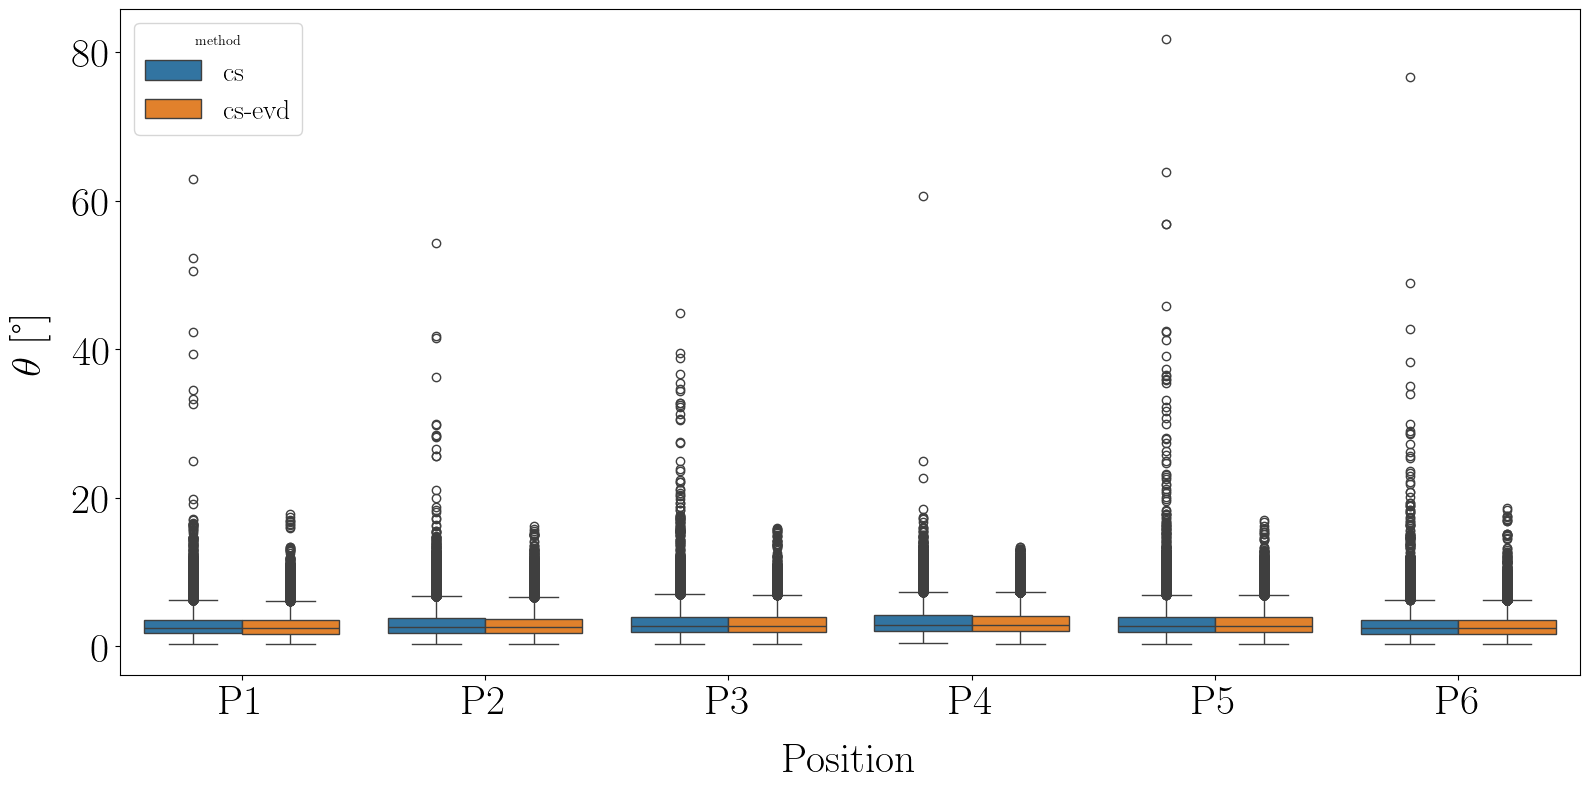

In [10]:
# Boxplot at each position
sns.boxplot(data=df_theta, x="position", y="value", hue="method")
plt.ylabel(r"$\theta$ [°]")
plt.xlabel("Position")

#### Sans les outlayers pour voir les médianes

Text(0.5, 0, 'Position')

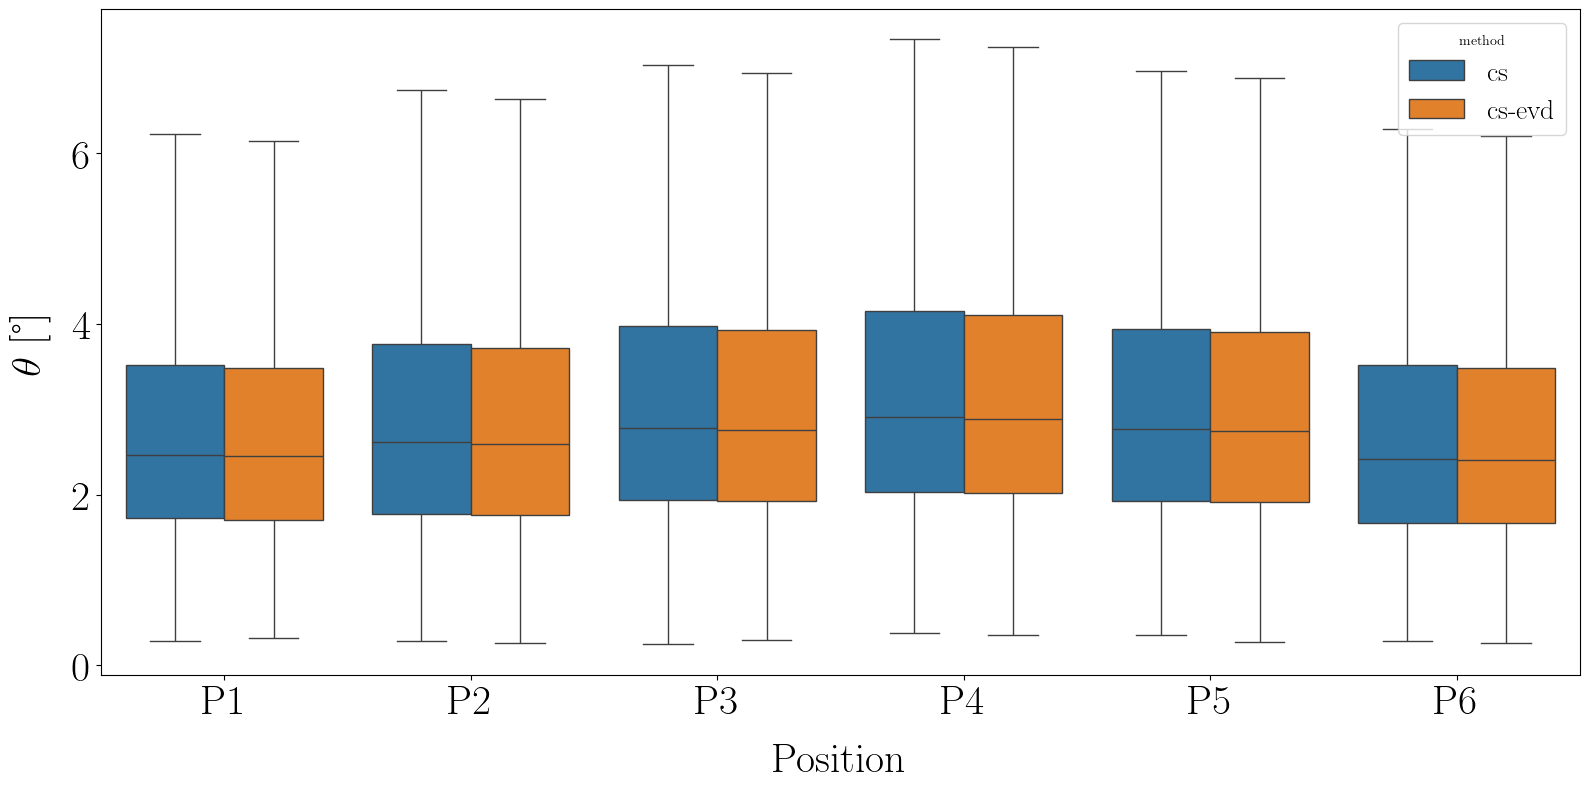

In [11]:
# Violin at each position
sns.boxplot(data=df_theta, x="position", y="value", hue="method", showfliers=False)
plt.ylabel(r"$\theta$ [°]")
plt.xlabel("Position")


#### Violin plot pour voir les densités

Text(0.5, 0, 'Position')

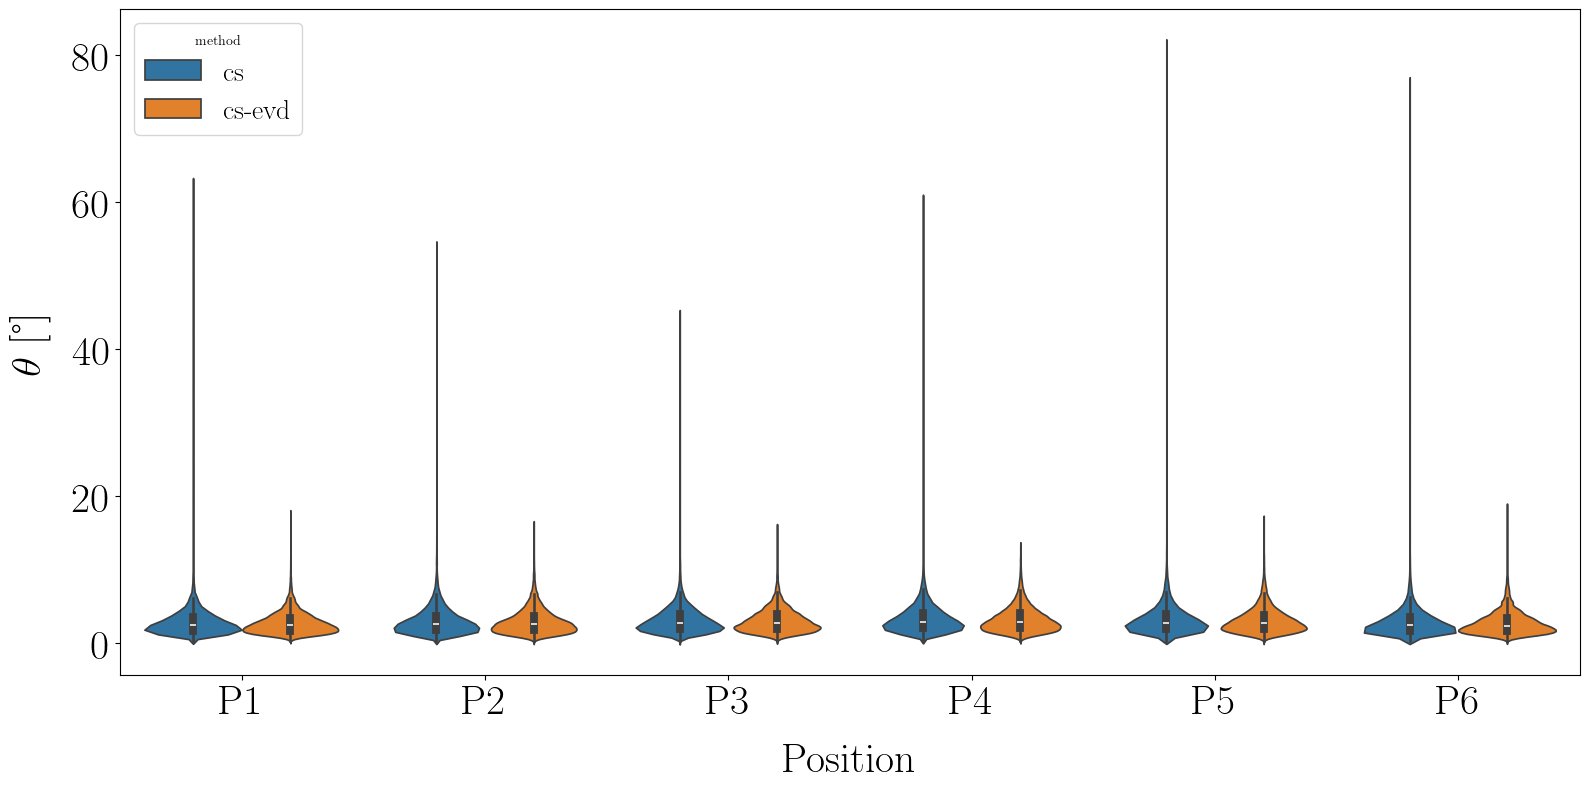

In [12]:
# Violin at each position
sns.violinplot(data=df_theta, x="position", y="value", hue="method")
plt.ylabel(r"$\theta$ [°]")
plt.xlabel("Position")
# plt.ylim()

#### Commentaires

Ces premiers graphiques permettent de mettre en lumière quelques éléments importants : 

* Les distributions ne sont clairement pas gaussienne (quelle que soit la méthode d'estimation des RTFs considérée)
* Conformément à nos attentes et à la littérature, la méthode CS-EVD présente de meilleures performances avec une plus faible dispersion des valeurs et une médiane légèrement inférieure pour l'ensemble des positions

### Distributions pour l'ensemble des combinaisons (position, durée) 

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


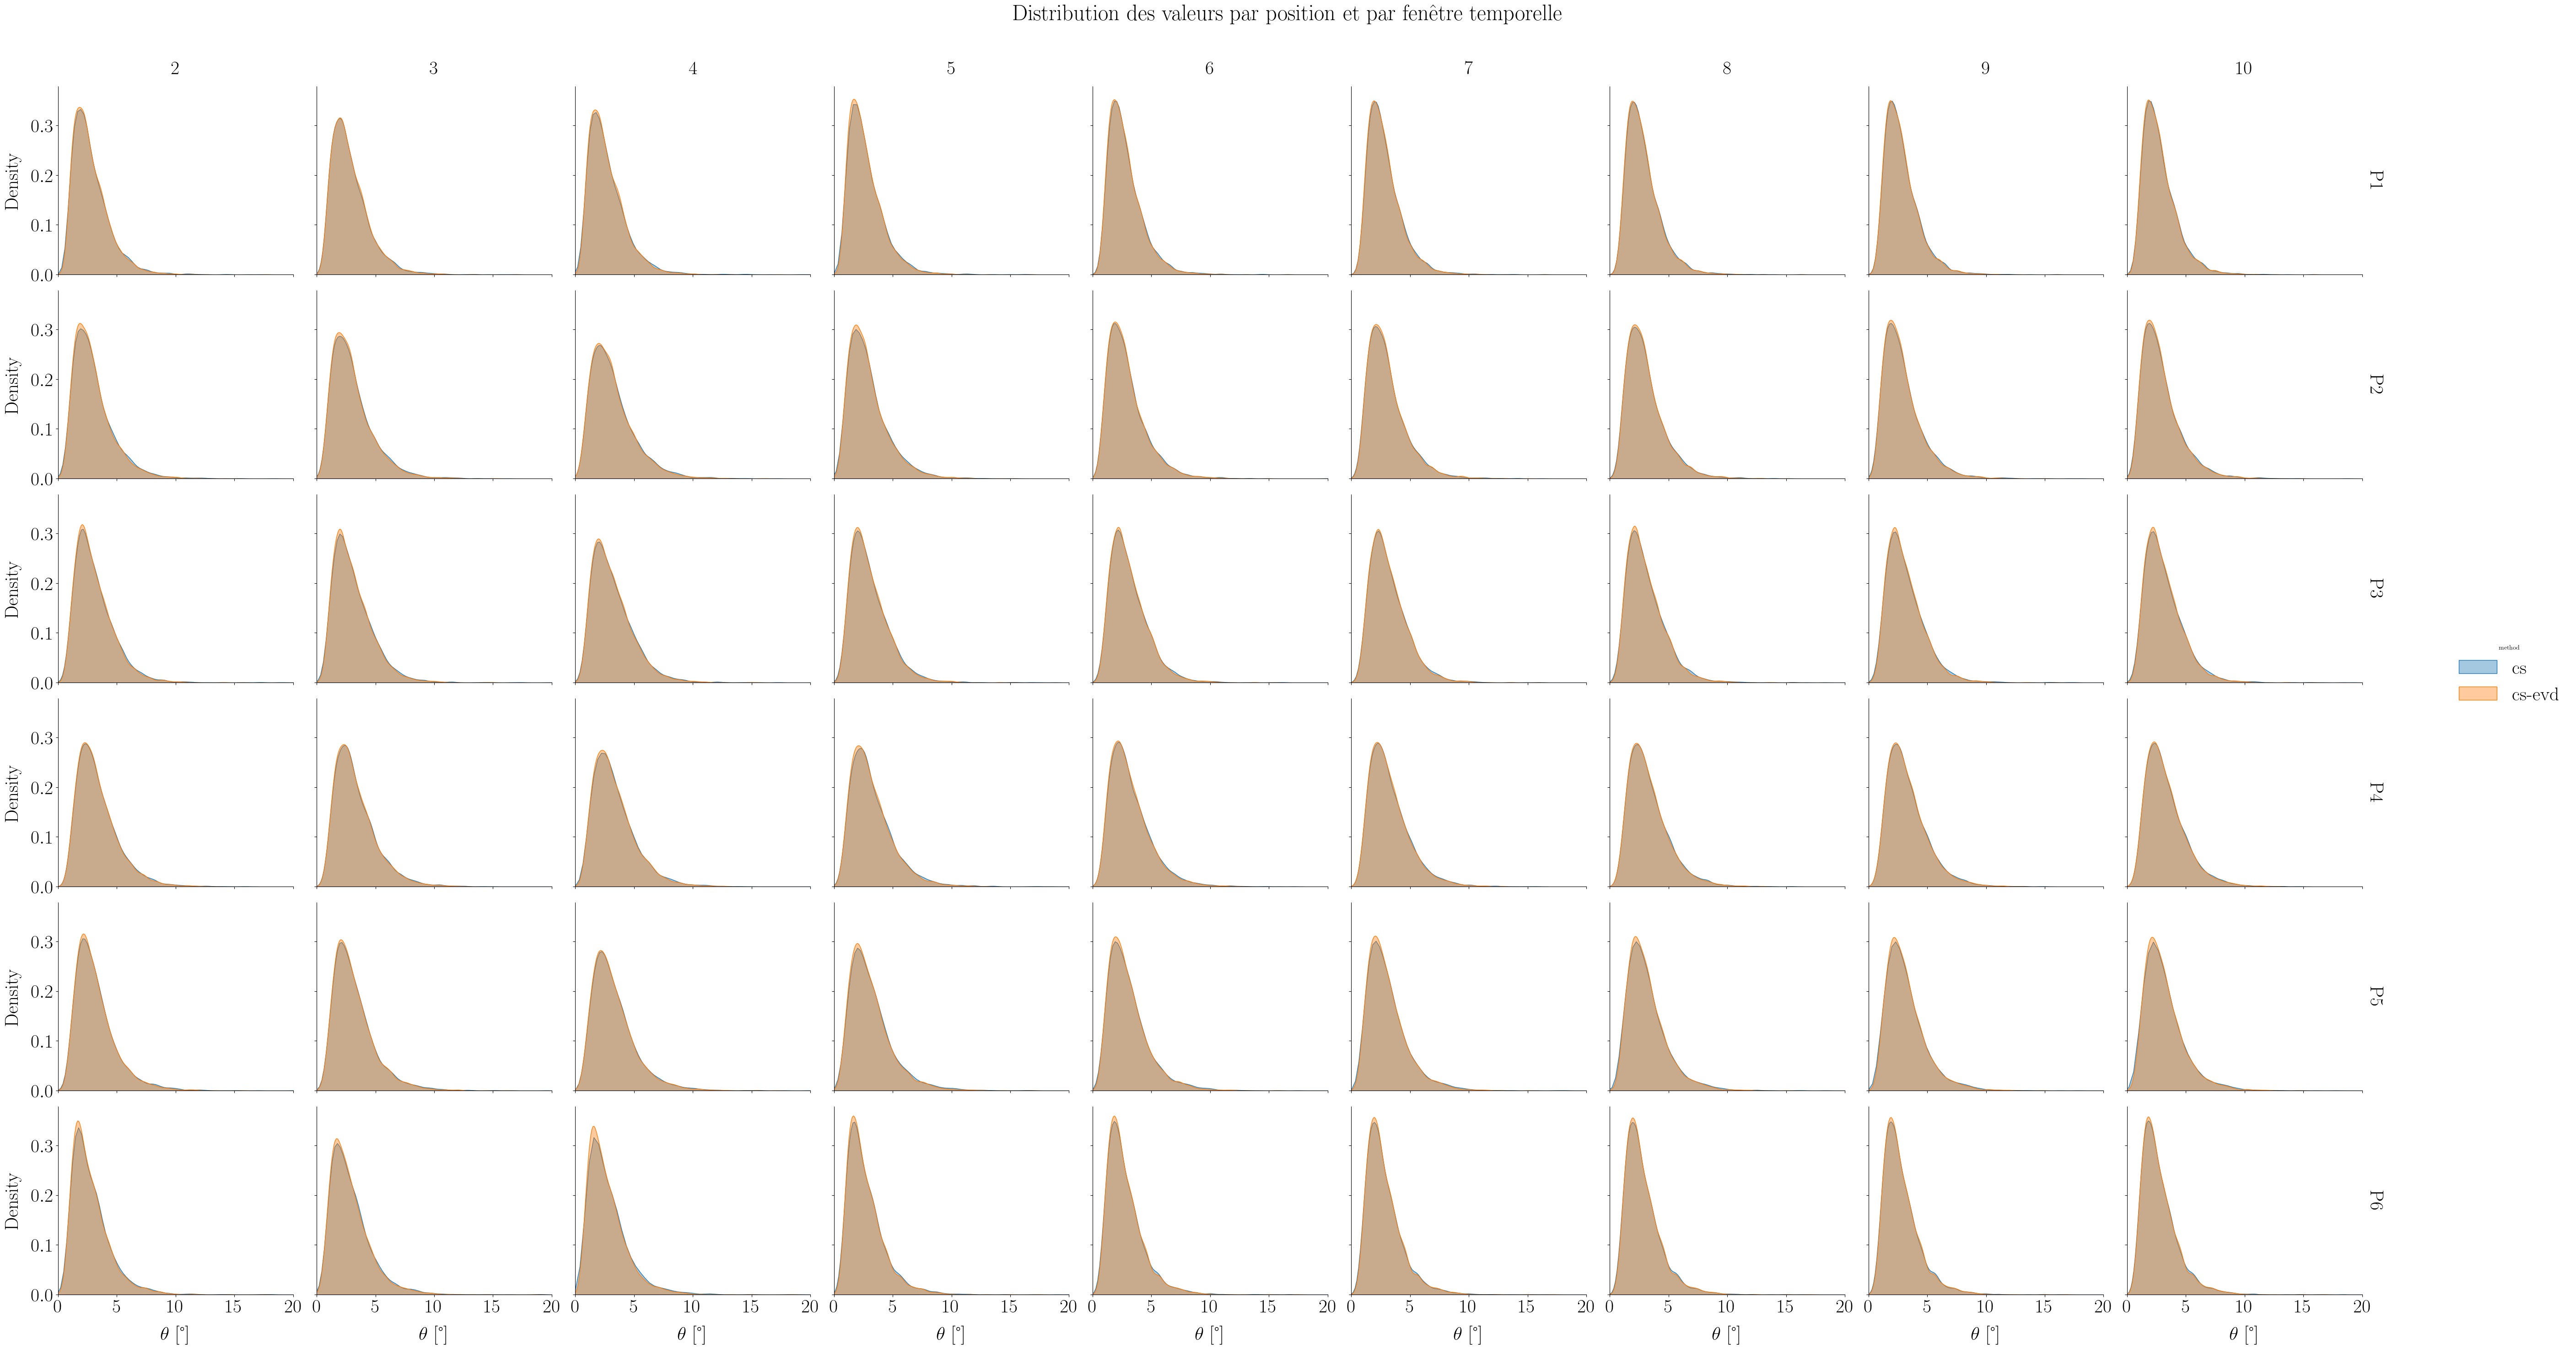

In [13]:
g = plot_all_distribution_panel(df_theta, filter=False)
g.set(xlim=(0, 20))
g.figure.subplots_adjust(top=0.92, wspace=0.1)

Filtered data summary:      method position  window_tf  n_before  n_after  n_removed  pct_removed
0        cs       P1          2      5734     5695         39     0.680153
1        cs       P1          3      5734     5702         32     0.558075
2        cs       P1          4      5734     5698         36     0.627834
3        cs       P1          5      5734     5694         40     0.697593
4        cs       P1          6      5734     5694         40     0.697593
..      ...      ...        ...       ...      ...        ...          ...
103  cs-evd       P6          6      5734     5707         27     0.470875
104  cs-evd       P6          7      5734     5708         26     0.453436
105  cs-evd       P6          8      5734     5707         27     0.470875
106  cs-evd       P6          9      5734     5707         27     0.470875
107  cs-evd       P6         10      5734     5709         25     0.435996

[108 rows x 7 columns]


c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


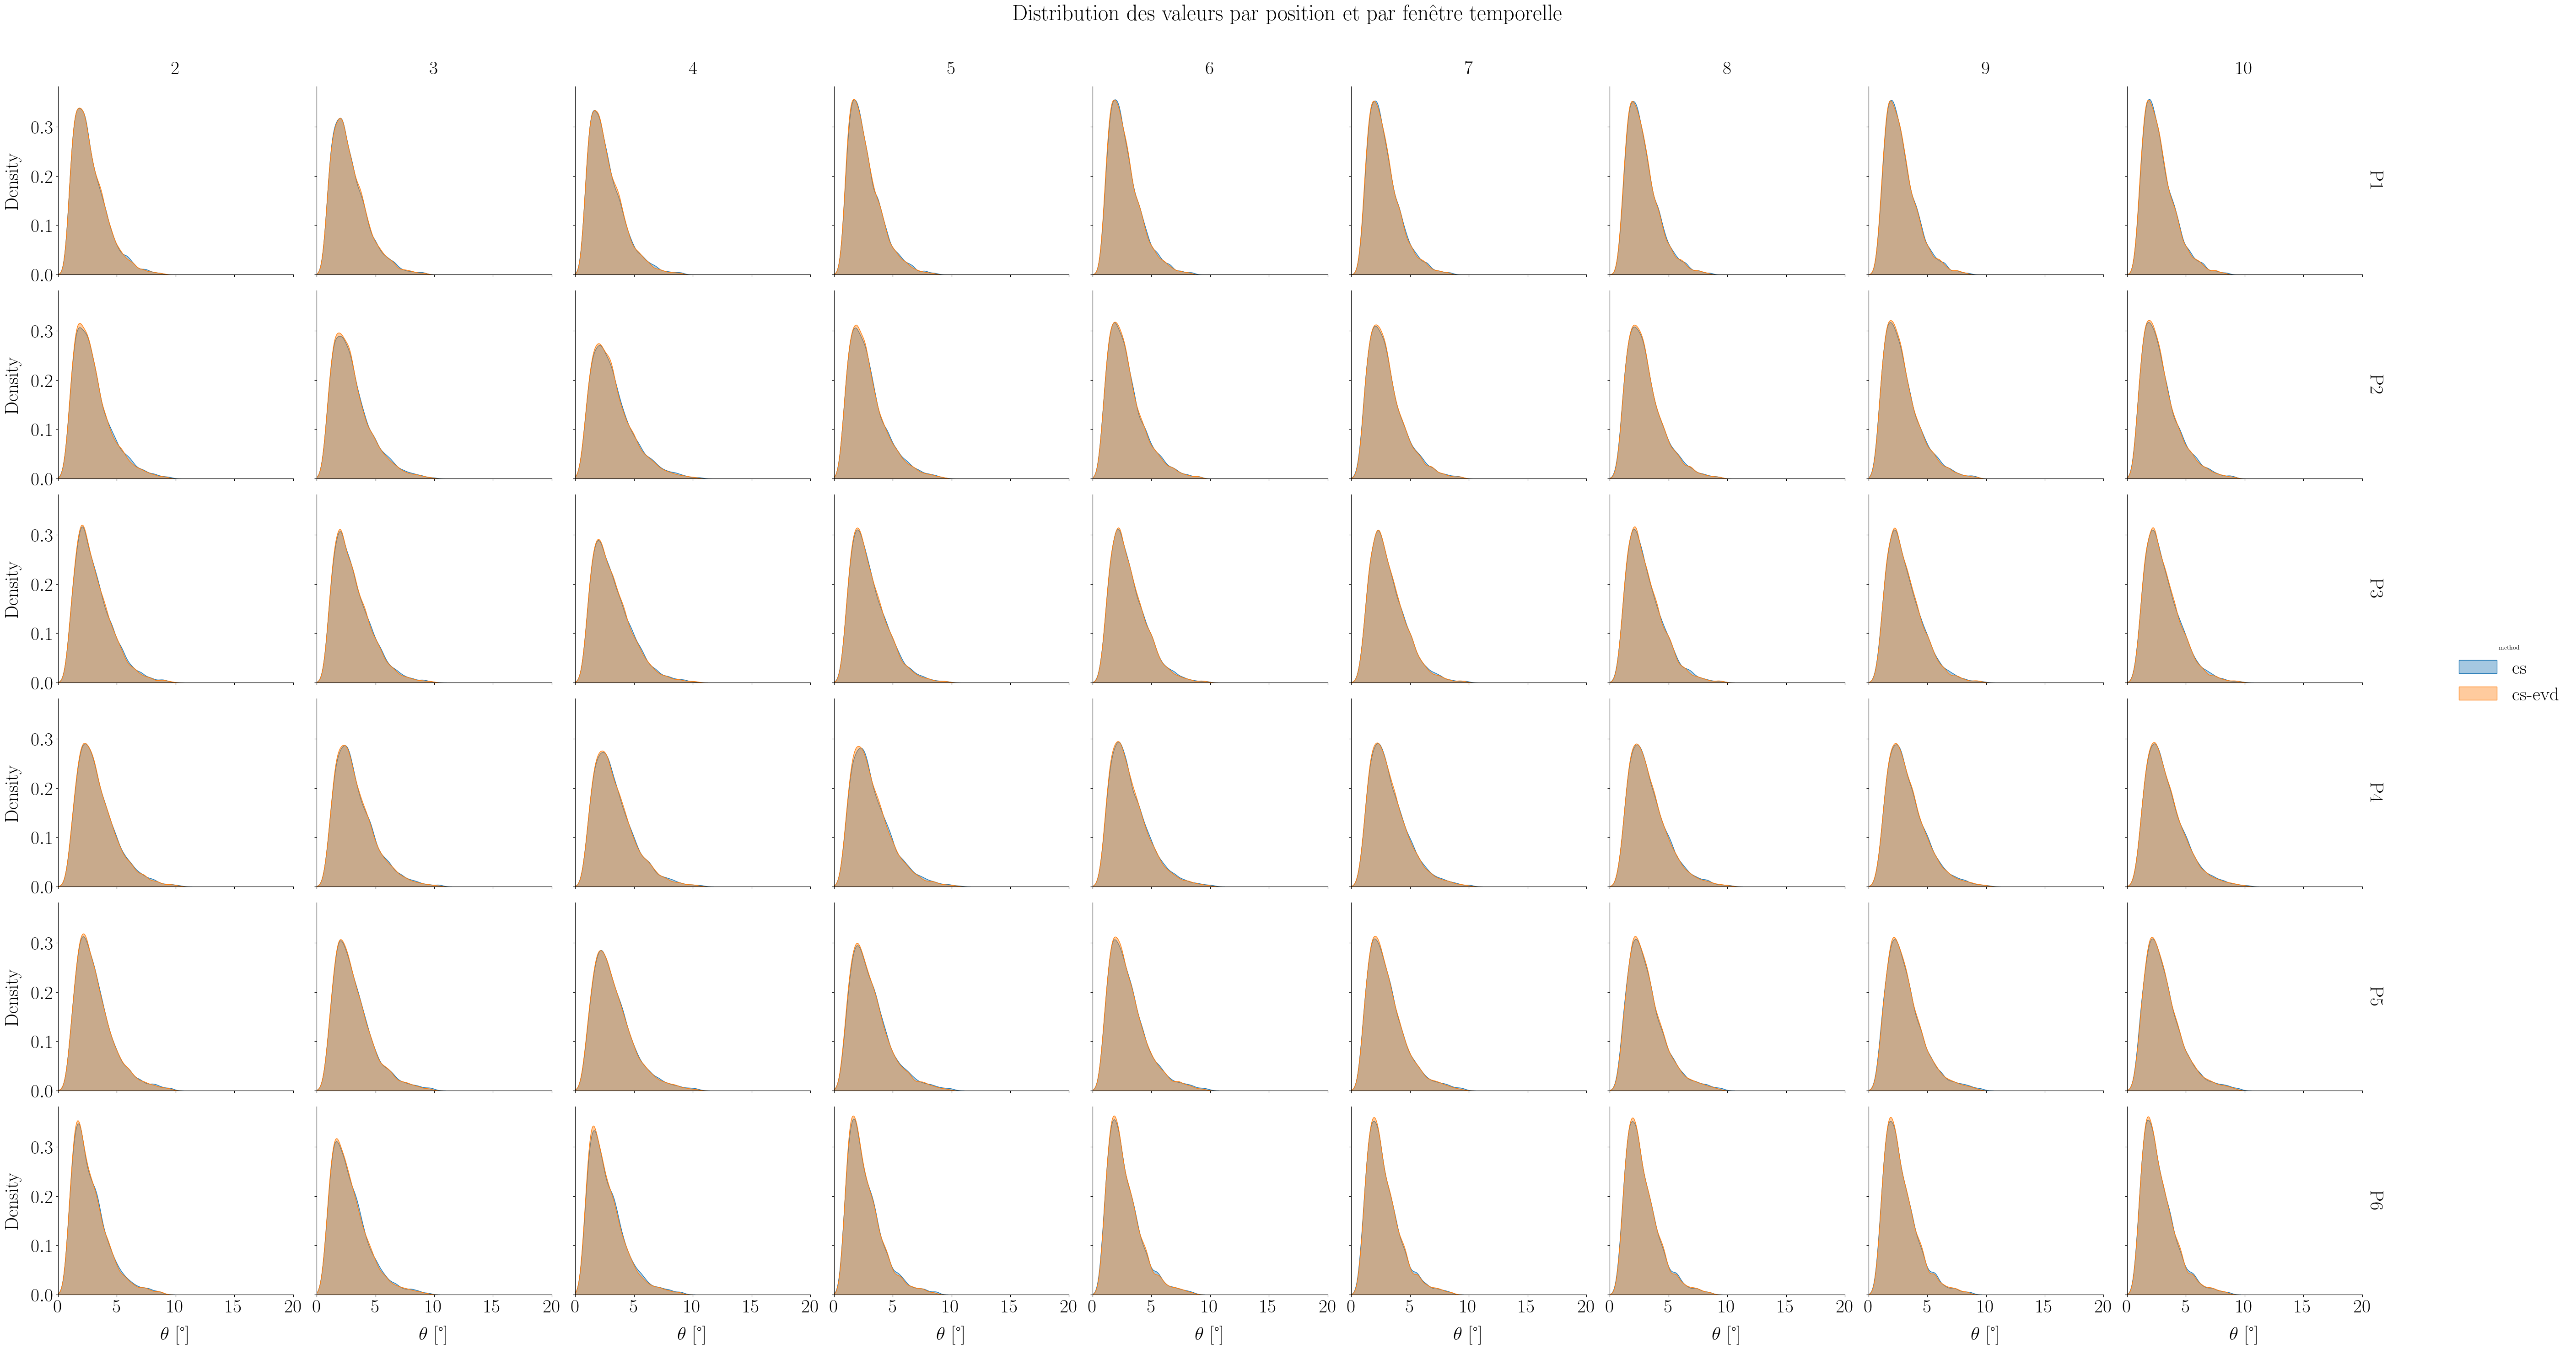

In [14]:
g = plot_all_distribution_panel(df_theta, filter=True)
g.set(xlim=(0, 20))
g.figure.subplots_adjust(top=0.92, wspace=0.1)

#### Commentaires

À première vue les distributions sont similaires pour l'ensemble des couples (position, durée) ce qui est en accord avec l'étude de performance menée dans le notebook "duration_influence". 
Il n'y pas de différence significative entre les deux estimateurs. 

**Filtrage IQR** : les données filtrées avec un filtre IQR (k=3) ont la même distribution, le pourcentage de points aberrants filtrés est très faible (< 1%)

### Comparaison des distributions aux différentes positions 

Filtered data summary:     method position  window_tf  n_before  n_after  n_removed  pct_removed
0       cs       P1         10      5734     5702         32     0.558075
1       cs       P2         10      5734     5696         38     0.662714
2       cs       P3         10      5734     5704         30     0.523195
3       cs       P4         10      5734     5713         21     0.366236
4       cs       P5         10      5734     5702         32     0.558075
5       cs       P6         10      5734     5702         32     0.558075
6   cs-evd       P1         10      5734     5710         24     0.418556
7   cs-evd       P2         10      5734     5705         29     0.505755
8   cs-evd       P3         10      5734     5720         14     0.244158
9   cs-evd       P4         10      5734     5716         18     0.313917
10  cs-evd       P5         10      5734     5706         28     0.488315
11  cs-evd       P6         10      5734     5709         25     0.435996


c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


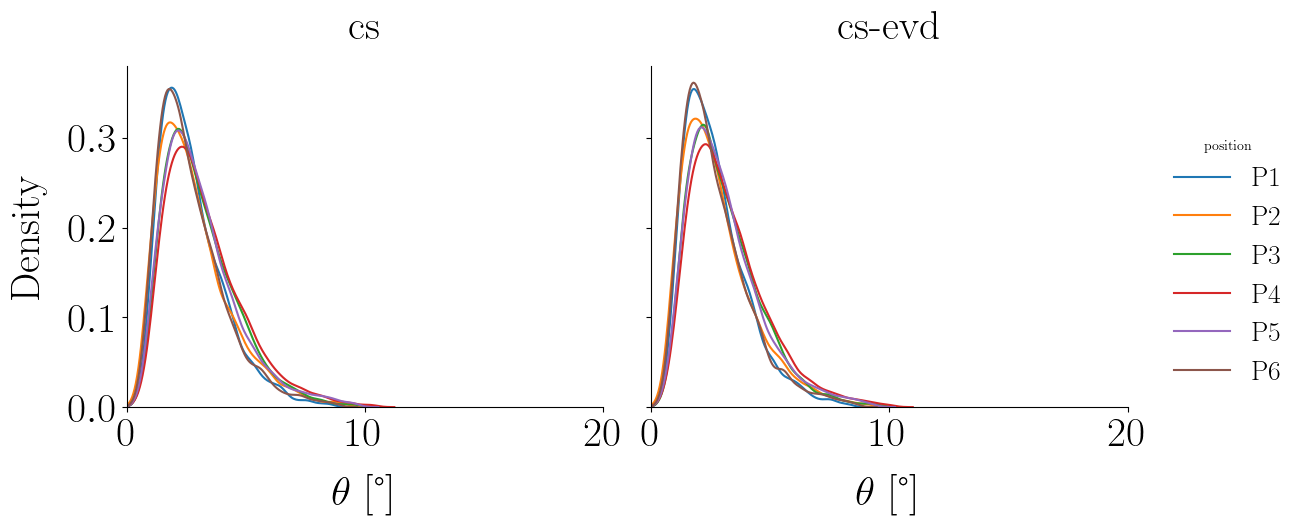

In [15]:
df_group = df_theta[(df_theta["window_tf"] == 10)]
g = plot_distribution_panel_single_window(df_group, filter=True)
g.set(xlim=(0, 20))
g.figure.subplots_adjust(top=0.92, wspace=0.1)

In [16]:
src_label_sorted

['P1', 'P6', 'P2', 'P5', 'P3', 'P4']

#### Commentaires 
On analyse les distributions pour une durée de signal T = 10 s. 

Légères variations de la distribution en fonctions de la position considérée. 

On peut observer une légère tendance avec la distance de la source : plus la source est loin plus la distribution est décalée vers la droite. Cette tendance est très faible et ne s'observe pas sur toutes les positions, la variation observée est probablement liée à la variations du SNR en fonction de la position. En effet, plus la source est loin plus le niveau du signal reçu est faible or les performances des estimateurs sont fortement liée aux SNR. 

### Comparaison des distributions pour les différentes tailles de fenêtres 

Filtered data summary:     method position  window_tf  n_before  n_after  n_removed  pct_removed
0       cs       P6          2      5734     5694         40     0.697593
1       cs       P6          3      5734     5701         33     0.575514
2       cs       P6          4      5734     5684         50     0.871992
3       cs       P6          5      5734     5695         39     0.680153
4       cs       P6          6      5734     5694         40     0.697593
5       cs       P6          7      5734     5693         41     0.715033
6       cs       P6          8      5734     5695         39     0.680153
7       cs       P6          9      5734     5702         32     0.558075
8       cs       P6         10      5734     5702         32     0.558075
9   cs-evd       P6          2      5734     5713         21     0.366236
10  cs-evd       P6          3      5734     5711         23     0.401116
11  cs-evd       P6          4      5734     5712         22     0.383676
12  cs-evd     

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


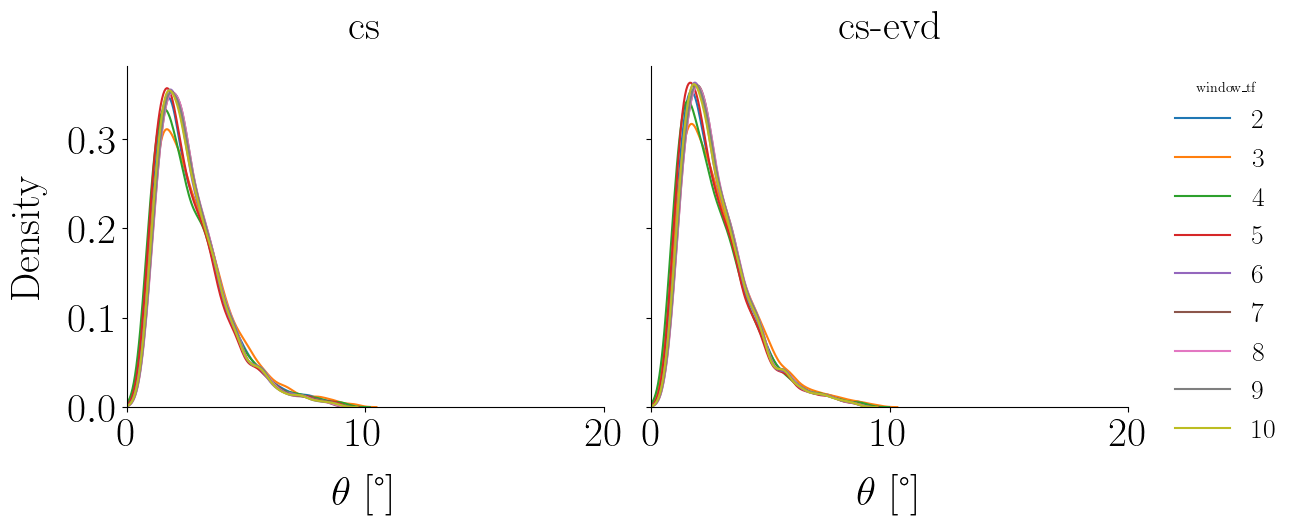

In [17]:
df_group = df_theta[(df_theta["position"] == "P6")]

g = plot_distribution_panel_single_position(df_group, filter=True)
g.set(xlim=(0, 20))
g.figure.subplots_adjust(top=0.92, wspace=0.1)

#### Commentaires 


Pas de tendance remarquable quelle que soit la position étudiée. 


### Distributions de Rayleigh ? 

L'allure de la distribution s'apparente à une distribution de Rayleigh pour laquelle la densité de probabilité $f$ est définie par : 

$$X \sim \mathcal{R}(\sigma^2), \quad f(x) = \frac{x}{\sigma^2} \exp{\left ( \frac{-x^2}{2\sigma^2} \right )} $$

**Remarque** : la librairie scipy.stats utilise une définition standardisée de la forme  : 

$$X \sim \mathcal{R}, \quad f(x) = x \exp{\left ( \frac{-x^2}{2} \right )} $$

La distribution n'est donc pas paramétrique. En revanche, pour l'ensemble des distribution de scipy.stats la méthode .fit retourne, en plus des paramètres naturellement associés à la distribution, les paramètres $loc = \mu$ et $scale = \sigma$. Ces paramètres donne une distribution de la forme plus générale : 

$$X \sim \mathcal{R}, \quad f(x, loc, scale) = f(x, \mu, \sigma) = \frac{f(y)}{\sigma}$$

avec, 

$$ y = \frac{x - \mu}{\sigma} $$

Ainsi,

$$ f(x, \mu, \sigma) = \frac{x-\mu}{\sigma^2} \exp{\left ( \frac{-(x-\mu)^2}{2\sigma^2} \right )} $$ 


#### Q-Q plot 

Une première façon de visualiser l'ajustement des données avec une loi de Rayleigh est le Q-Q plot.

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


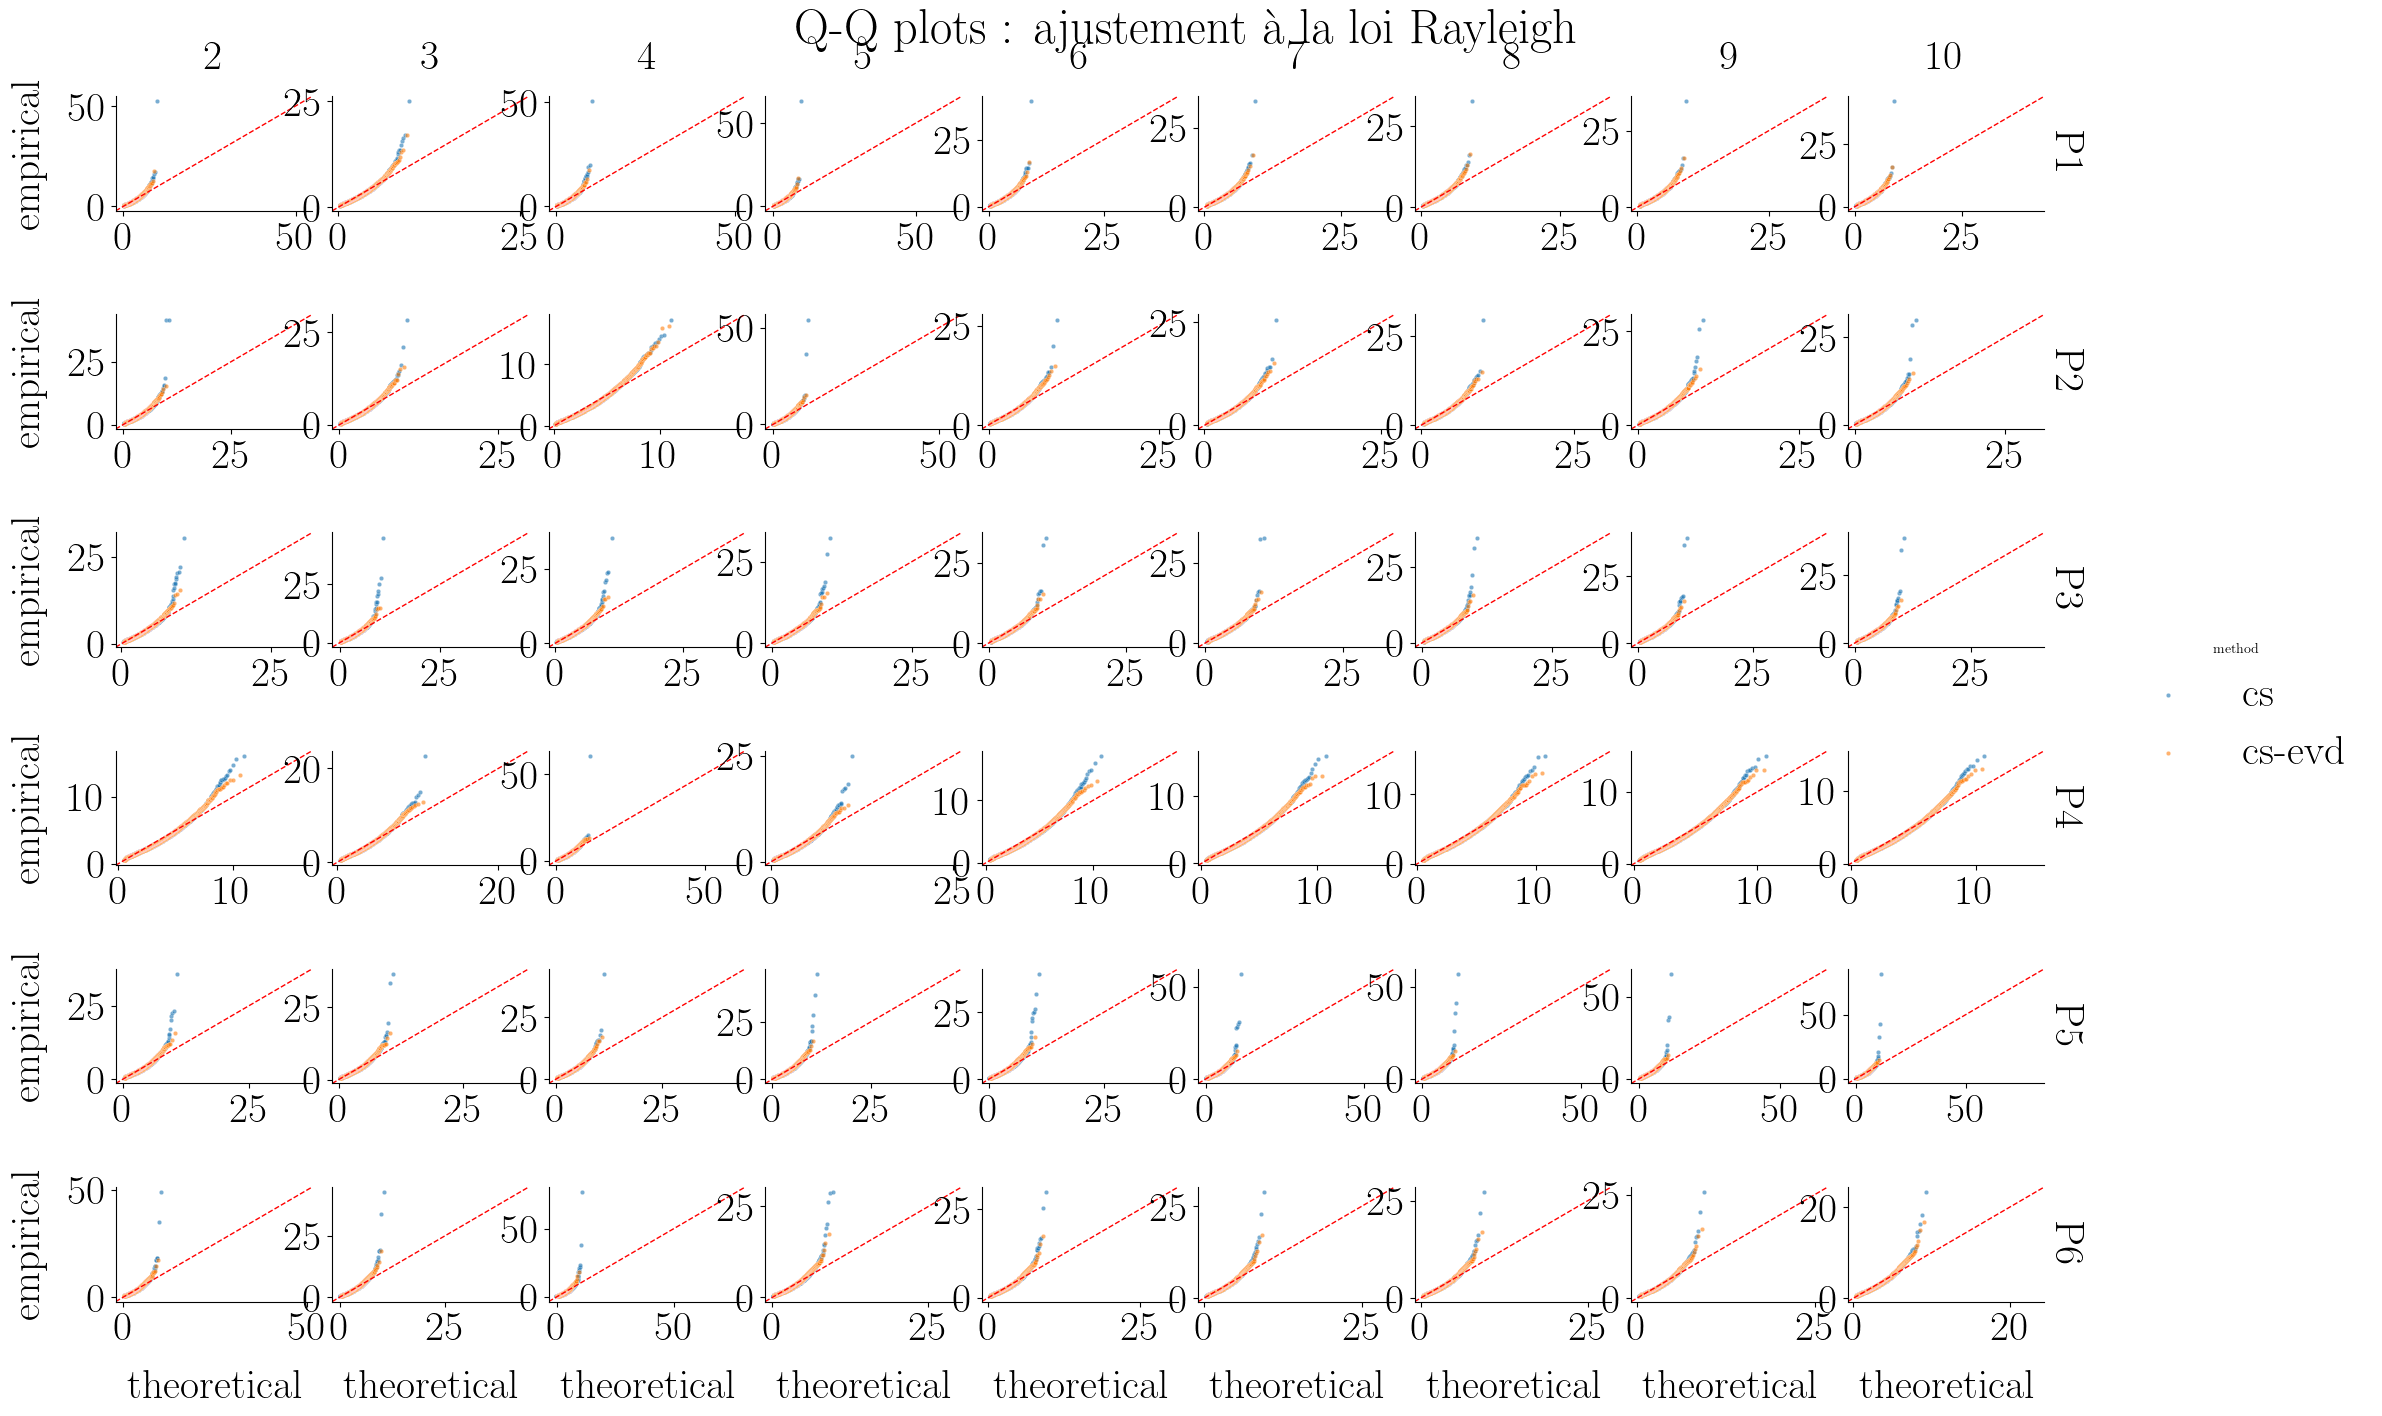

In [18]:
g = qq_plot(df_theta, law="rayleigh", filter=False)


c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


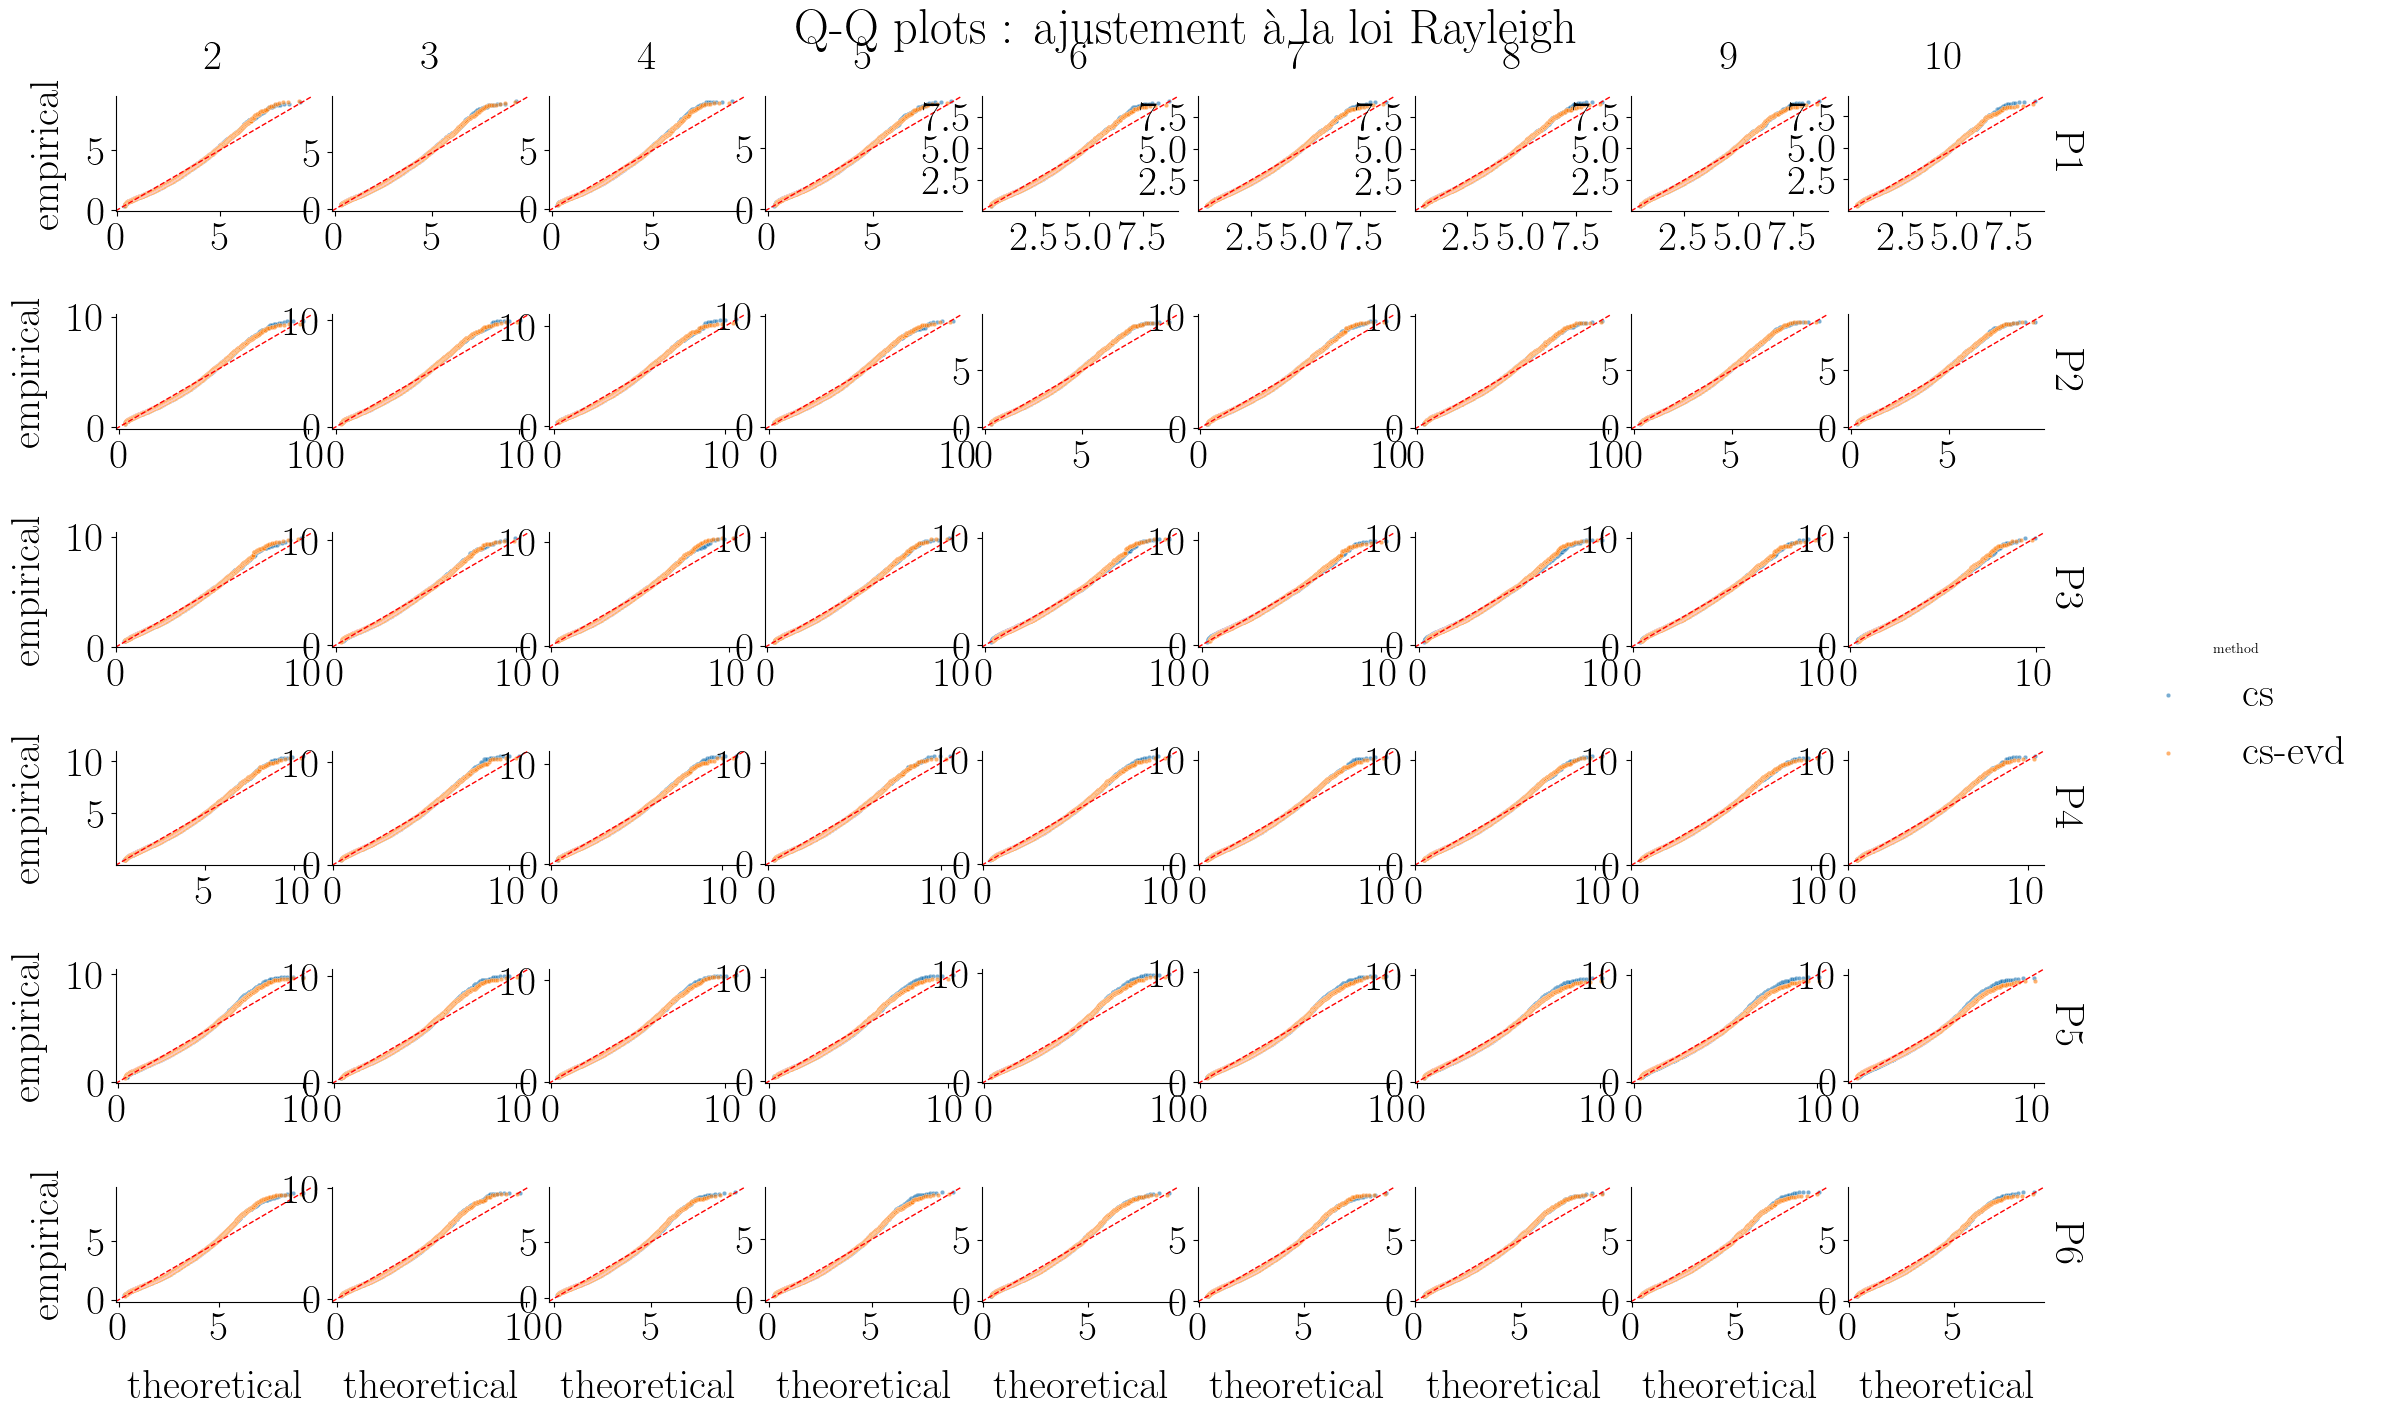

In [19]:
qq_plot(df_theta, law="rayleigh", filter=True)

##### Commentaires 

**Sans filtrage des données** : 
Faible ajustement avec la loi de Rayleigh quelle que soit la position ou la durée du signal, divergence pour les quantiles élevés. 

**Après filtrage IQR**: Mauvais ajustement, les Q-Q plots exhibent clairement une forme en S caractéristique d'un écart au niveau de la queue de la distribution. 
 


#### Test de Kolmogorov-Smirnov (KS)

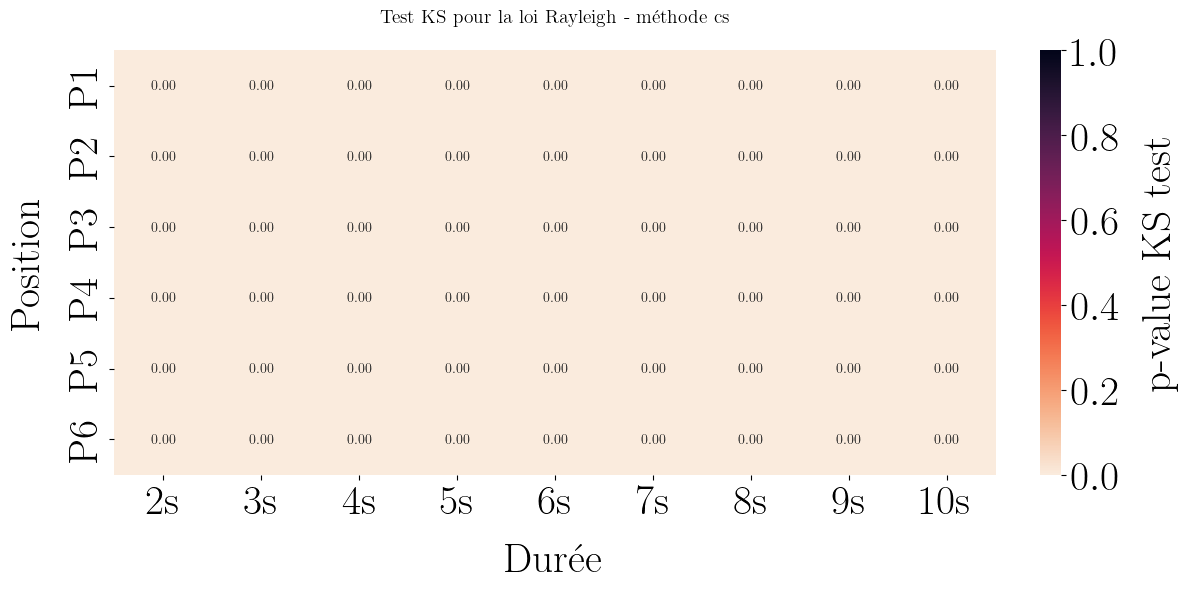

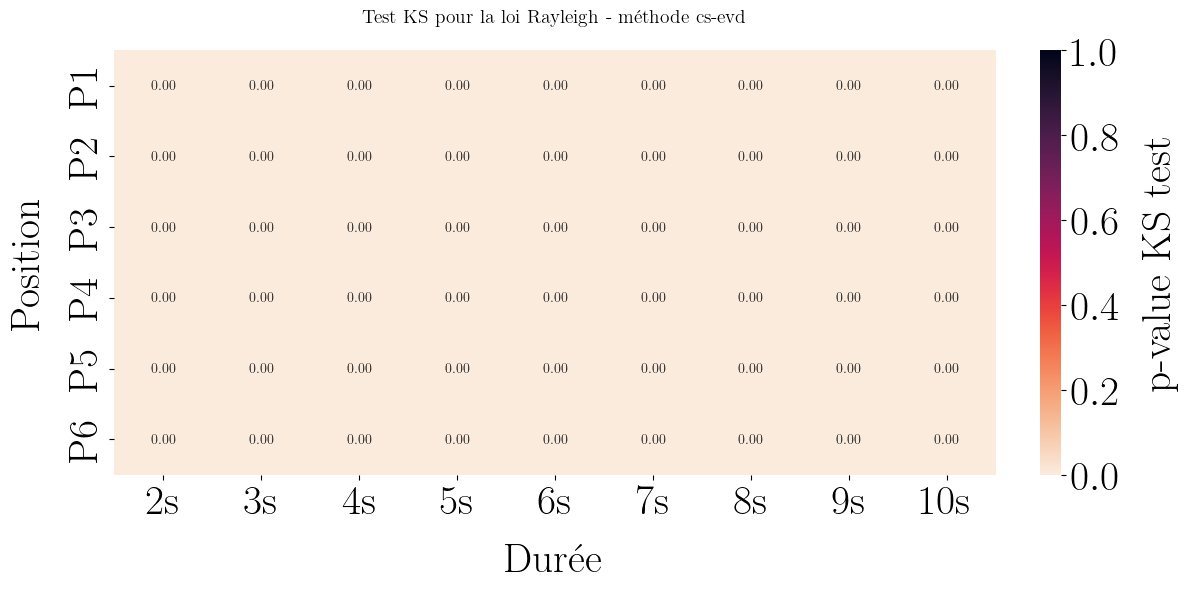

In [20]:
ks_test_heatmap(df_theta, law="rayleigh", filter=False)

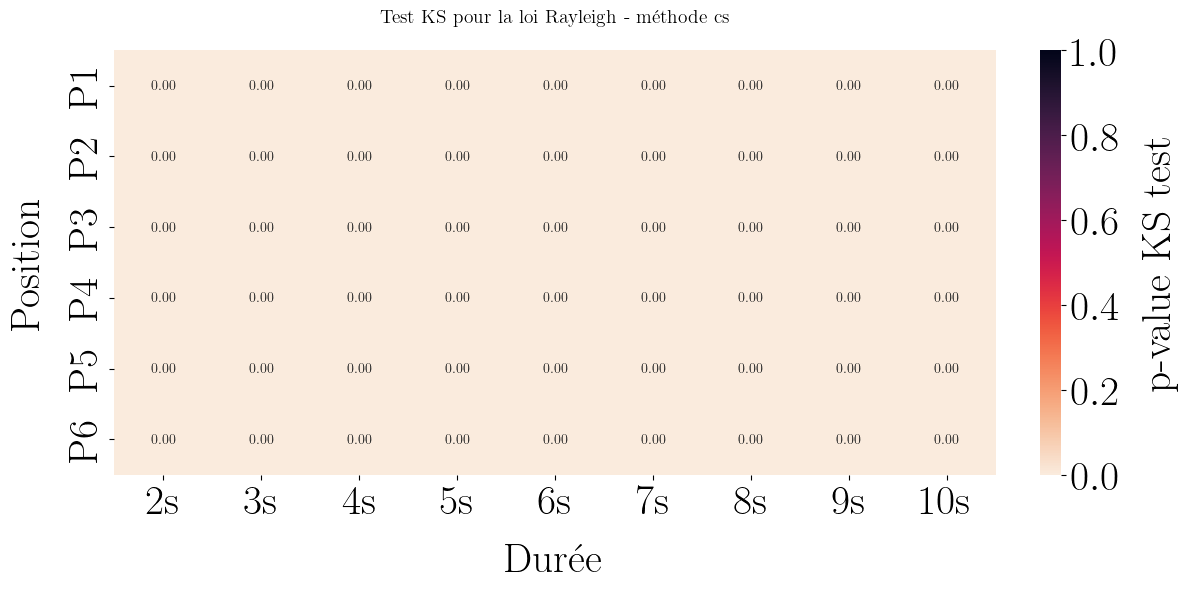

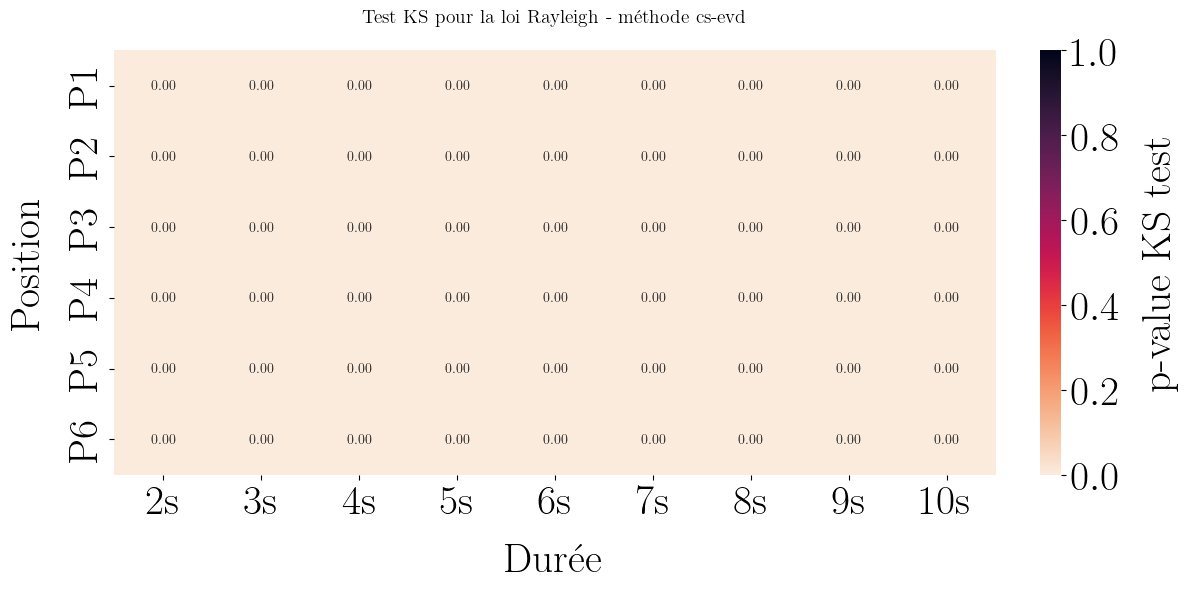

In [21]:
ks_test_heatmap(df_theta, law="rayleigh", filter=True)

##### Commentaires 

Le test KS confirme le mauvais ajustement avec une loi de Rayleigh. 

#### Comparaison d'une distribution Rayleigh ajustée 

Afin de confirmer le diagnostic posé à partir des Q-Q plots on peut comparer les distributions à une distribution de Rayleigh ajustée aux données 

Filtered data summary:    method position  window_tf  n_before  n_after  n_removed  pct_removed
0  cs-evd       P1         10      5734     5710         24     0.418556
1  cs-evd       P2         10      5734     5705         29     0.505755
2  cs-evd       P3         10      5734     5720         14     0.244158
3  cs-evd       P4         10      5734     5716         18     0.313917
4  cs-evd       P5         10      5734     5706         28     0.488315
5  cs-evd       P6         10      5734     5709         25     0.435996


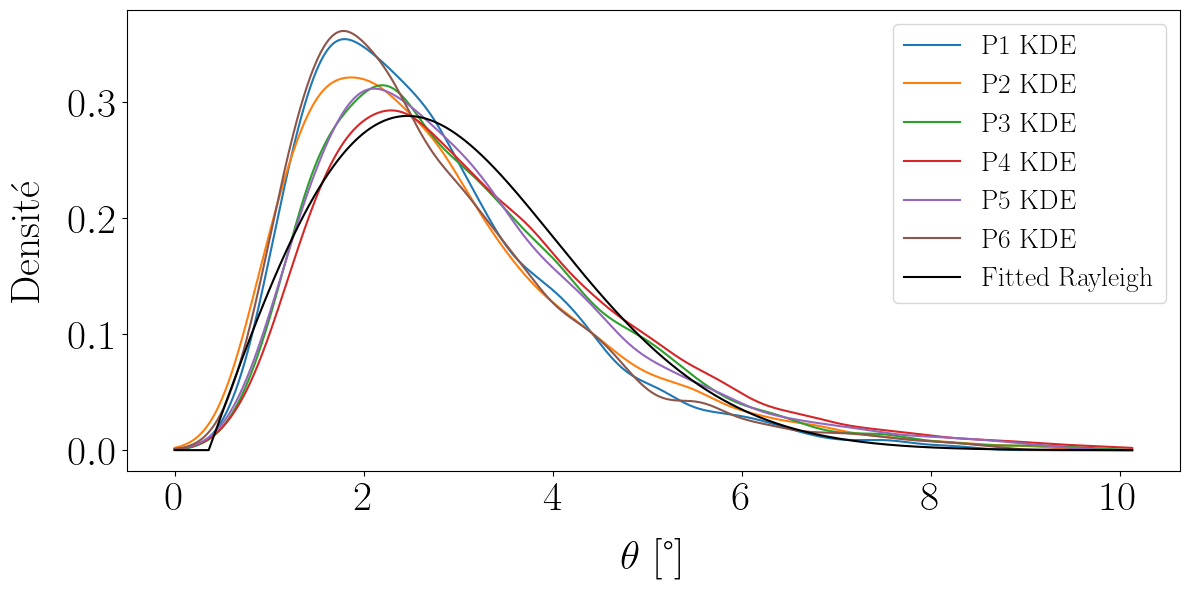

In [22]:
plot_fitted_vs_observed(df_theta, law="rayleigh", filter=True, win=10, method="cs-evd", params_stat="mean")

Filtered data summary:    method position  window_tf  n_before  n_after  n_removed  pct_removed
0  cs-evd       P2         10      5734     5705         29     0.505755


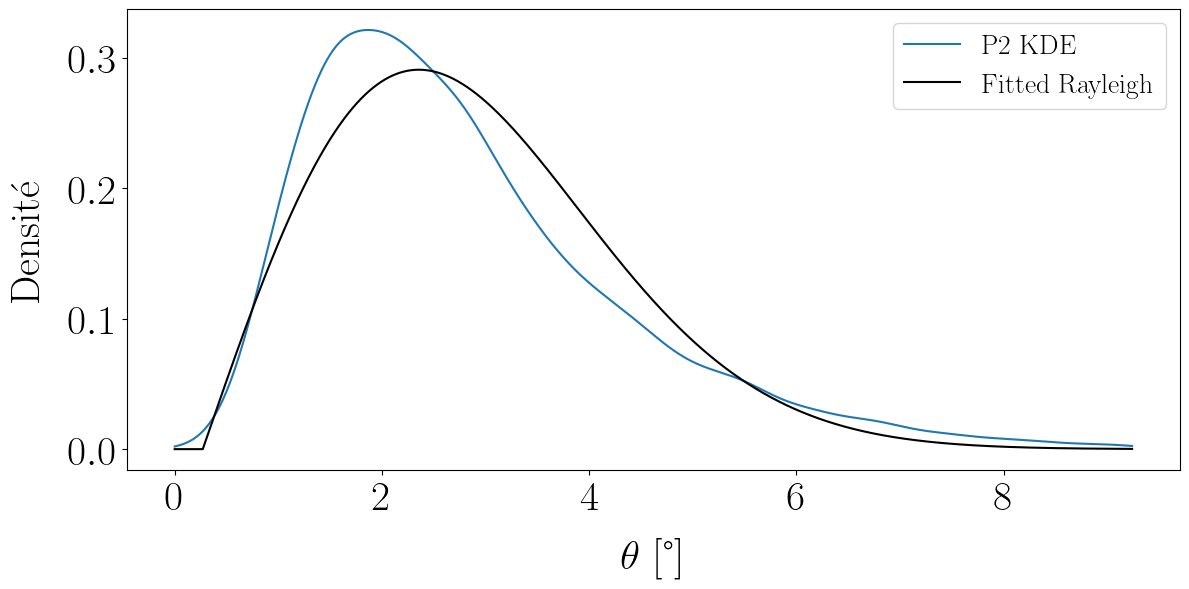

In [23]:
plot_fitted_vs_observed(
    df_theta, law="rayleigh", filter=True, win=10, method="cs-evd", pos="P2", params_stat="first"
)

##### Commentaires 

L'ajustement n'est clairement pas parfait mais est tout de même représentatif. 

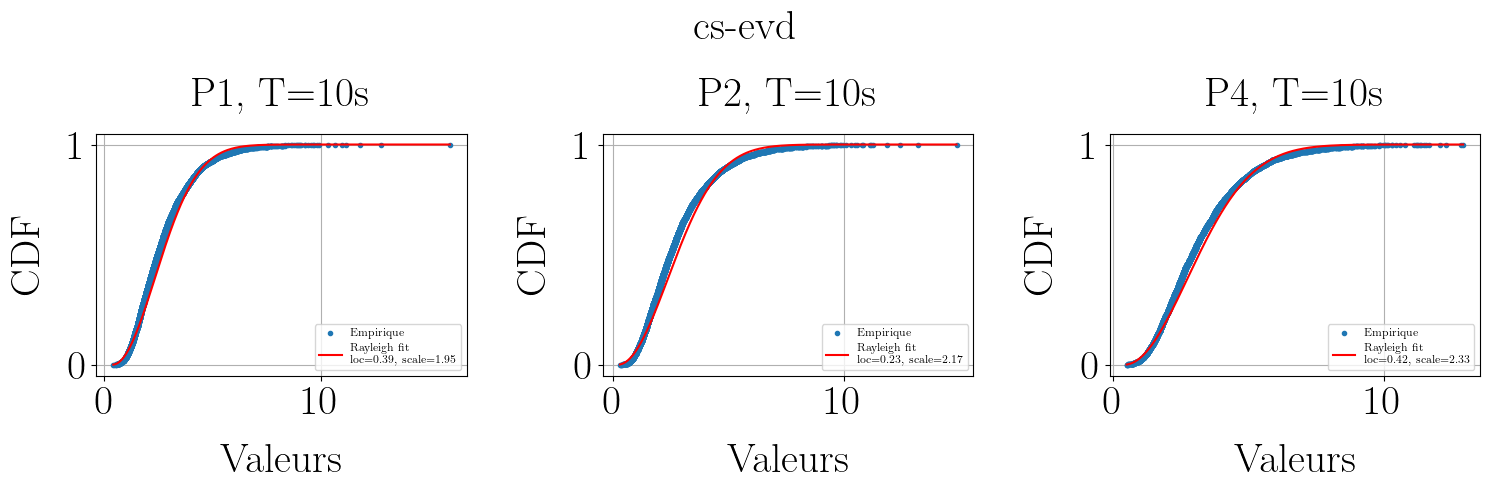

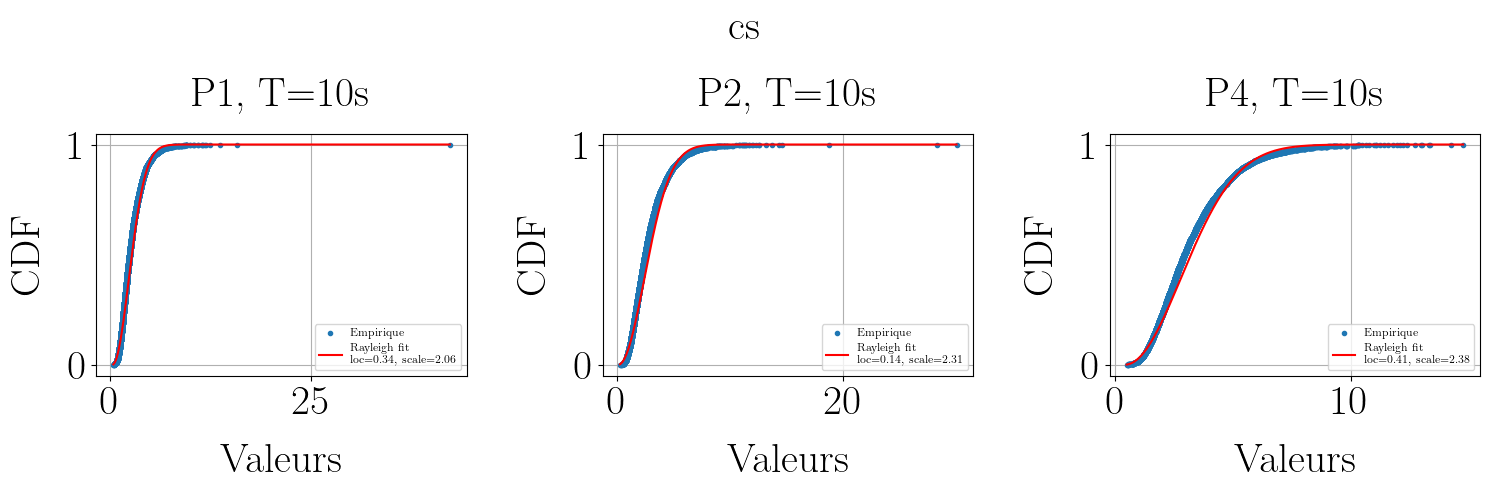

In [24]:
# positions = ["P1", "P2", "P3", "P4", "P5", "P6"]
positions = ["P1", "P2", "P4"]

window_tfs = [10]  # ou plusieurs durées

plot_empirical_vs_rayleigh(
    df_theta, method="cs-evd", positions=positions, window_tfs=window_tfs, figsize=(15, 5)
)
plot_empirical_vs_rayleigh(
    df_theta, method="cs", positions=positions, window_tfs=window_tfs, figsize=(15, 5)
)

### Distribution Gamma ? 

La densité de probabilité $f$ de la distribution gamma est généralement définie par : 

$$X \sim \Gamma(\alpha, \beta), \quad f(x, \alpha, \beta) = \frac{\beta^{\alpha} x^{\alpha-1} e^{-\beta x}}{\Gamma(\alpha)}  $$

**Remarque** : la librairie scipy.stats utilise une définition standardisée de la forme  : 

$$X \sim \Gamma(a), \quad f(x, a) = \frac{x^{a-1} e^{-x}}{\Gamma(a)}  $$

La définition classique s'obtient avec les paramètres $loc = \mu = 0$ et $scale = \frac{1}{\beta}$ (méthode scipy.stats.gamma.fit) 

$$X \sim \Gamma(a), \quad f(x, a, loc, scale) = \frac{f(y, a)}{scale}$$

avec, 

$$ y = \frac{x - loc}{scale} $$




#### Q-Q plot

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


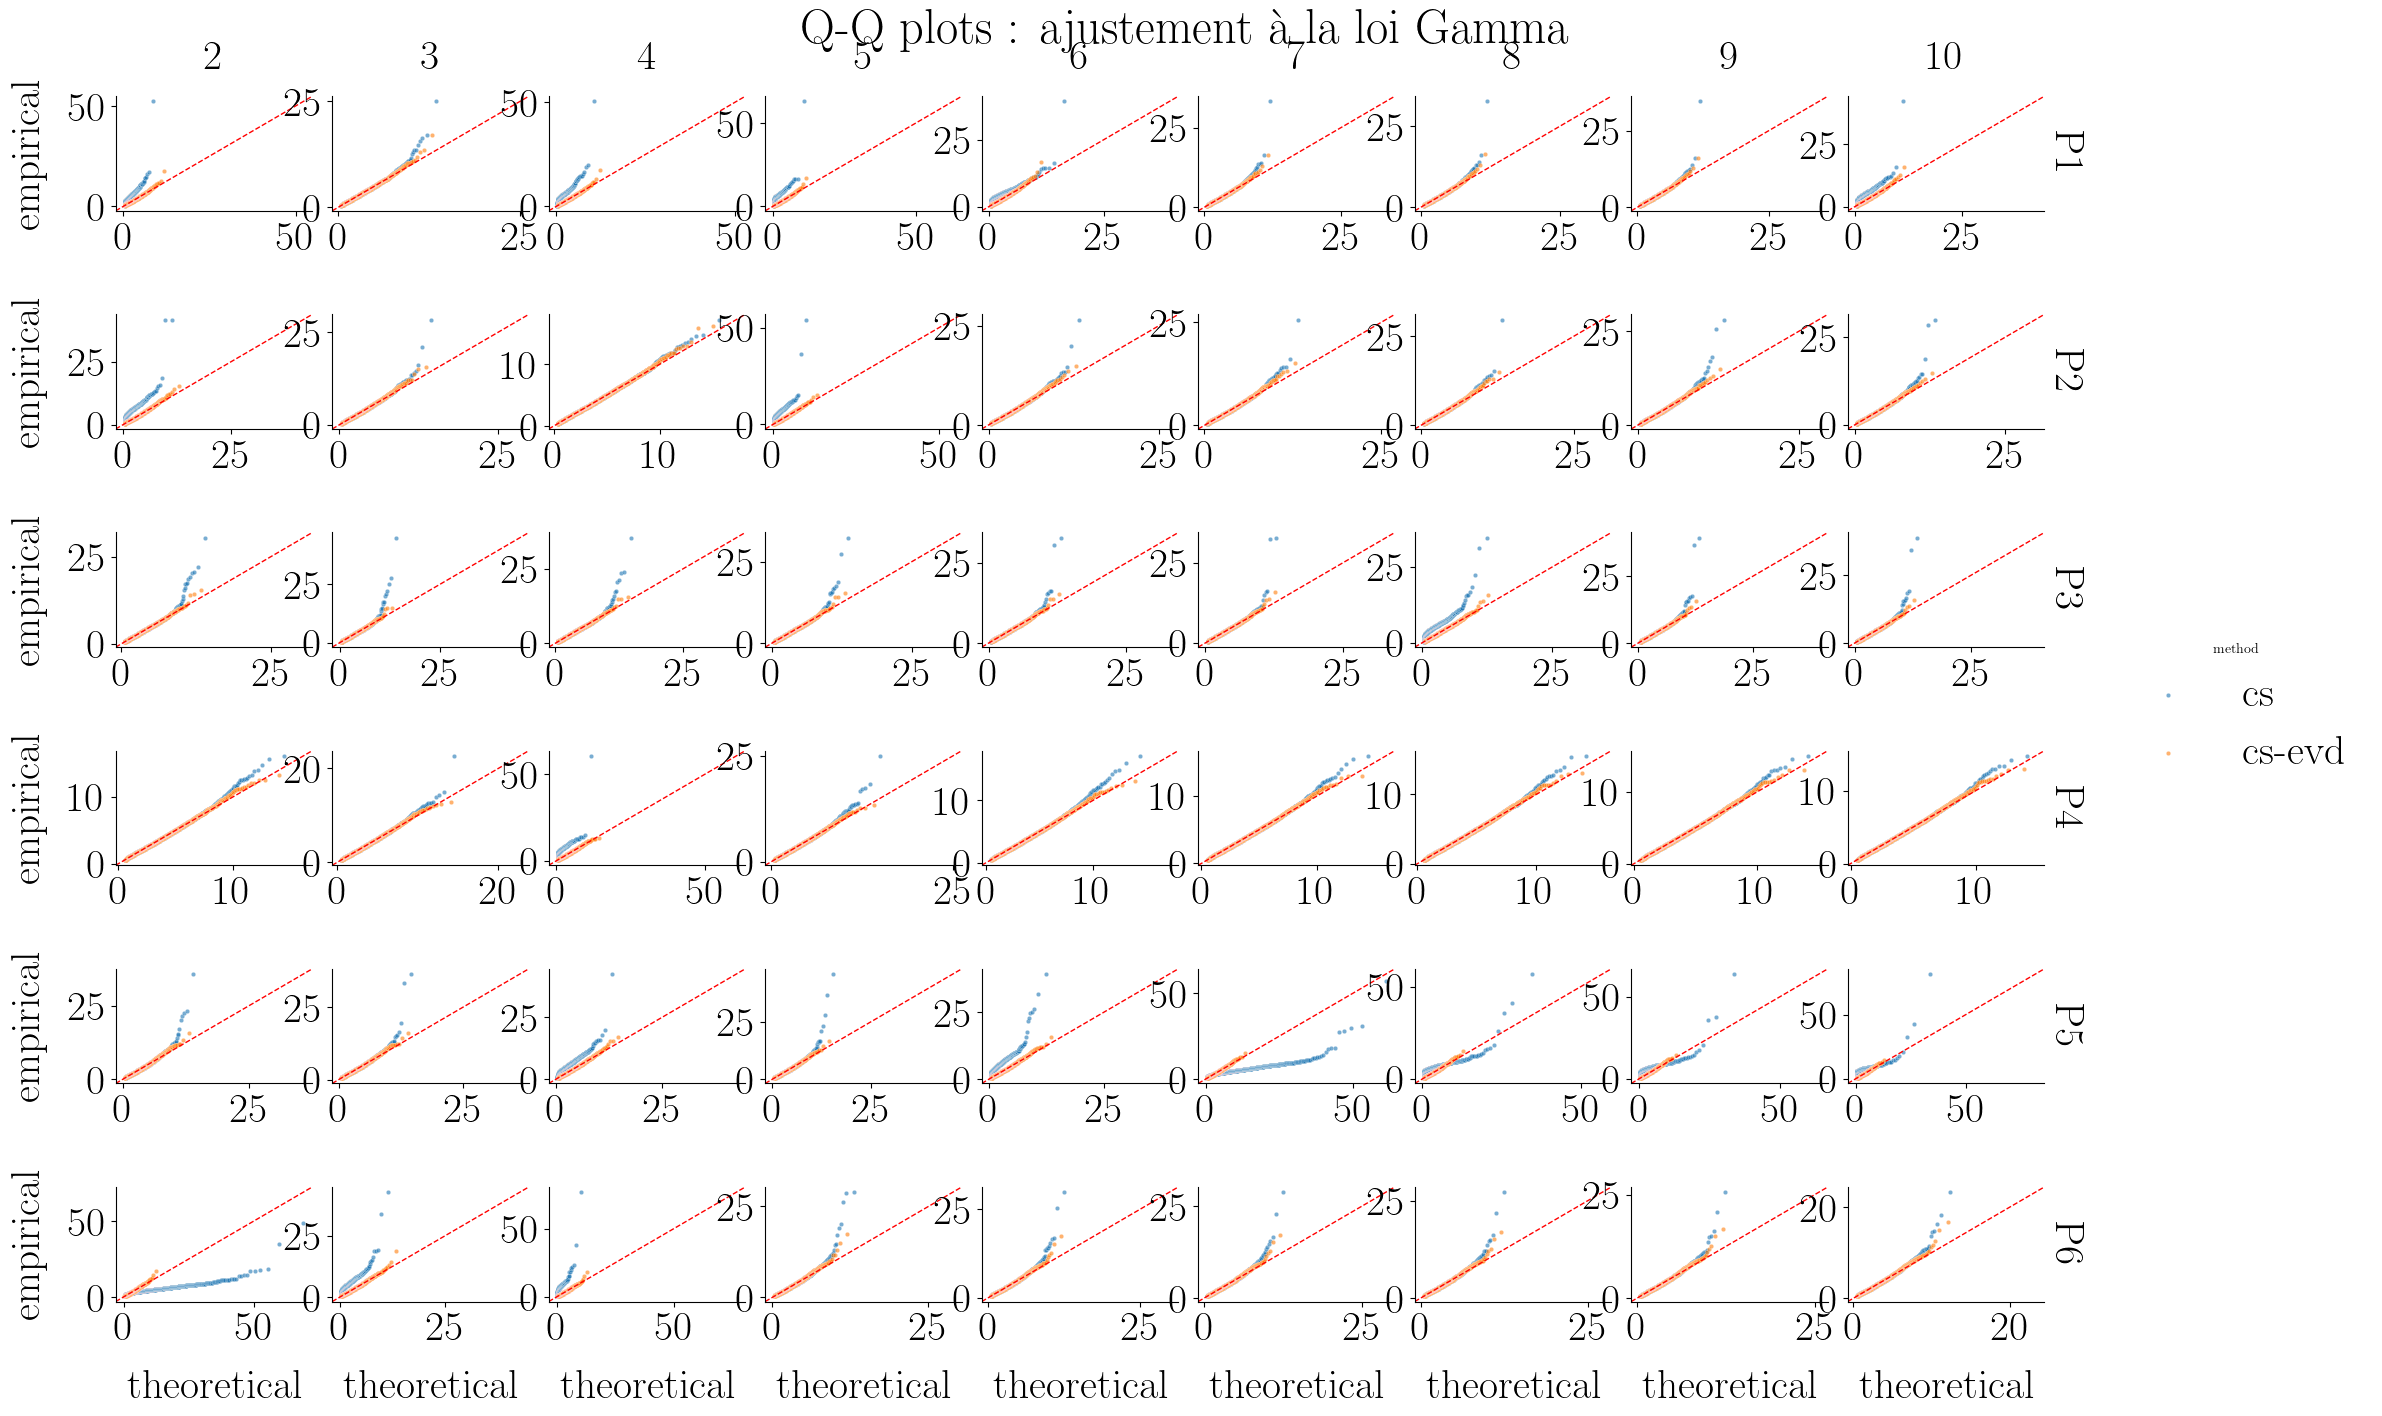

In [25]:
qq_plot(df_theta, law="gamma", filter=False)


c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


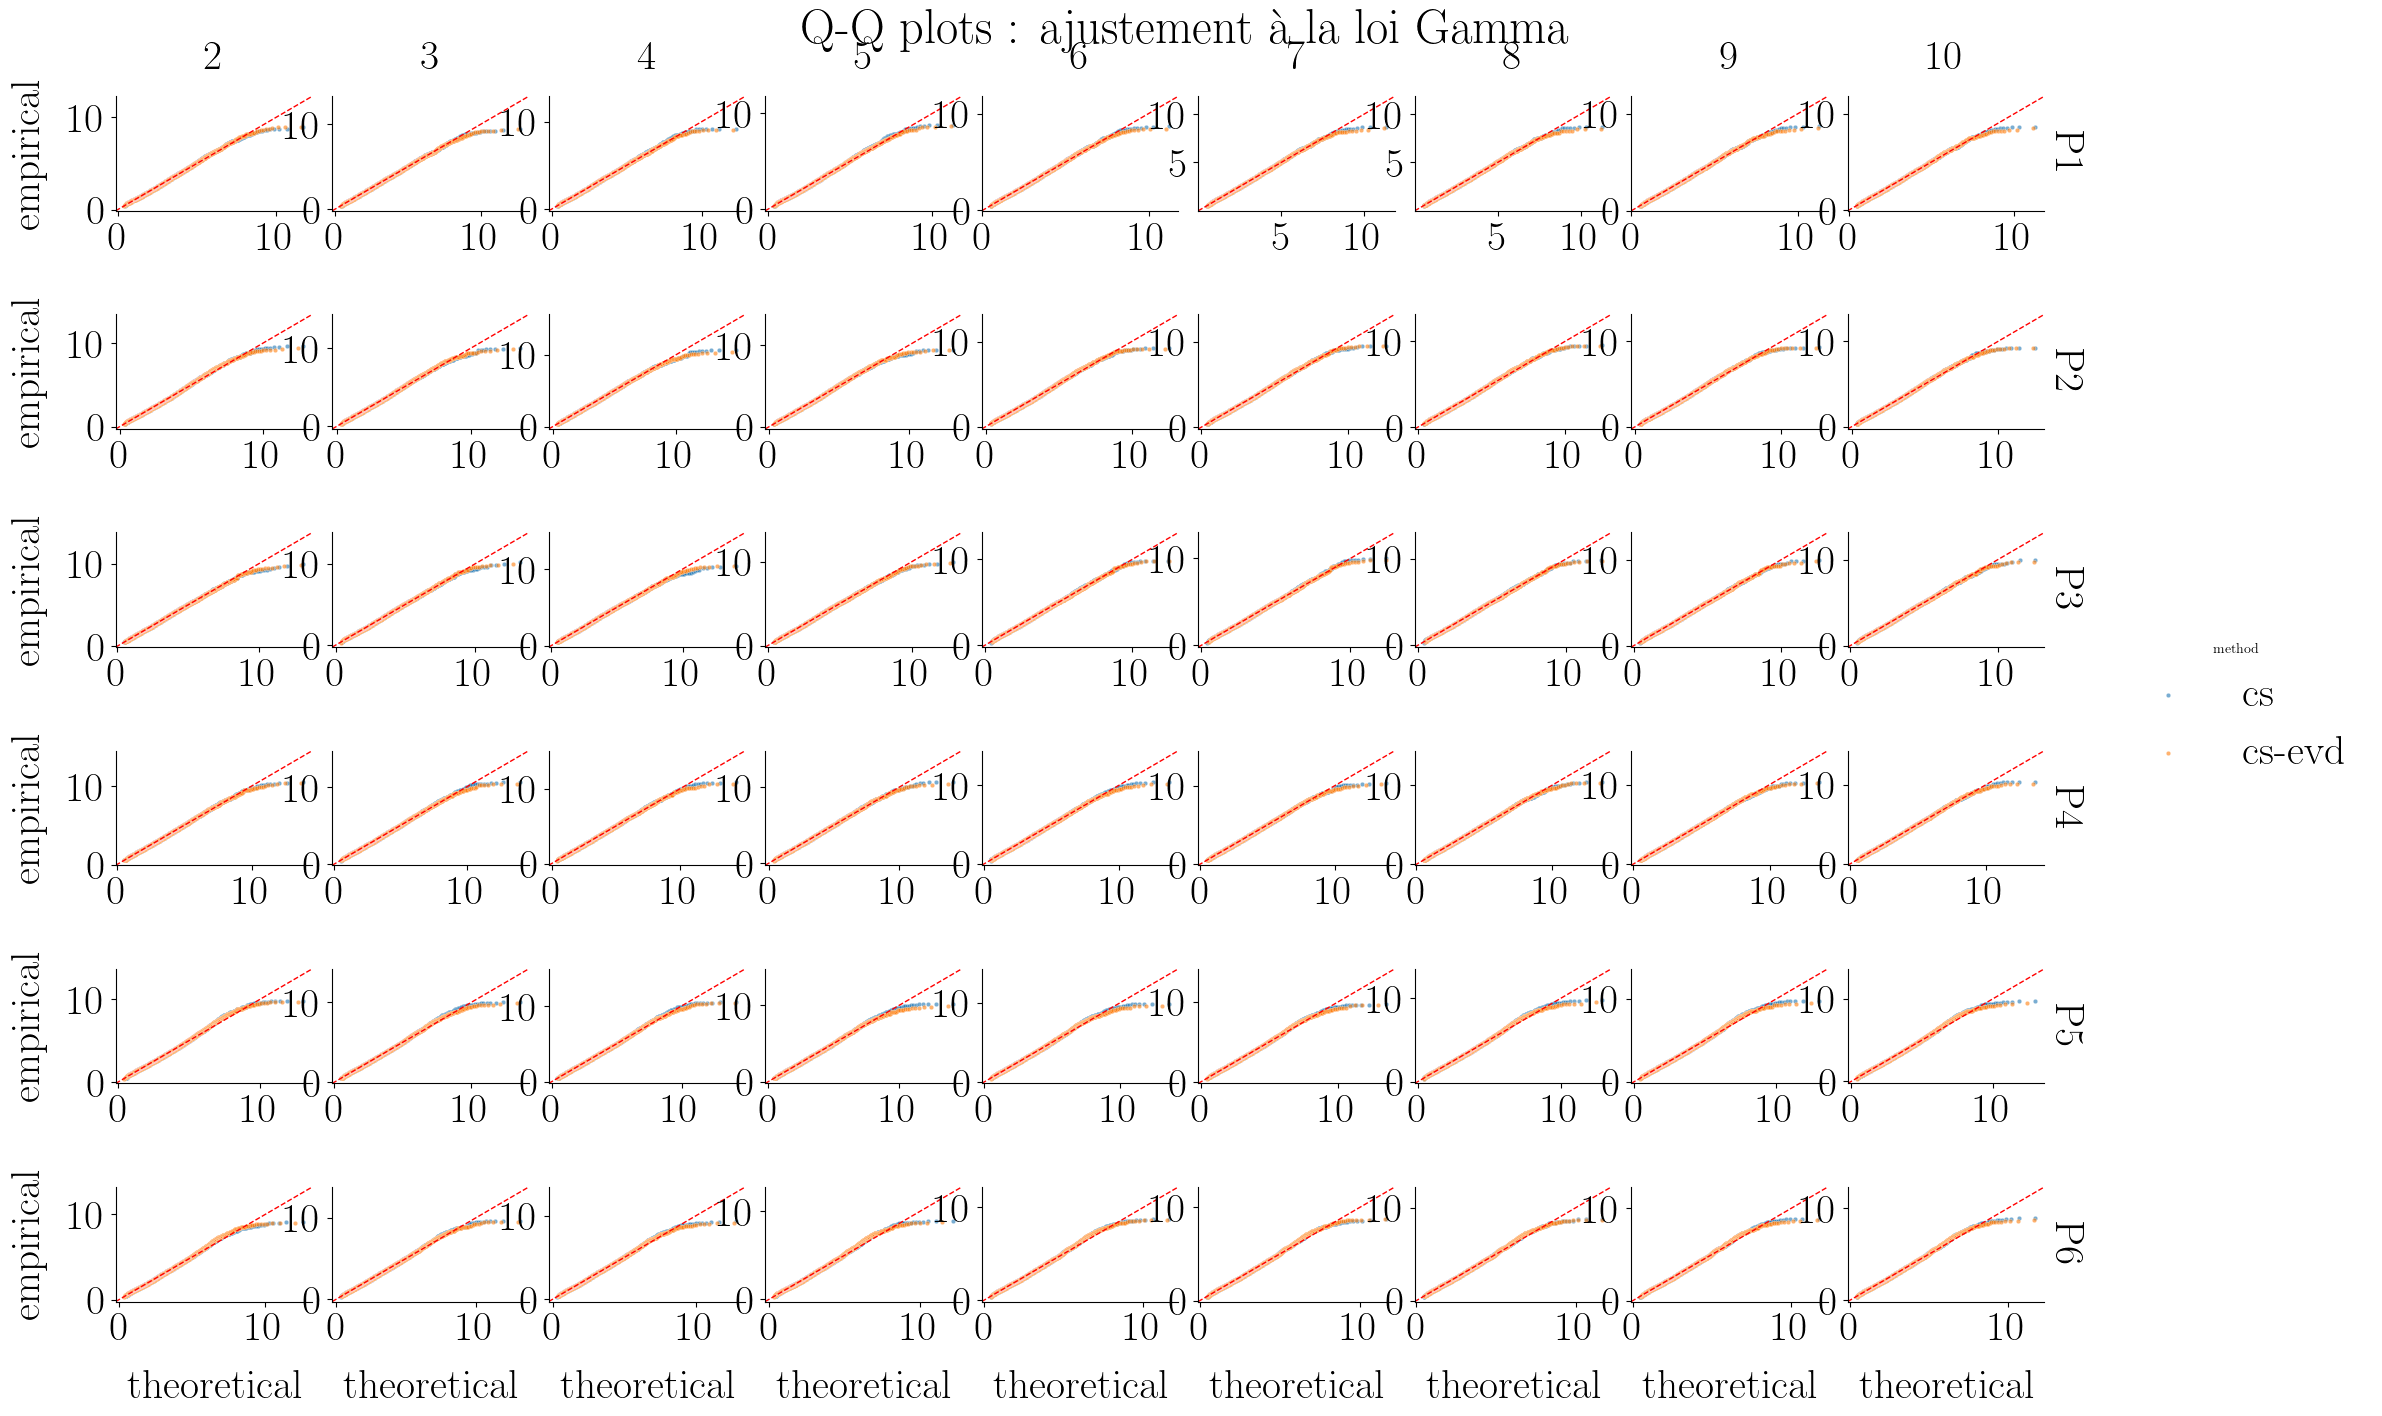

In [26]:
qq_plot(df_theta, law="gamma", filter=True)

##### Commentaires 

**Sans filtrage des données** : 
Meilleur ajustement qu'avec la loi de Rayleigh, on observe tout de même une divergence pour les quantiles élevés. Cette divergence est plus importante dans le cas de la méthode CS et les petites fenêtres d'analyse. 

**Après filtrage IQR**: Après filtrage l'ajustement diverge systématiquement pour les quantiles élevés. 
 


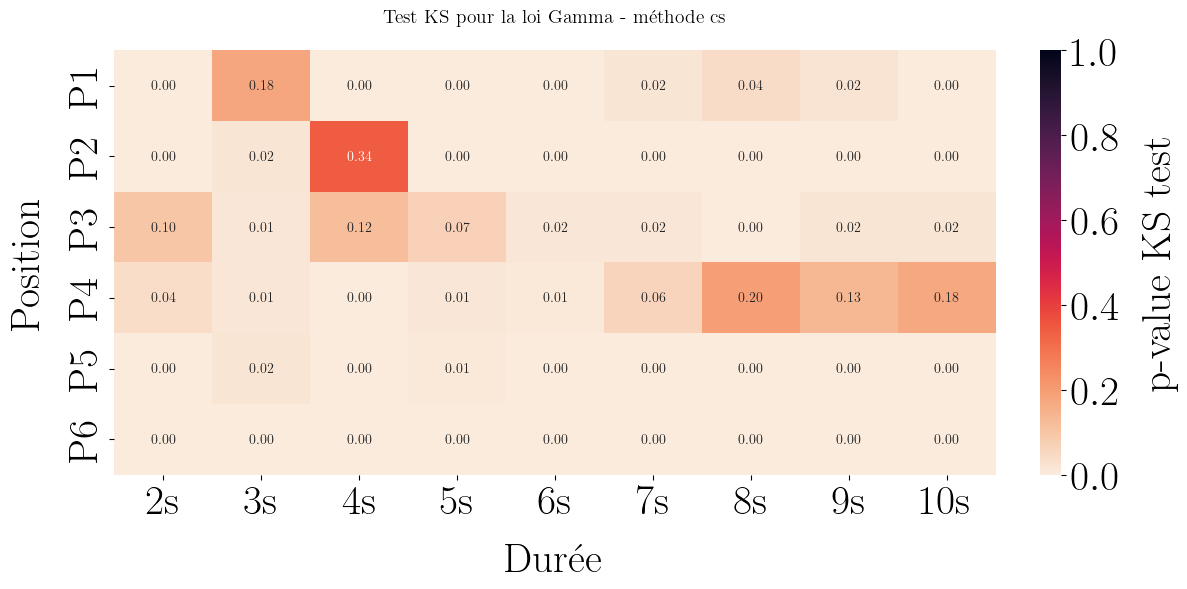

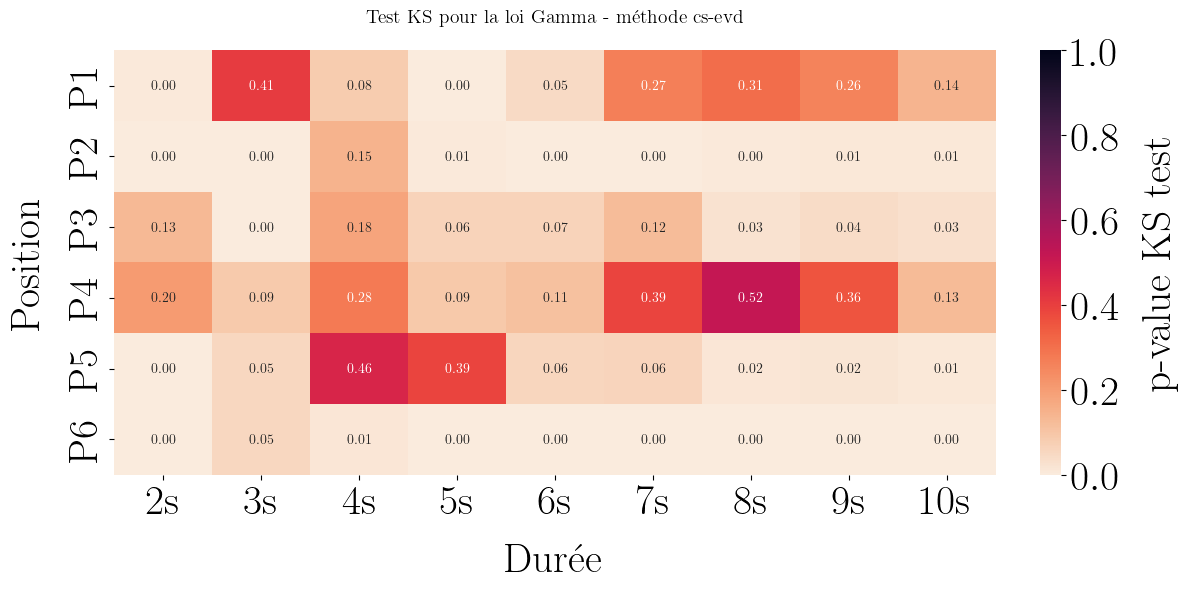

In [27]:
ks_test_heatmap(df_theta, law="gamma", filter=False)

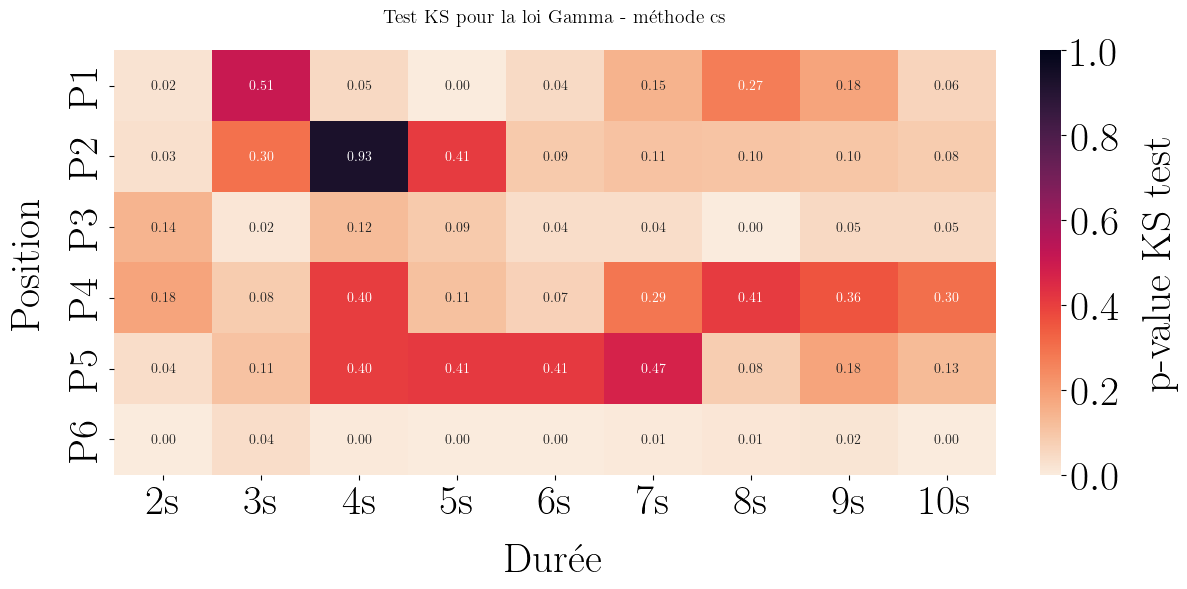

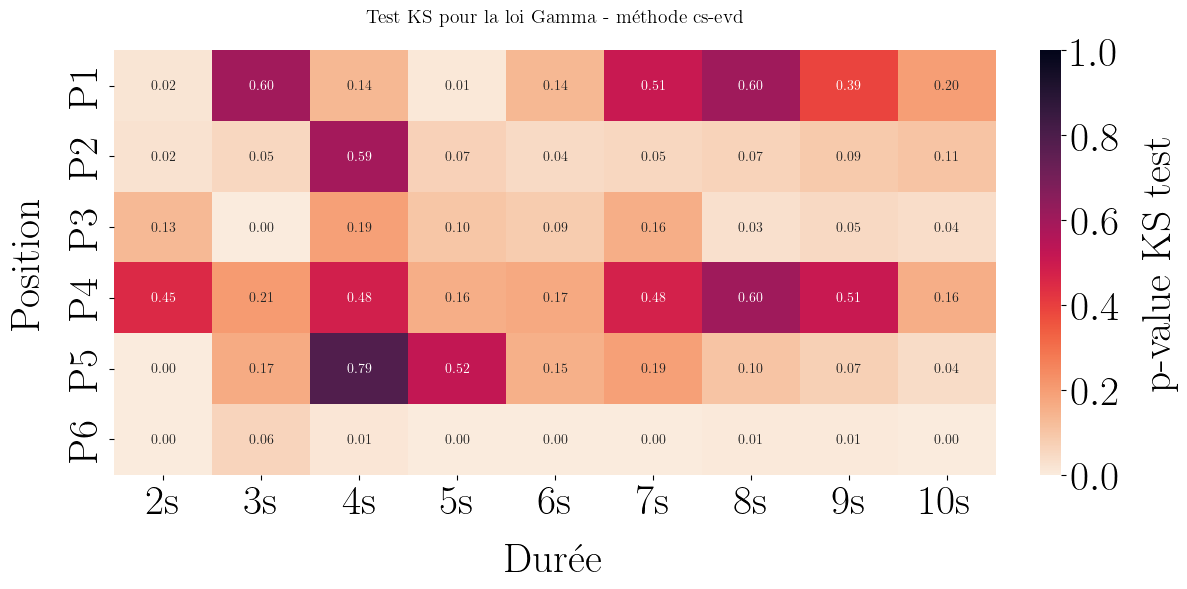

In [28]:
ks_test_heatmap(df_theta, law="gamma", filter=True)

##### Commentaires 

Le test KS confirme le mauvais ajustement avec une loi Gamma. L'ajustement est tout de même bien meilleur que la loi de Rayleigh. En particulier, certain couple (durée, position) peuvent présenter un bon ajustement. 

#### Comparaison d'une distribution Gamma ajustée 

Afin de confirmer le diagnostic posé à partir des Q-Q plots on peut comparer les distributions à une distribution Gamma ajustée aux données 

Filtered data summary:    method position  window_tf  n_before  n_after  n_removed  pct_removed
0  cs-evd       P1         10      5734     5710         24     0.418556
1  cs-evd       P2         10      5734     5705         29     0.505755
2  cs-evd       P3         10      5734     5720         14     0.244158
3  cs-evd       P4         10      5734     5716         18     0.313917
4  cs-evd       P5         10      5734     5706         28     0.488315
5  cs-evd       P6         10      5734     5709         25     0.435996
Fitted params: (3.115318896339818, 0.8298593723419648, 0.3586449397802485)


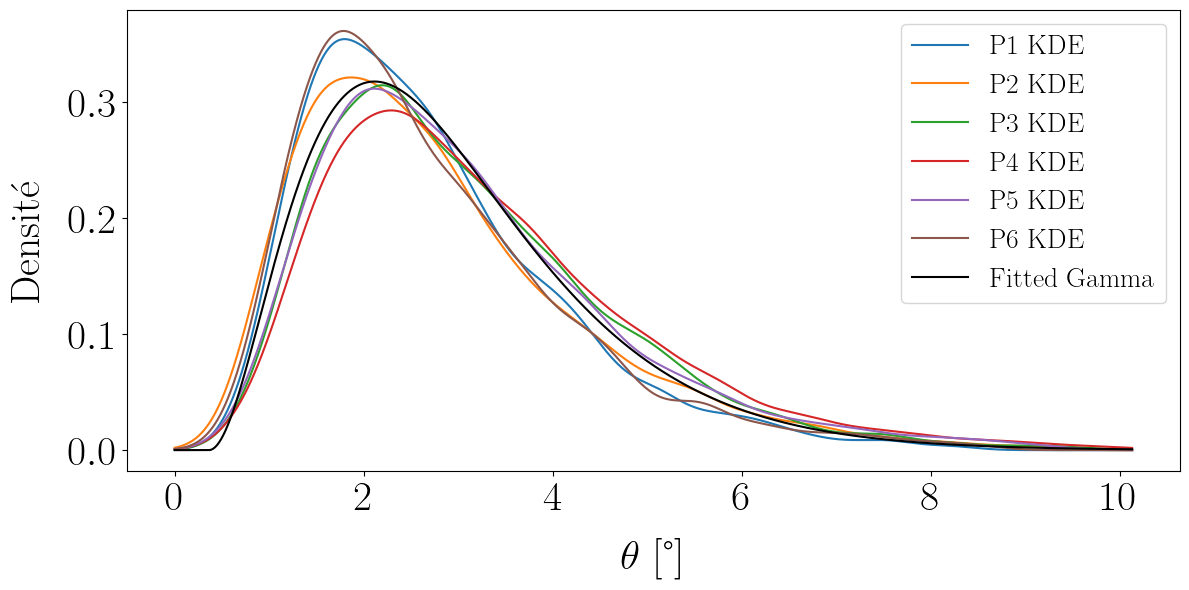

In [29]:
plot_fitted_vs_observed(df_theta, law="gamma", filter=True, win=10, method="cs-evd", params_stat="mean")

Filtered data summary:    method position  window_tf  n_before  n_after  n_removed  pct_removed
0  cs-evd       P2         10      5734     5705         29     0.505755
Fitted params: (2.871981540503733, 0.872191344636195, 0.3040360517272572)


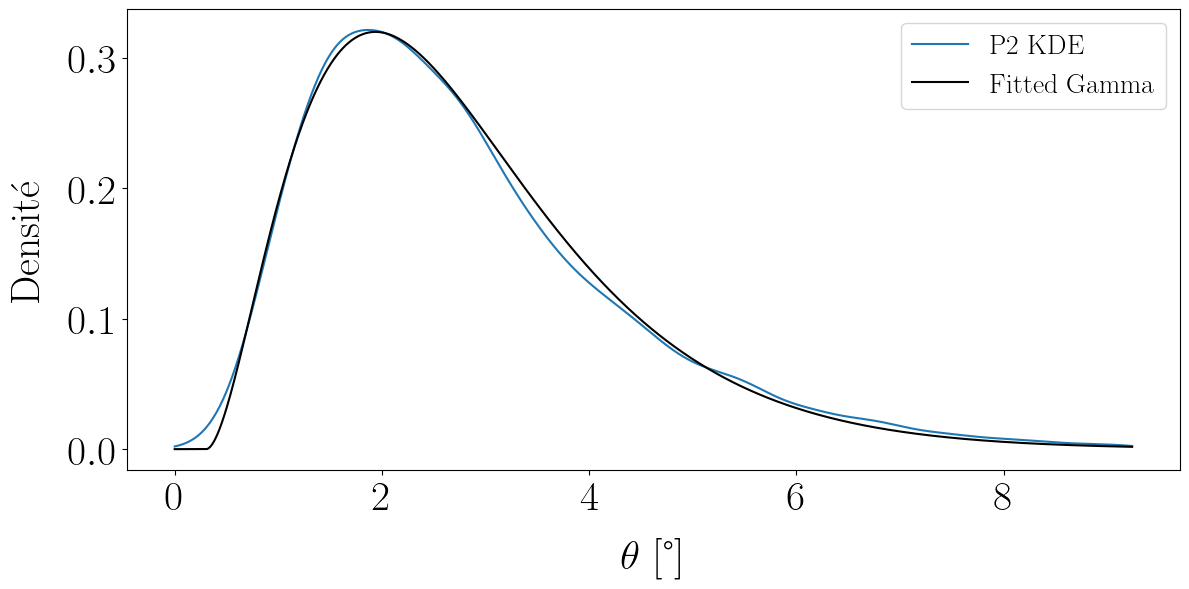

In [30]:
plot_fitted_vs_observed(
    df_theta, law="gamma", filter=True, win=10, method="cs-evd", pos="P2", params_stat="first"
)

##### Commentaires 

Pour un couple (durée, position) la loi Gamma représente un très bon ajustement. 

Significativité du test KS ? 

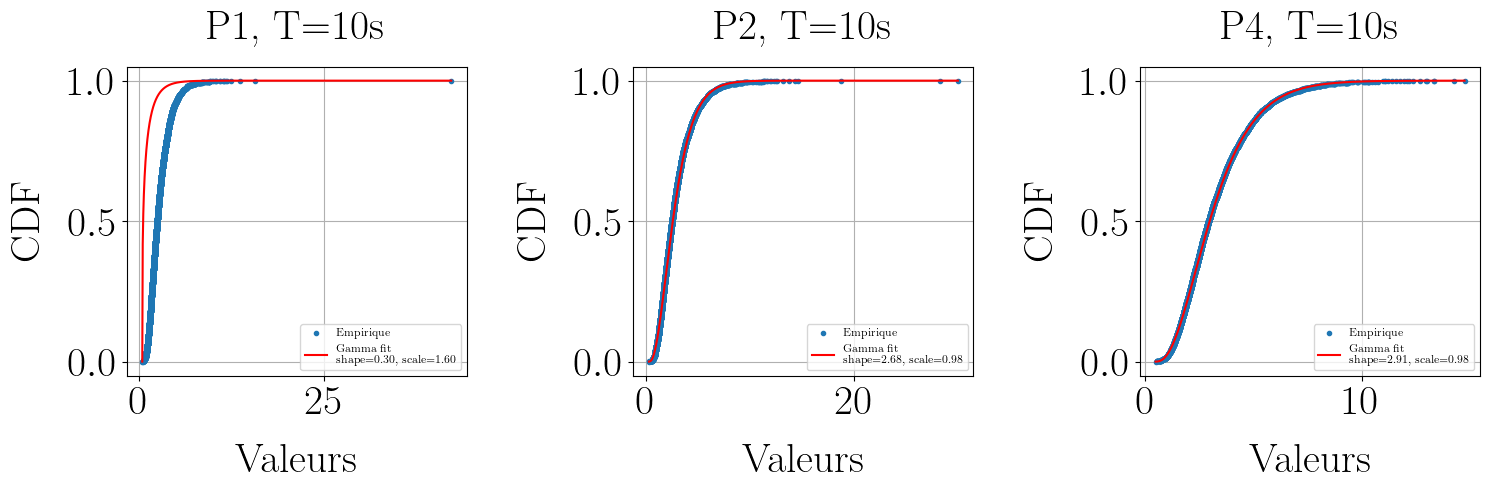

In [31]:
# Exemple pour méthode "cs", toutes les positions et window_tf = [5, 10]
# positions = ["P1", "P2", "P3", "P4", "P5", "P6"]
positions = ["P1", "P2", "P4"]

window_tfs = [10]  # ou plusieurs durées

plot_empirical_vs_gamma(
    df_theta, method="cs", positions=positions, window_tfs=window_tfs, figsize=(15, 5)
)

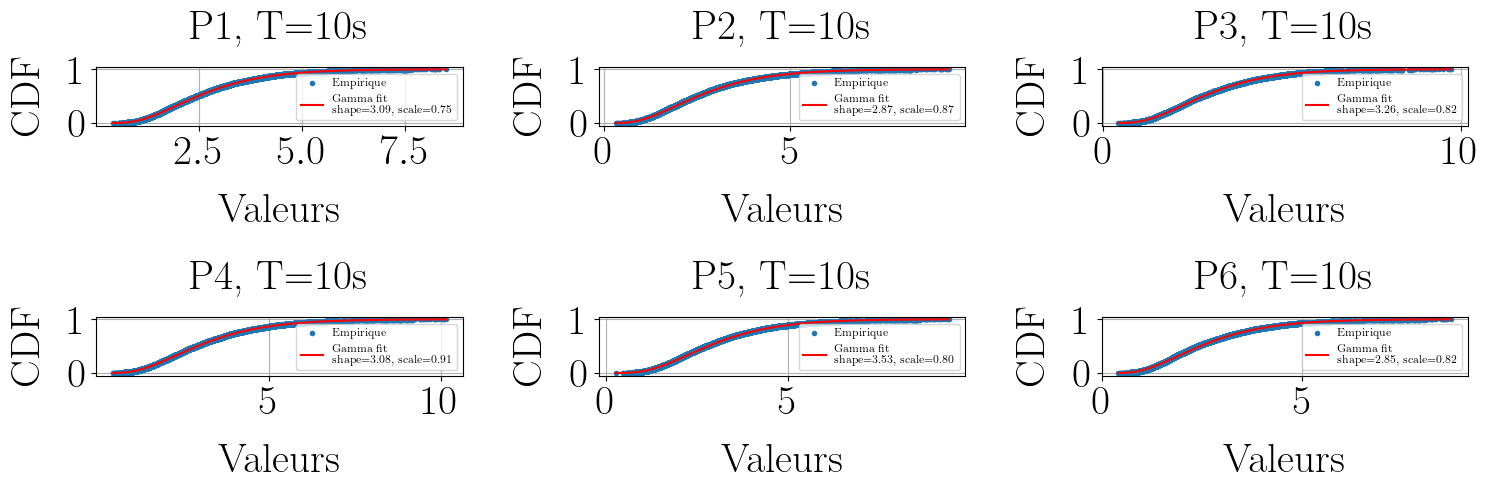

In [32]:
positions = ["P1", "P2", "P3", "P4", "P5", "P6"]
# positions = ["P5"]

window_tfs = [10]  # ou plusieurs durées

plot_empirical_vs_gamma(
    df_theta,
    method="cs-evd",
    positions=positions,
    window_tfs=window_tfs,
    filter=True,
    figsize=(15, 5),
)

## BILAN pour l'angle hermitien 

Malgré le fait que l'ajustement Gamma ne soit pas valider par le test KS il présente visuellement (Q-Q plot, pdf, cdf) un ajustement satisfaisant et pourrait ainsi être utilisé :

* Comme référence pour estimer un paramètre caractéristique de la distribution d'angle, par exemple avec l'espérance de la distribution :

$$ X \sim \Gamma(\alpha, \beta), \quad \mathcal{E}[X] = \frac{\alpha}{\beta} $$

## Étude de la distribution de la distance de frobenius

In [33]:
df_frobenius

,method,record,array_index,value,position,window_tf
0,cs,09-10-2024T10-34-58-394627_P1_N1_Sweep_34,0,0.014654,P1,2
1,cs,09-10-2024T10-34-58-394627_P1_N1_Sweep_34,0,0.003769,P1,2
2,cs,09-10-2024T10-34-58-394627_P1_N1_Sweep_34,0,0.004499,P1,2
3,cs,09-10-2024T10-34-58-394627_P1_N1_Sweep_34,0,0.025362,P1,2
4,cs,09-10-2024T10-34-58-394627_P1_N1_Sweep_34,0,0.135534,P1,2
...,...,...,...,...,...,...
619267,cs-evd,10-10-2024T15-54-25-737795_P6_N1_Sweep_323,8,0.047757,P6,10
619268,cs-evd,10-10-2024T15-54-25-737795_P6_N1_Sweep_323,8,0.166079,P6,10
619269,cs-evd,10-10-2024T15-54-25-737795_P6_N1_Sweep_323,8,0.132799,P6,10
619270,cs-evd,10-10-2024T15-54-25-737795_P6_N1_Sweep_323,8,0.130651,P6,10


### Box plot pour chacune des positions

Chacun des box plots est obtenus à partir de l'ensemble des distributions (i.e pour différentes durées de signal). Ce graphe nous donne une première idée générale de l'allure des distributions mais ne dit rien de la variabilité en fonction de la durée du signal. 

Text(0.5, 0, 'Position')

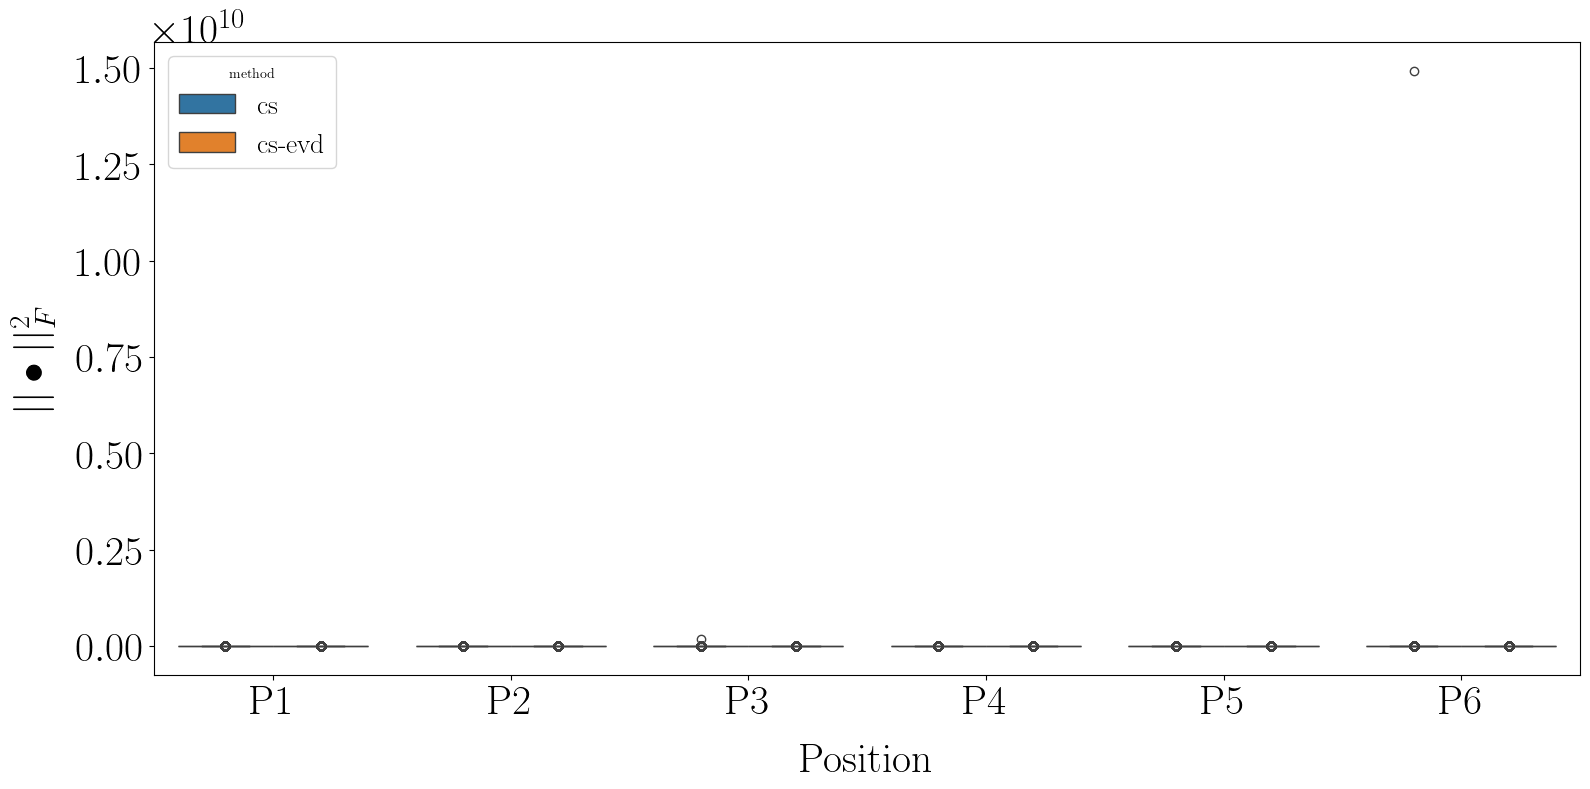

In [34]:
# Boxplot at each position
frobenius_norm_label = r"$|| \bullet ||_{F}^2$"
sns.boxplot(data=df_frobenius, x="position", y="value", hue="method")
plt.ylabel(frobenius_norm_label)
plt.xlabel("Position")

#### Commentaires 

Quelques rares valeurs aberrantes faussent la représentation. 

#### Sans les outlayers pour voir les médianes

Text(0.5, 0, 'Position')

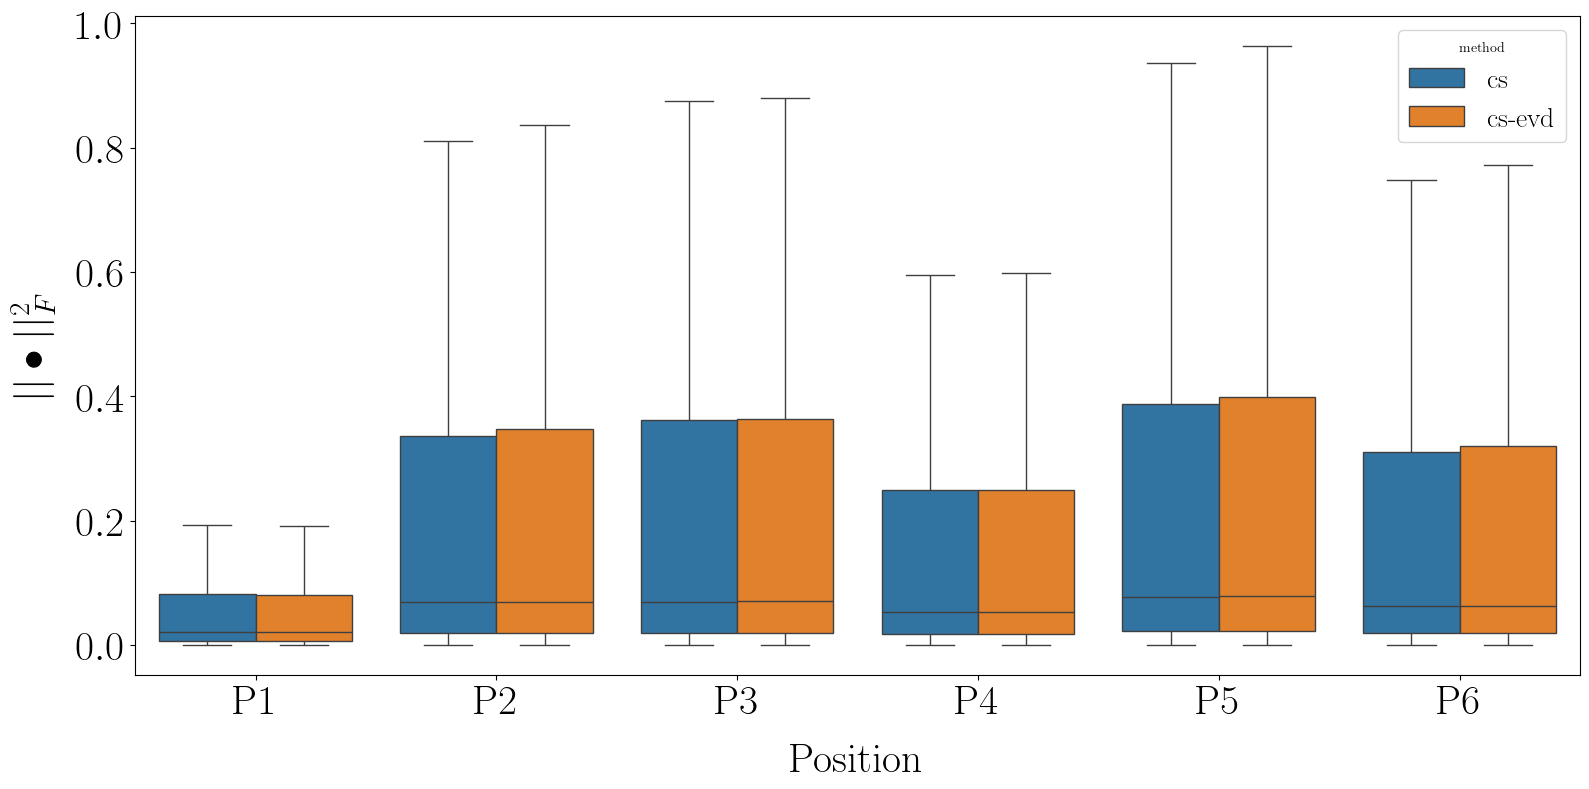

In [35]:
# Violin at each position
sns.boxplot(data=df_frobenius, x="position", y="value", hue="method", showfliers=False)
plt.ylabel(frobenius_norm_label)
plt.xlabel("Position")

#### Commentaires 

Les distributions ne sont pas gaussiennes. 

Au vu des valeurs aberrantes il faut filtrer.  

### Distributions pour l'ensemble des combinaisons (position, durée) 

Filtered data summary:      method position  window_tf  n_before  n_after  n_removed  pct_removed
0        cs       P1          2      5734     5016        718    12.521800
1        cs       P1          3      5734     5004        730    12.731078
2        cs       P1          4      5734     5010        724    12.626439
3        cs       P1          5      5734     5017        717    12.504360
4        cs       P1          6      5734     5014        720    12.556679
..      ...      ...        ...       ...      ...        ...          ...
103  cs-evd       P6          6      5734     4946        788    13.742588
104  cs-evd       P6          7      5734     4942        792    13.812347
105  cs-evd       P6          8      5734     4941        793    13.829787
106  cs-evd       P6          9      5734     4938        796    13.882107
107  cs-evd       P6         10      5734     4943        791    13.794908

[108 rows x 7 columns]


c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


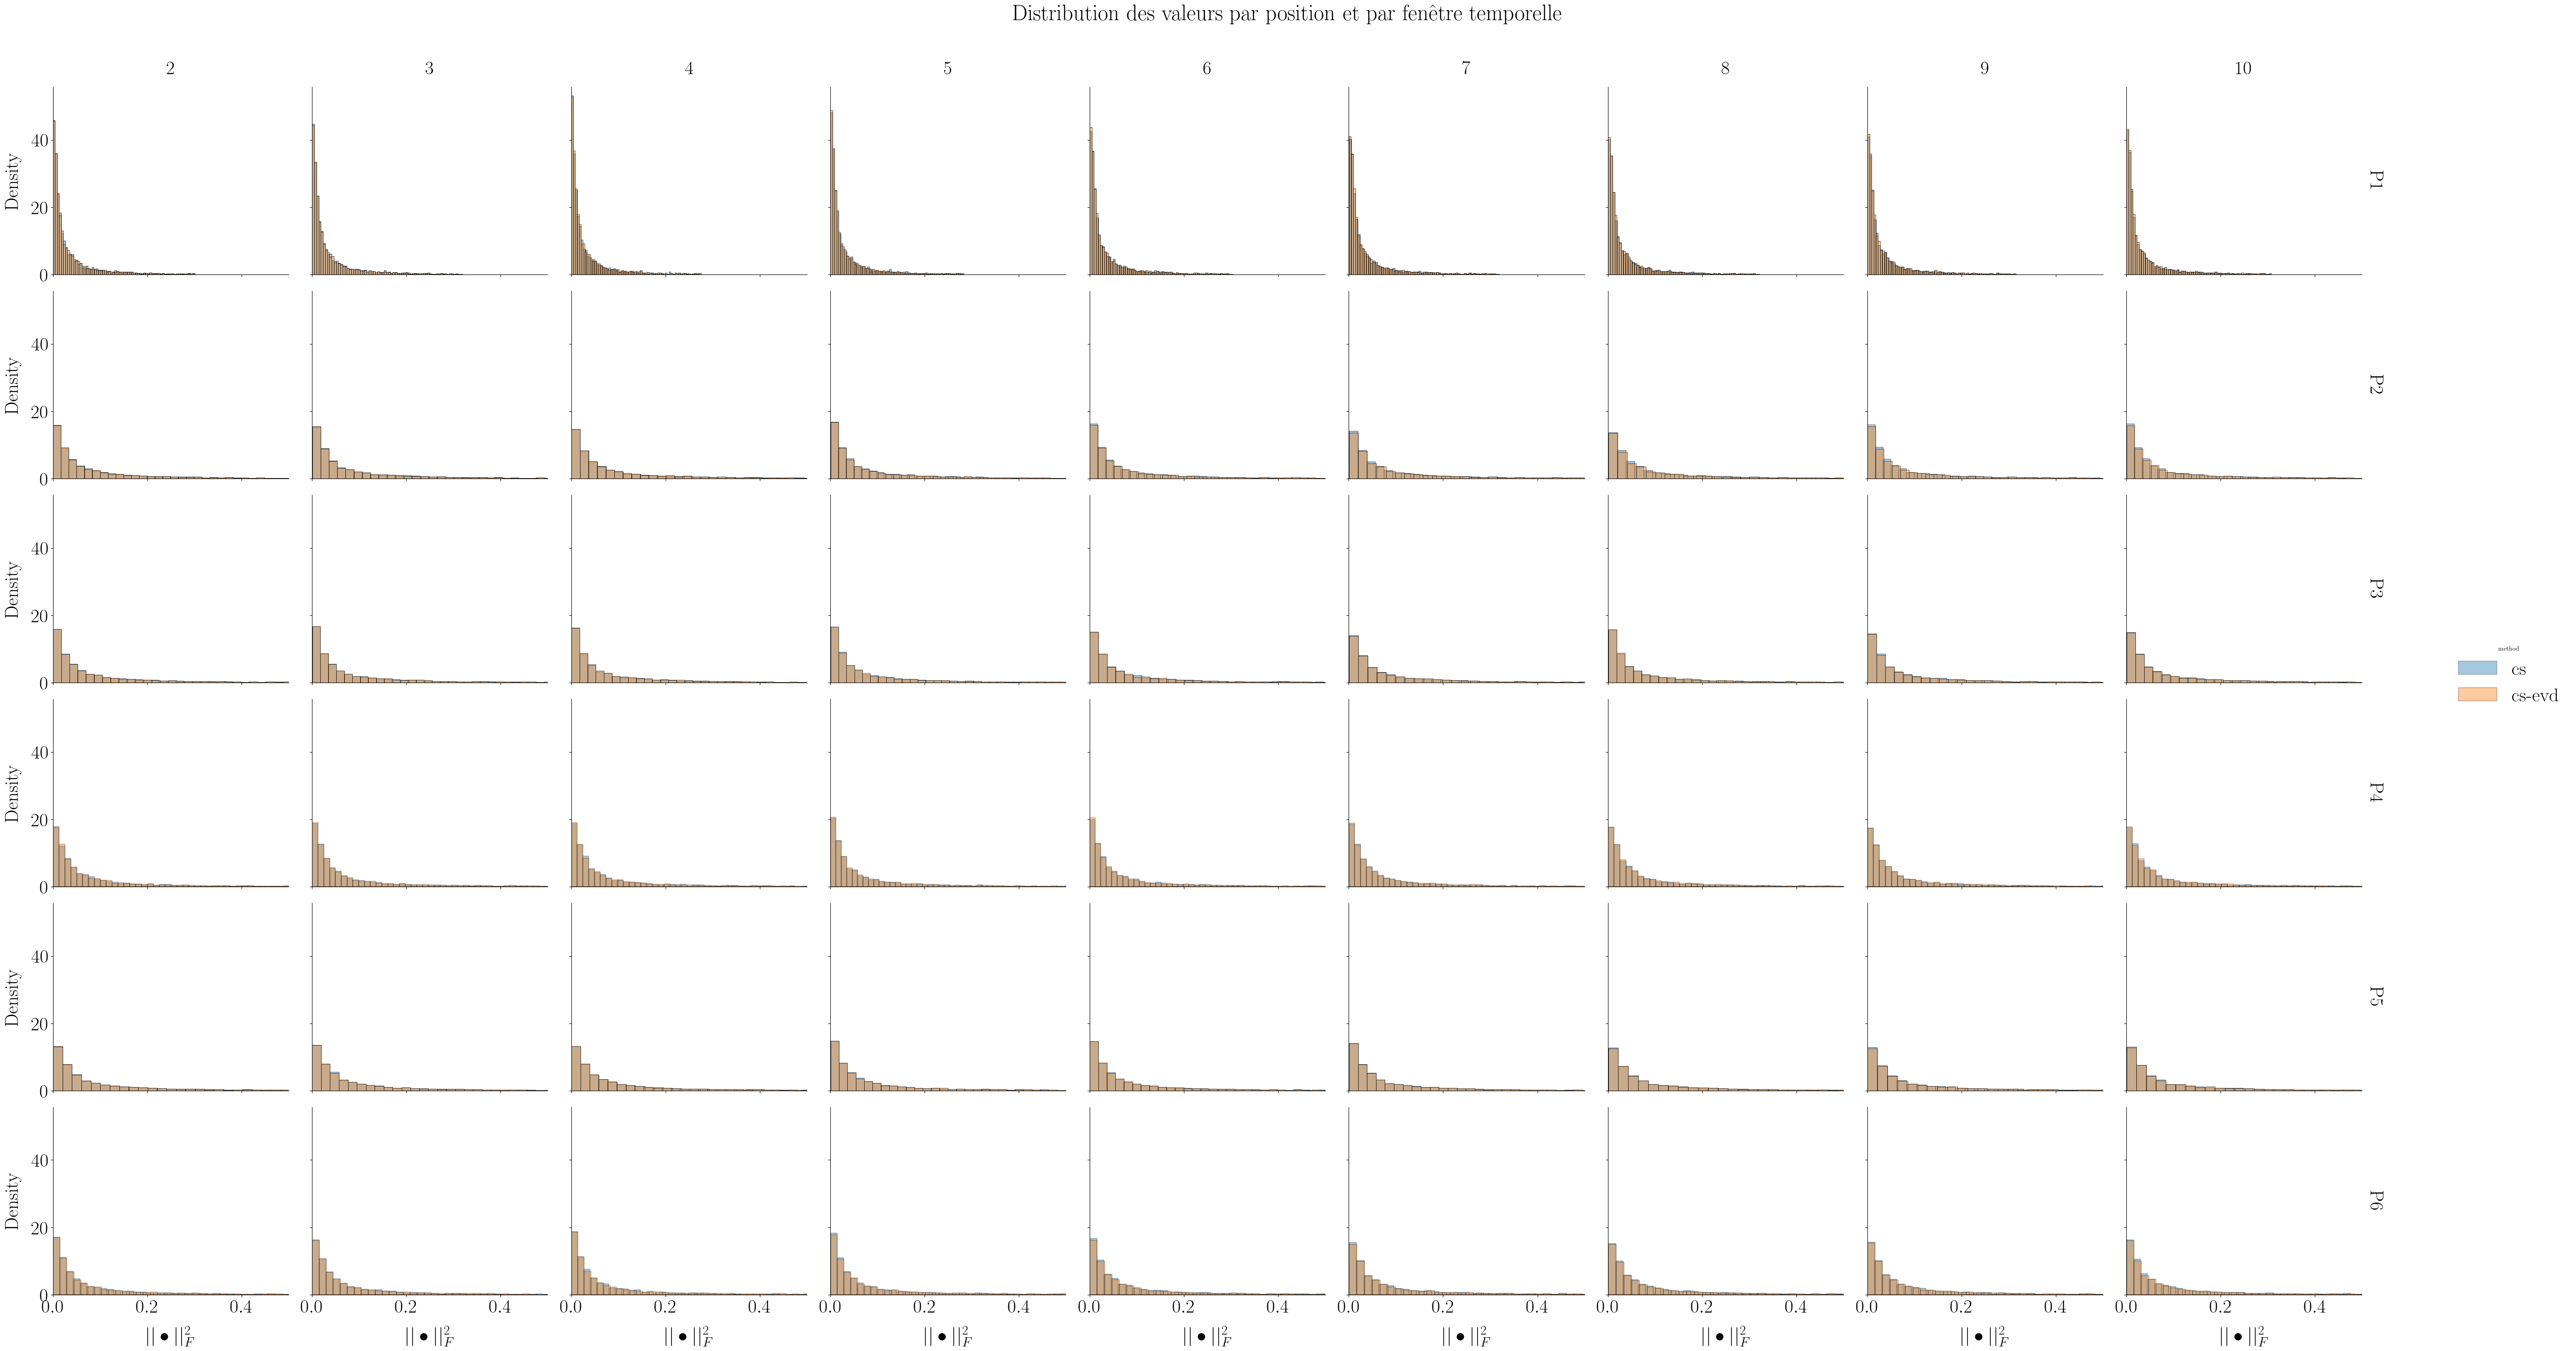

In [36]:
g = plot_all_distribution_panel(
    df_frobenius, filter=True, value_label=frobenius_norm_label, plot_type="hist"
)
g.set(xlim=(0, 0.5))
g.figure.subplots_adjust(top=0.92, wspace=0.1)

#### Commentaires 

Pourcentage de valeurs aberrantes exclues plus important que pour l'angle hermitien $\approx$ 7 %. 

La distribution de la position P1 est significativement différentes des autres positions. 

### Comparaison des distributions aux différentes positions 

Filtered data summary:     method position  window_tf  n_before  n_after  n_removed  pct_removed
0       cs       P1         10      5734     5024        710    12.382281
1       cs       P2         10      5734     4980        754    13.149634
2       cs       P3         10      5734     4982        752    13.114754
3       cs       P4         10      5734     4966        768    13.393791
4       cs       P5         10      5734     4975        759    13.236833
5       cs       P6         10      5734     4934        800    13.951866
6   cs-evd       P1         10      5734     5010        724    12.626439
7   cs-evd       P2         10      5734     4990        744    12.975235
8   cs-evd       P3         10      5734     4973        761    13.271713
9   cs-evd       P4         10      5734     4954        780    13.603069
10  cs-evd       P5         10      5734     4964        770    13.428671
11  cs-evd       P6         10      5734     4943        791    13.794908


c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


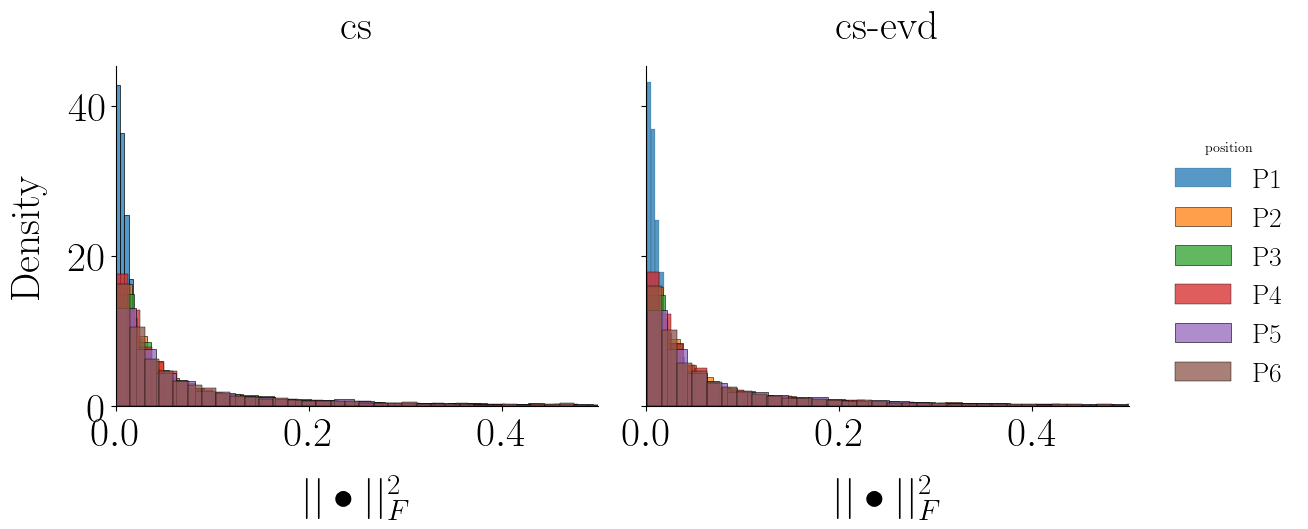

In [37]:
df_group = df_frobenius[(df_frobenius["window_tf"] == 10)]
g = plot_distribution_panel_single_window(df_group, filter=True, value_label=frobenius_norm_label, plot_type="hist")
g.set(xlim=(0, 0.5))
g.figure.subplots_adjust(top=0.92, wspace=0.1)

#### Commentaires 

Confirmation du cas particulier en P1. 

### Comparaison des distributions pour les différentes tailles de fenêtres 

Filtered data summary:     method position  window_tf  n_before  n_after  n_removed  pct_removed
0       cs       P1          2      5734     5016        718    12.521800
1       cs       P1          3      5734     5004        730    12.731078
2       cs       P1          4      5734     5010        724    12.626439
3       cs       P1          5      5734     5017        717    12.504360
4       cs       P1          6      5734     5014        720    12.556679
5       cs       P1          7      5734     5018        716    12.486920
6       cs       P1          8      5734     5017        717    12.504360
7       cs       P1          9      5734     5016        718    12.521800
8       cs       P1         10      5734     5024        710    12.382281
9   cs-evd       P1          2      5734     4991        743    12.957796
10  cs-evd       P1          3      5734     4994        740    12.905476
11  cs-evd       P1          4      5734     4989        745    12.992675
12  cs-evd     

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


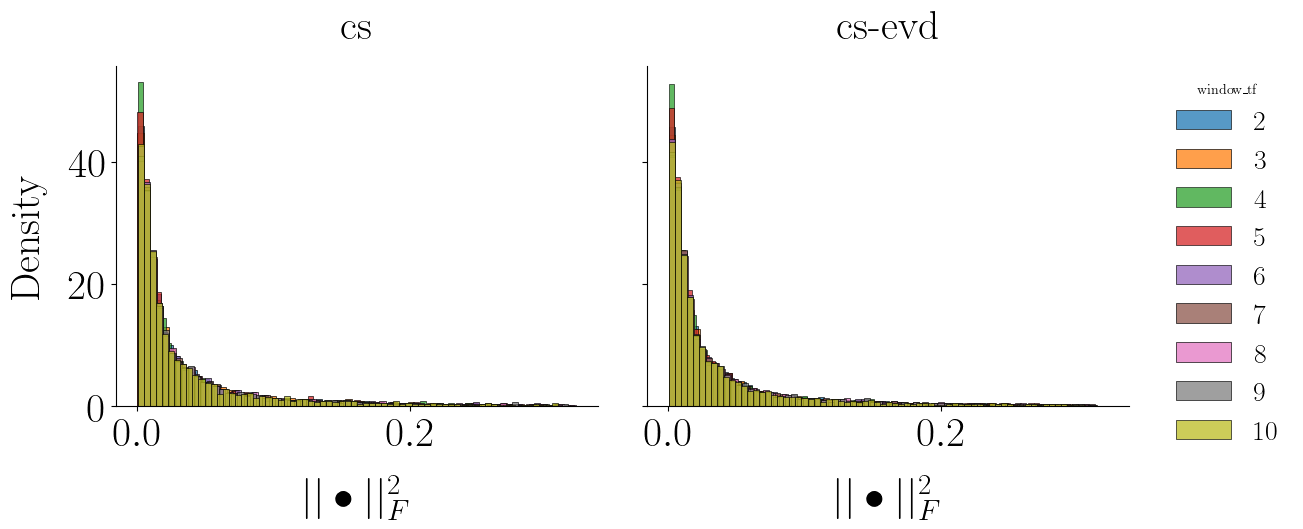

In [38]:
df_group = df_frobenius[(df_frobenius["position"] == "P1")]

g = plot_distribution_panel_single_position(df_group, filter=True, value_label=frobenius_norm_label, plot_type="hist")
# g.set(xlim=(0, 20))
g.figure.subplots_adjust(top=0.92, wspace=0.1)

#### Commentaires

Pas de variations significatives en fonction de la durée du signal 

### Distributions de Rayleigh ? 

#### Q-Q plot 

Une première façon de visualiser l'ajustement des données avec une loi de Rayleigh est le Q-Q plot.

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


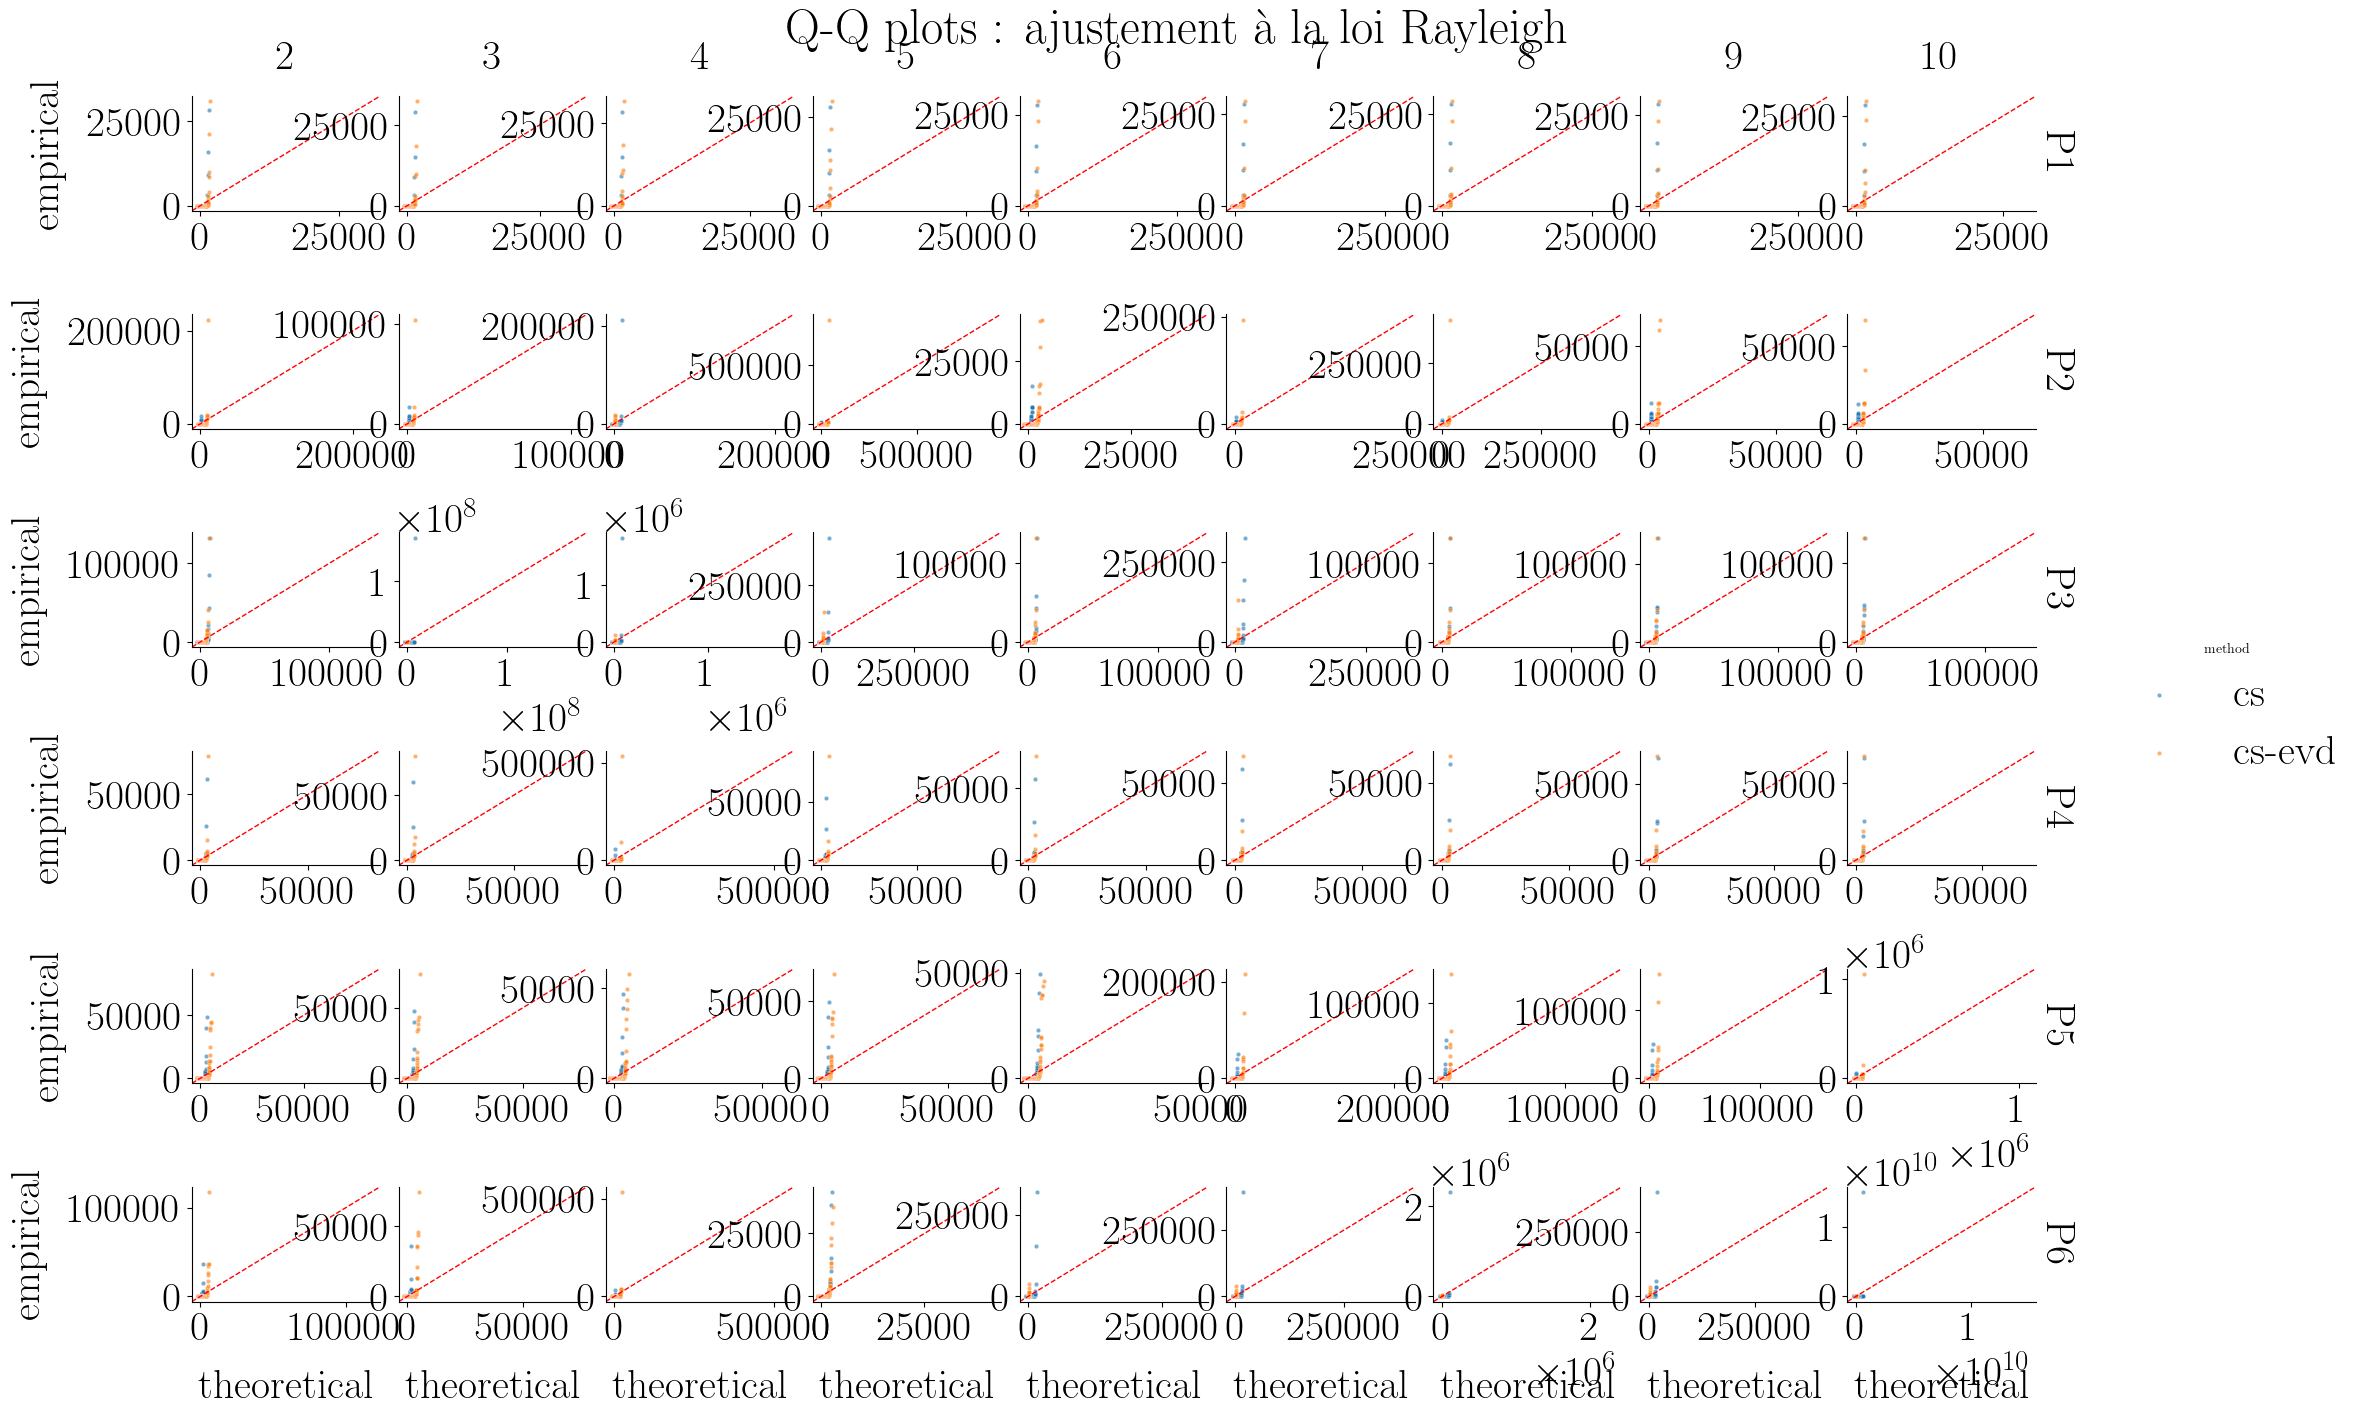

In [39]:
g = qq_plot(df_frobenius, law="rayleigh", filter=False)


c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


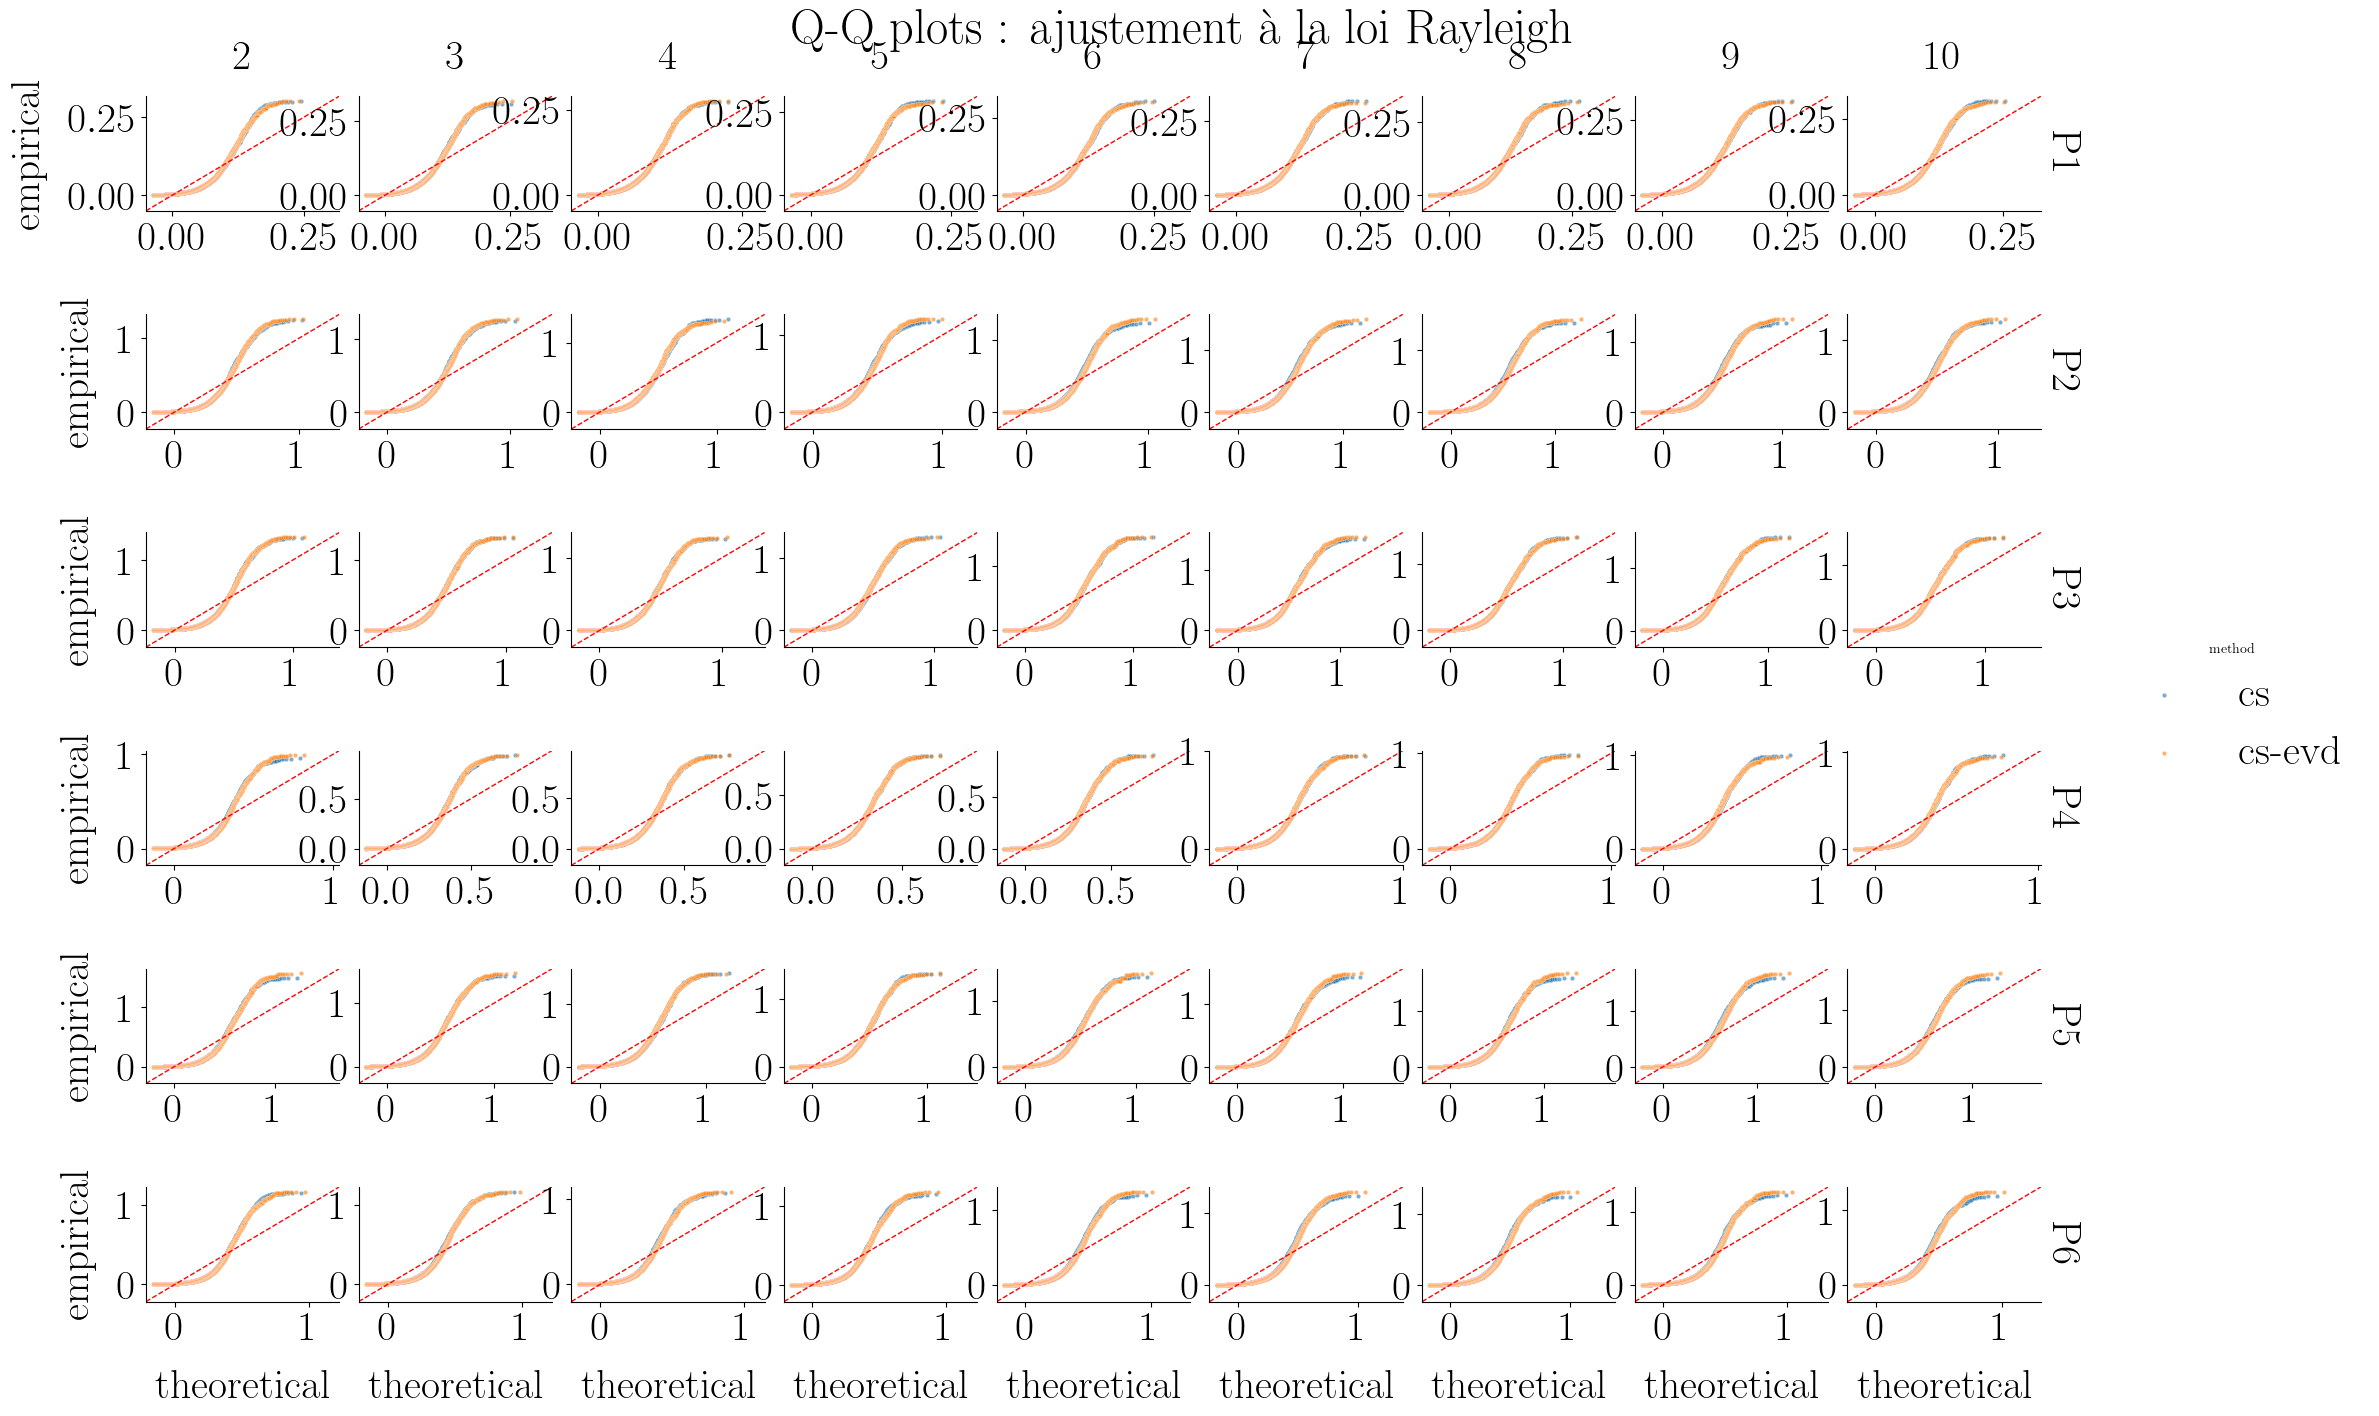

In [40]:
g = qq_plot(df_frobenius, law="rayleigh", filter=True)


##### Commentaires 

**Sans filtrage des données** : 
Très mauvais ajustement. 

**Après filtrage IQR**: Mauvais ajustement, les Q-Q plots exhibent clairement une forme en S caractéristique d'un écart au niveau de la queue de la distribution. 
 


#### Test de Kolmogorov-Smirnov (KS)

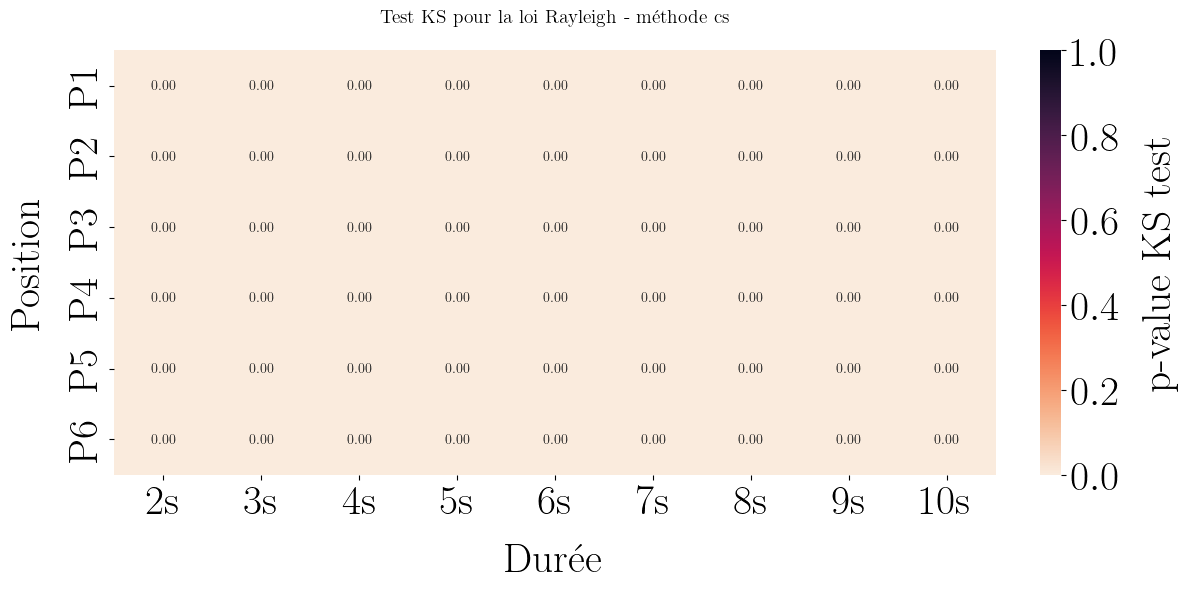

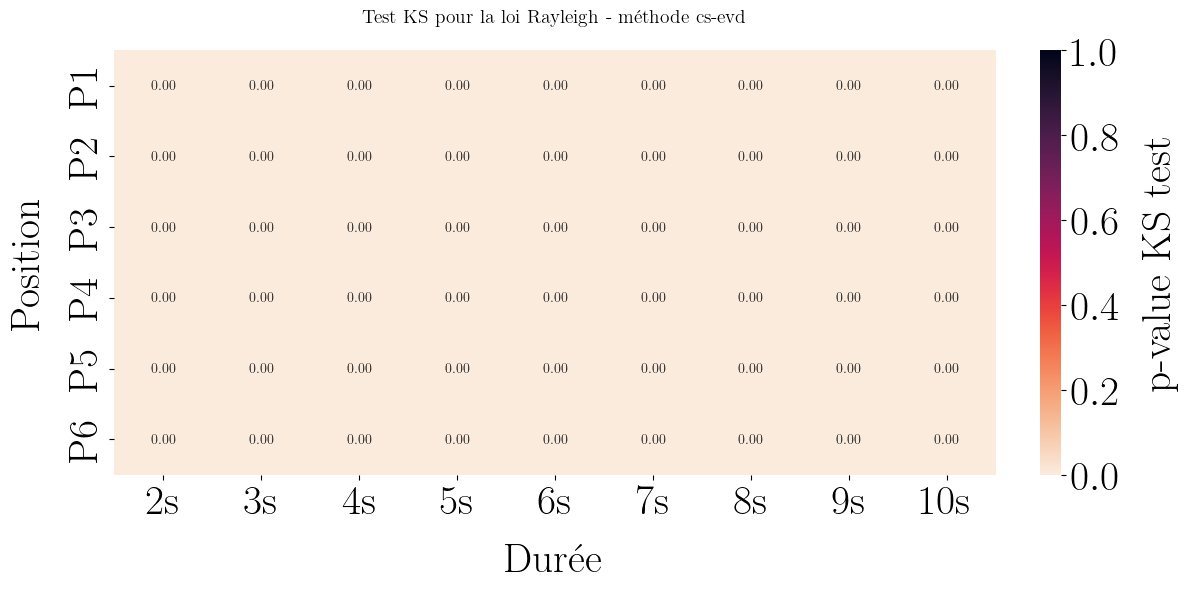

In [41]:
ks_test_heatmap(df_frobenius, law="rayleigh", filter=False)

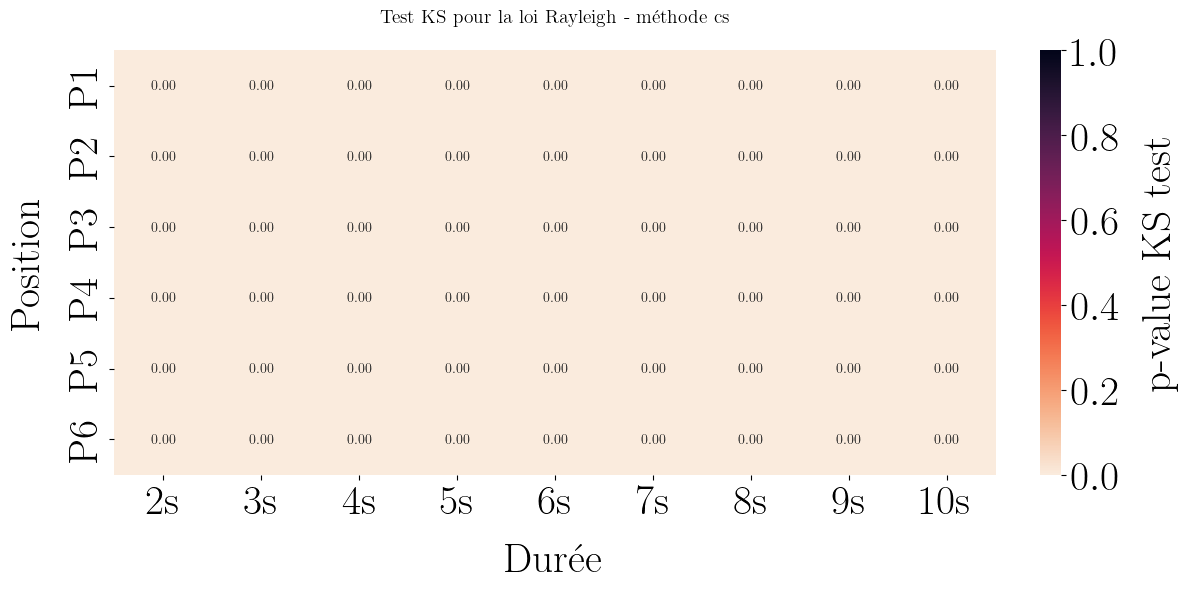

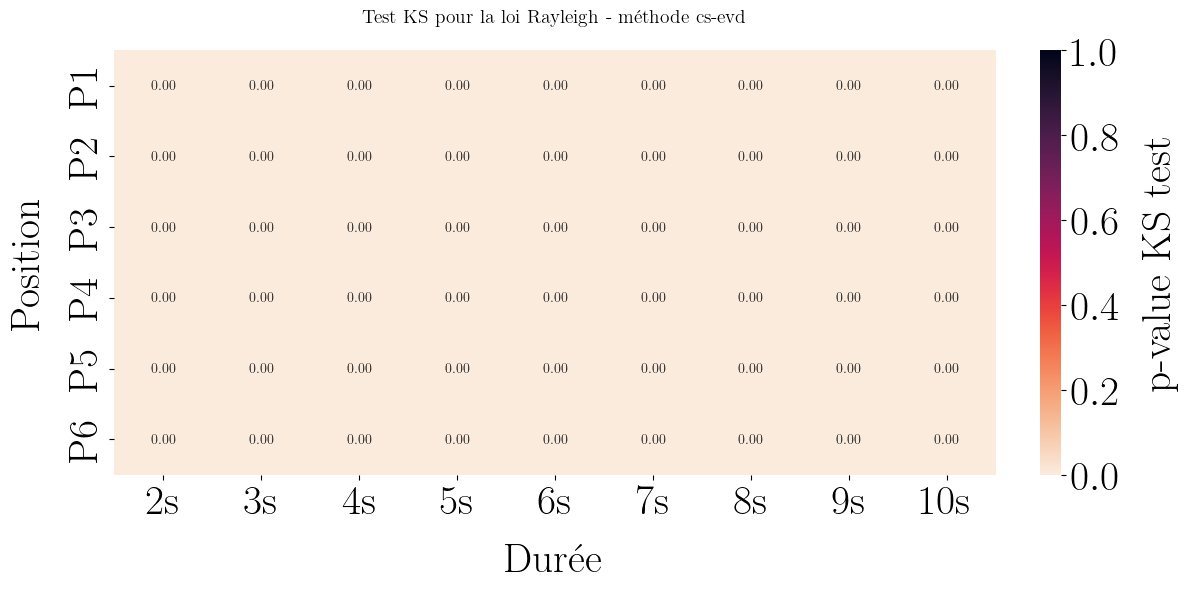

In [42]:
ks_test_heatmap(df_frobenius, law="rayleigh", filter=True)

##### Commentaires 

Le test KS confirme le mauvais ajustement avec une loi de Rayleigh. 

#### Comparaison d'une distribution Rayleigh ajustée 

Afin de confirmer le diagnostic posé à partir des Q-Q plots on peut comparer les distributions à une distribution de Rayleigh ajustée aux données 

Filtered data summary:    method position  window_tf  n_before  n_after  n_removed  pct_removed
0  cs-evd       P1         10      5734     5010        724    12.626439
1  cs-evd       P2         10      5734     4990        744    12.975235
2  cs-evd       P3         10      5734     4973        761    13.271713
3  cs-evd       P4         10      5734     4954        780    13.603069
4  cs-evd       P5         10      5734     4964        770    13.428671
5  cs-evd       P6         10      5734     4943        791    13.794908


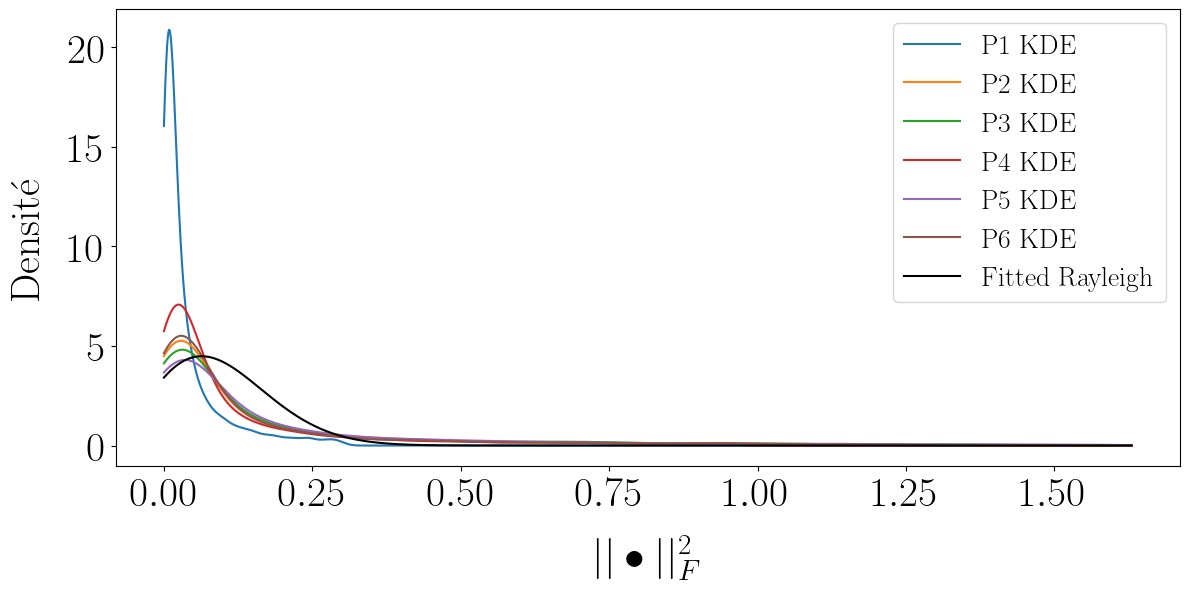

In [43]:
plot_fitted_vs_observed(df_frobenius, law="rayleigh", filter=True, win=10, method="cs-evd", params_stat="mean", value_label=frobenius_norm_label)
# plt.xlim((-5, 10))

Filtered data summary:    method position  window_tf  n_before  n_after  n_removed  pct_removed
0  cs-evd       P2         10      5734     4990        744    12.975235


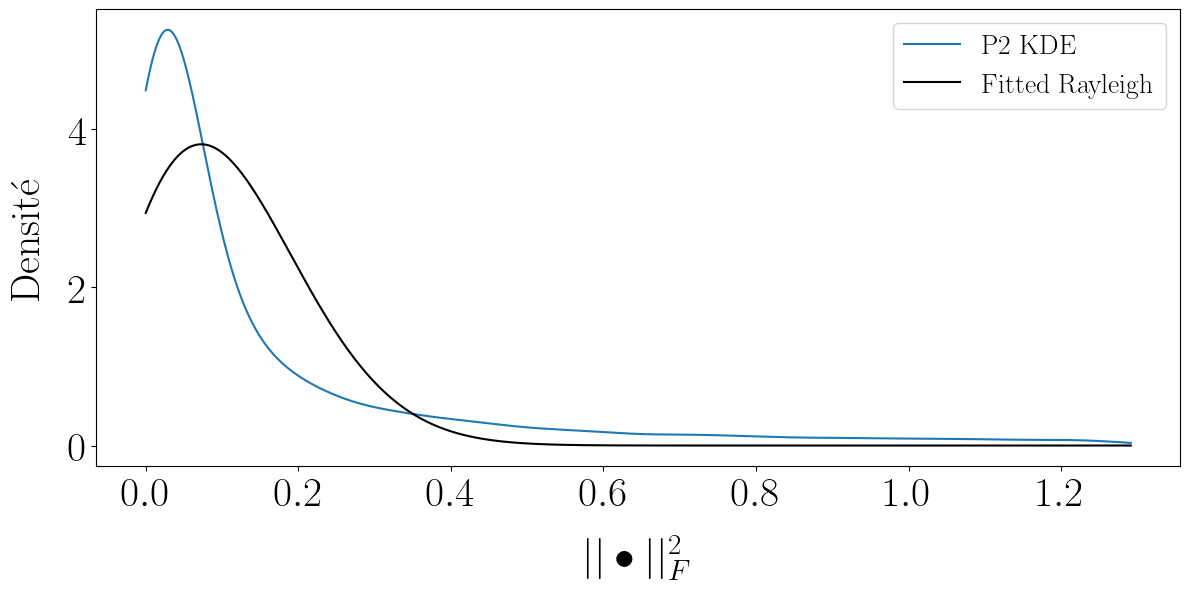

In [44]:
plot_fitted_vs_observed(df_frobenius, law="rayleigh", filter=True, win=10, method="cs-evd", pos="P2", params_stat="first", value_label=frobenius_norm_label)
# plt.xlim((-5, 10))

### Distribution Gamma ? 


#### Q-Q plot

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


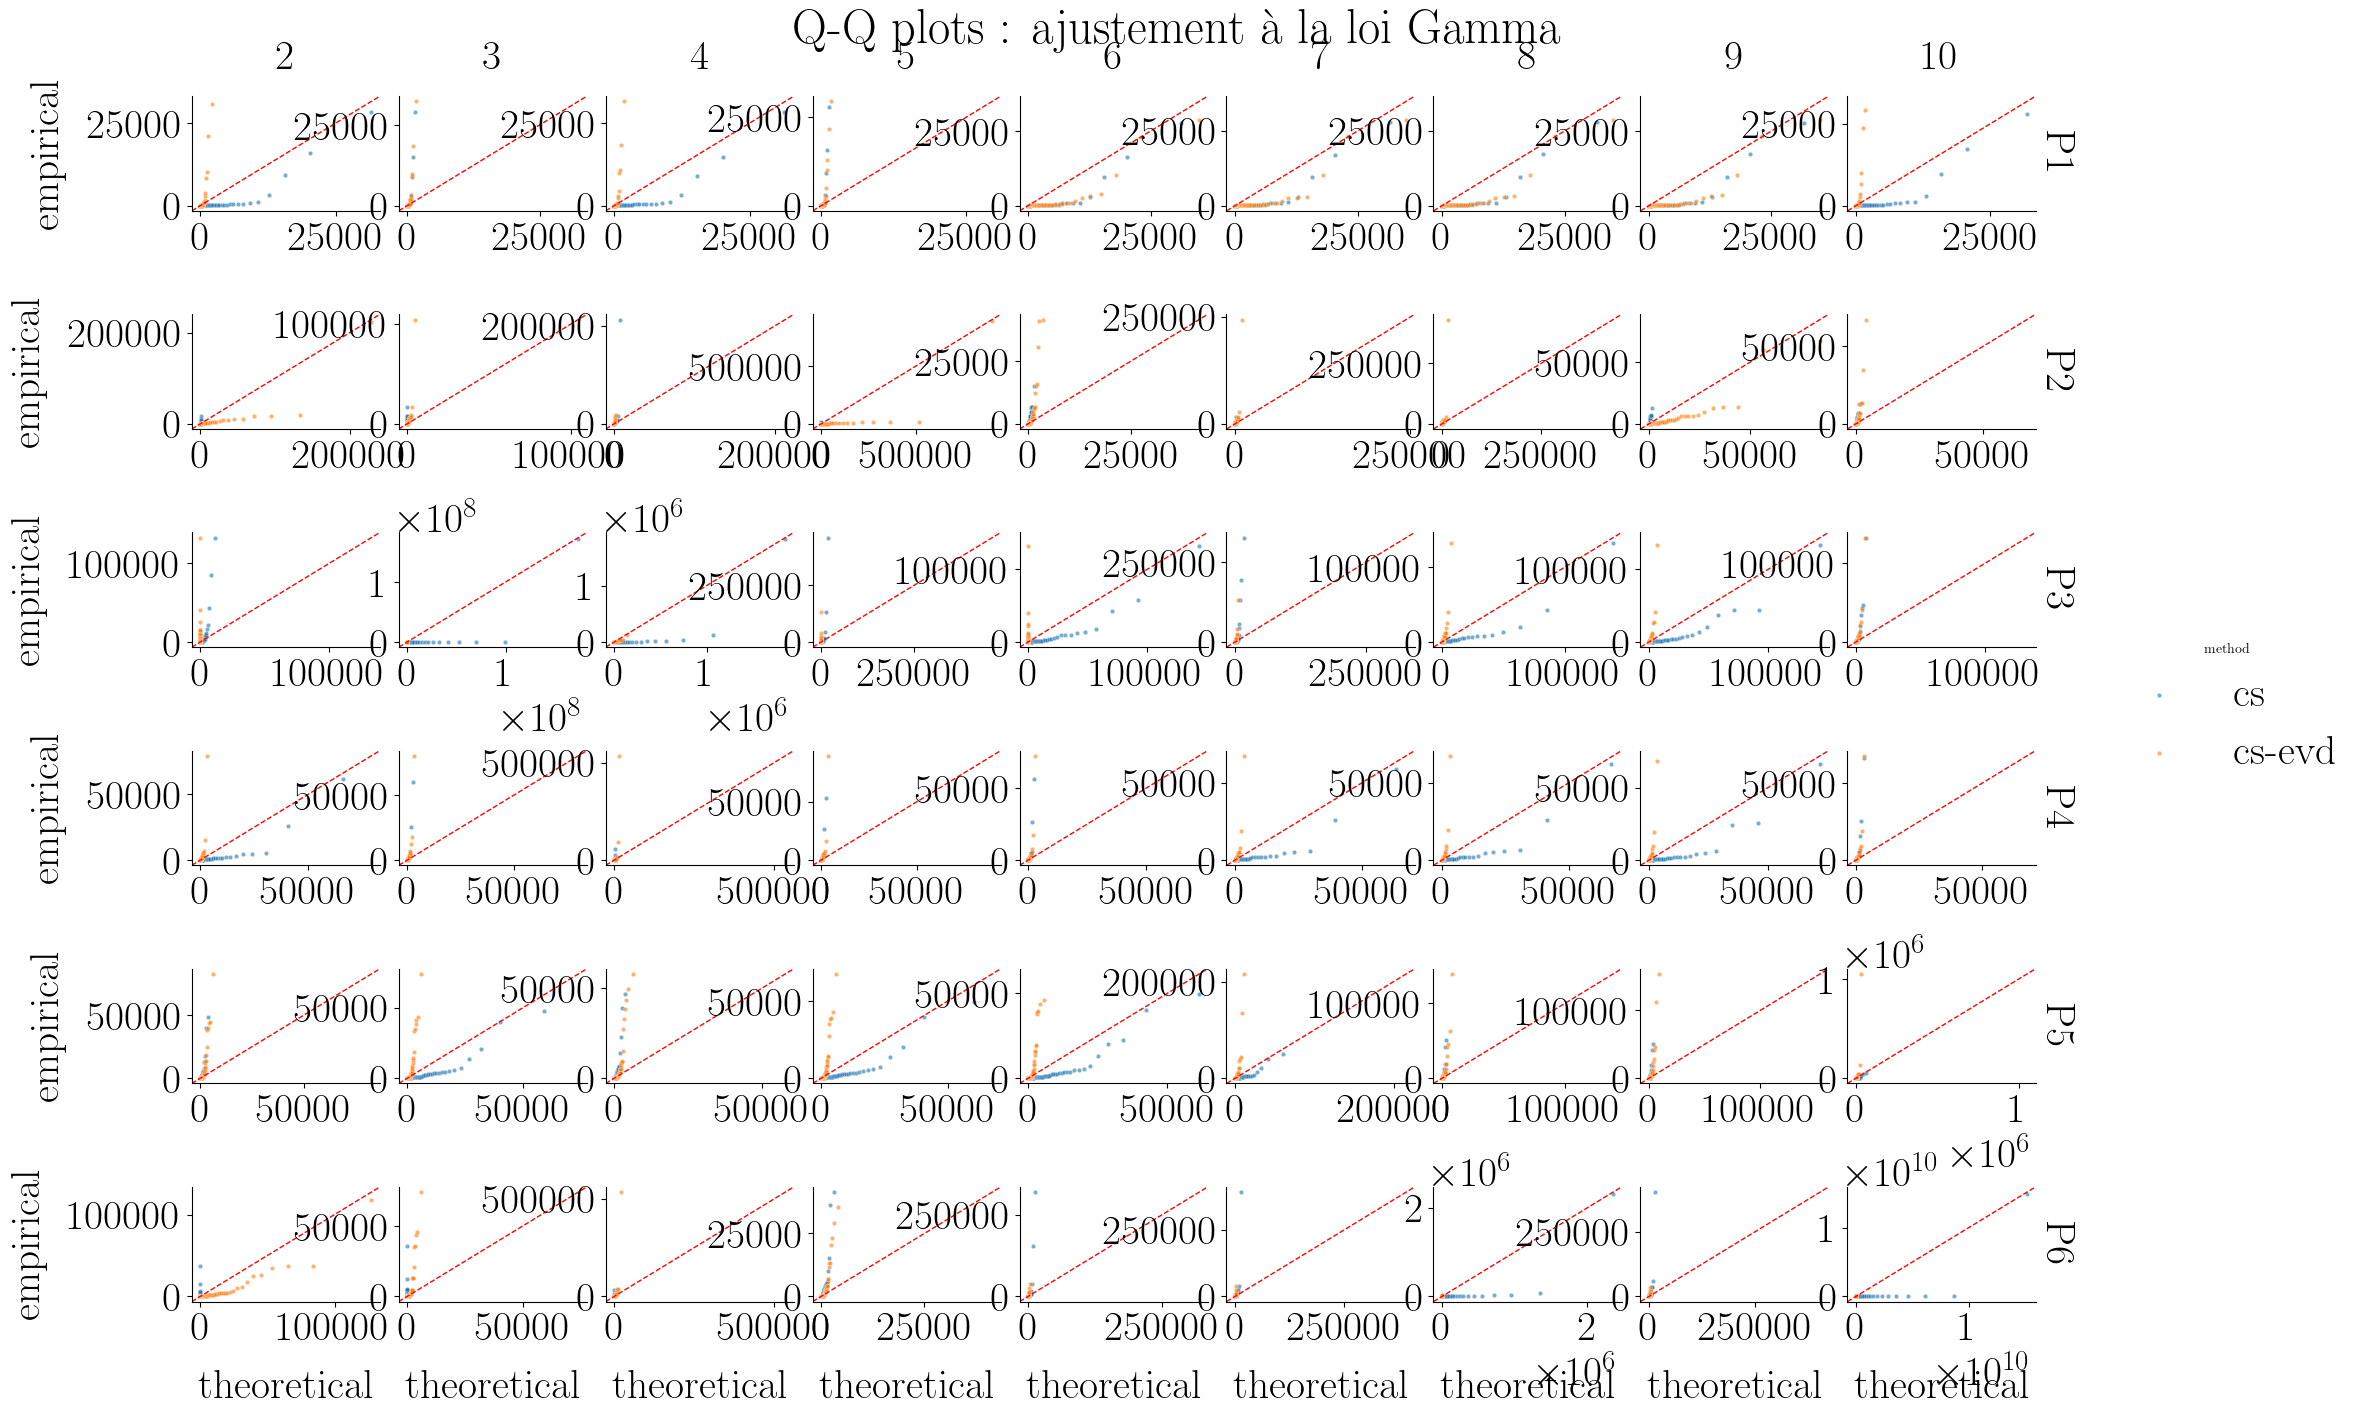

In [45]:
qq_plot(df_frobenius, law="gamma", filter=False)


c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


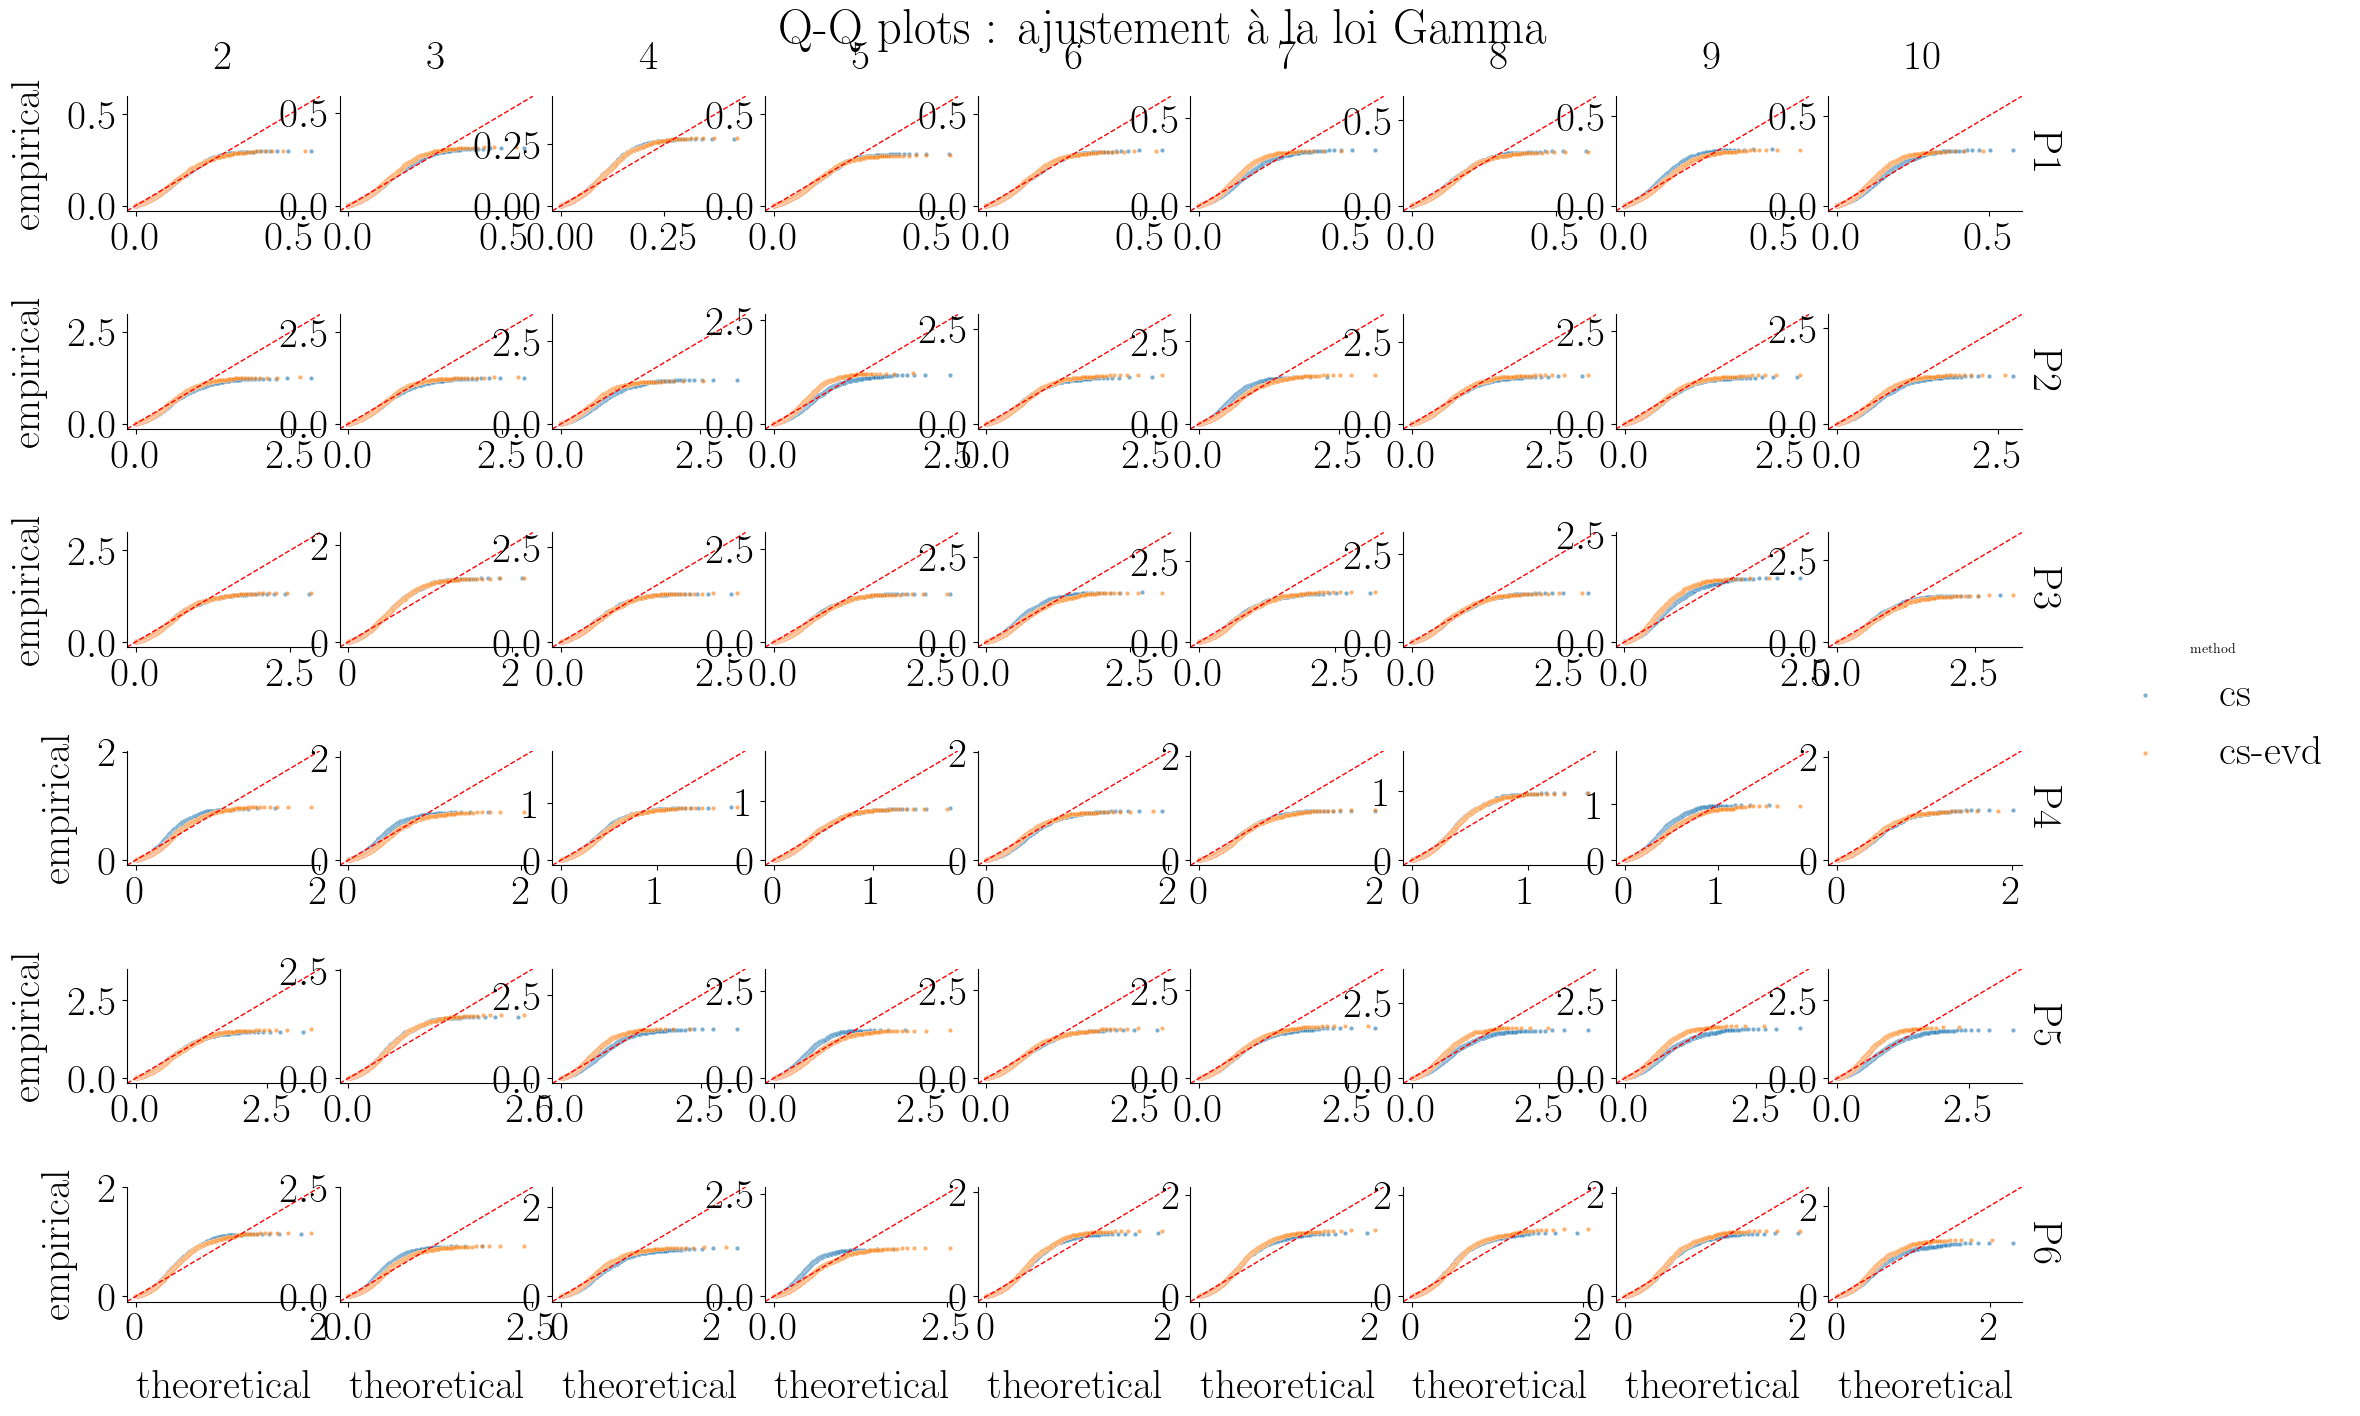

In [46]:
qq_plot(df_frobenius, law="gamma", filter=True)


##### Commentaires 

**Sans filtrage des données** : 
Ajustement toujours aussi naze qu'avec la loi de Rayleigh. 

**Après filtrage IQR**: C'est un peu mieux qu'avec la loi de Rayleigh ? 
 


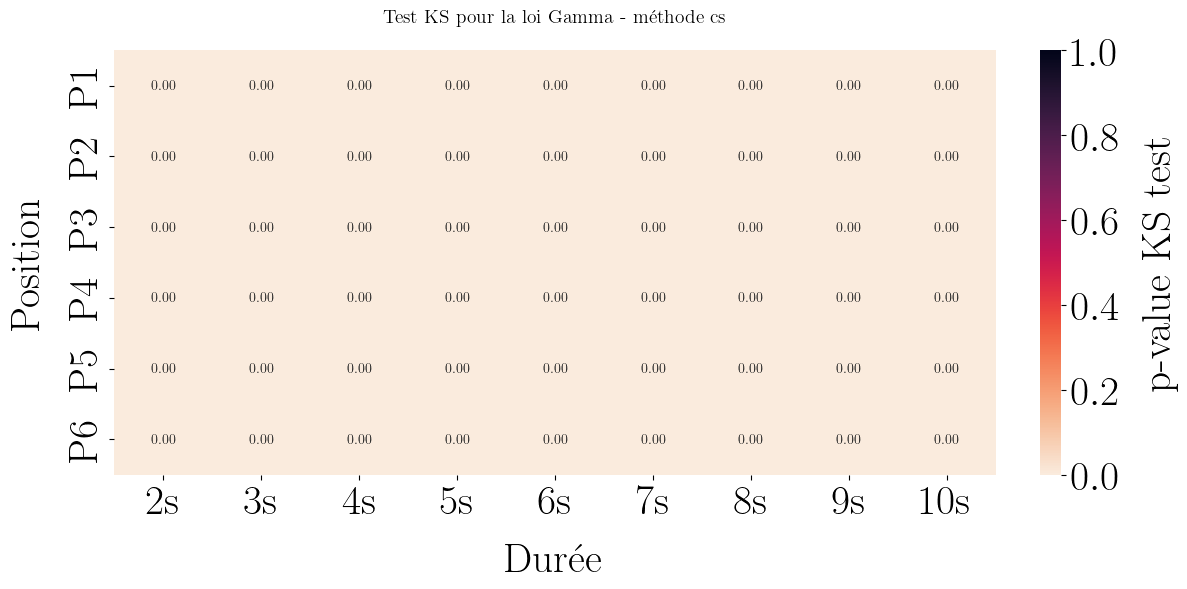

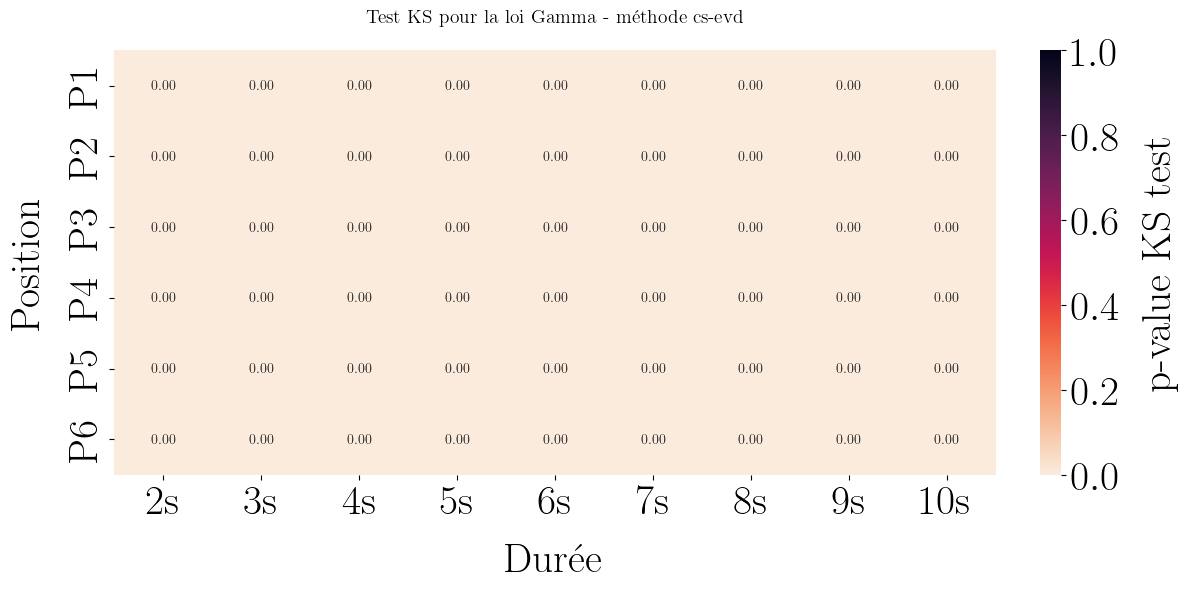

In [47]:
ks_test_heatmap(df_frobenius, law="gamma", filter=True)

##### Commentaires 

Le test KS confirme le mauvais ajustement avec une loi Gamma. 

#### Comparaison d'une distribution Gamma ajustée 

Afin de confirmer le diagnostic posé à partir des Q-Q plots on peut comparer les distributions à une distribution Gamma ajustée aux données 

Filtered data summary:    method position  window_tf  n_before  n_after  n_removed  pct_removed
0  cs-evd       P1         10      5734     5010        724    12.626439
1  cs-evd       P2         10      5734     4990        744    12.975235
2  cs-evd       P3         10      5734     4973        761    13.271713
3  cs-evd       P4         10      5734     4954        780    13.603069
4  cs-evd       P5         10      5734     4964        770    13.428671
5  cs-evd       P6         10      5734     4943        791    13.794908
Fitted params: (0.7031434803892207, 0.1303739710517699, 0.0003659580922118499)


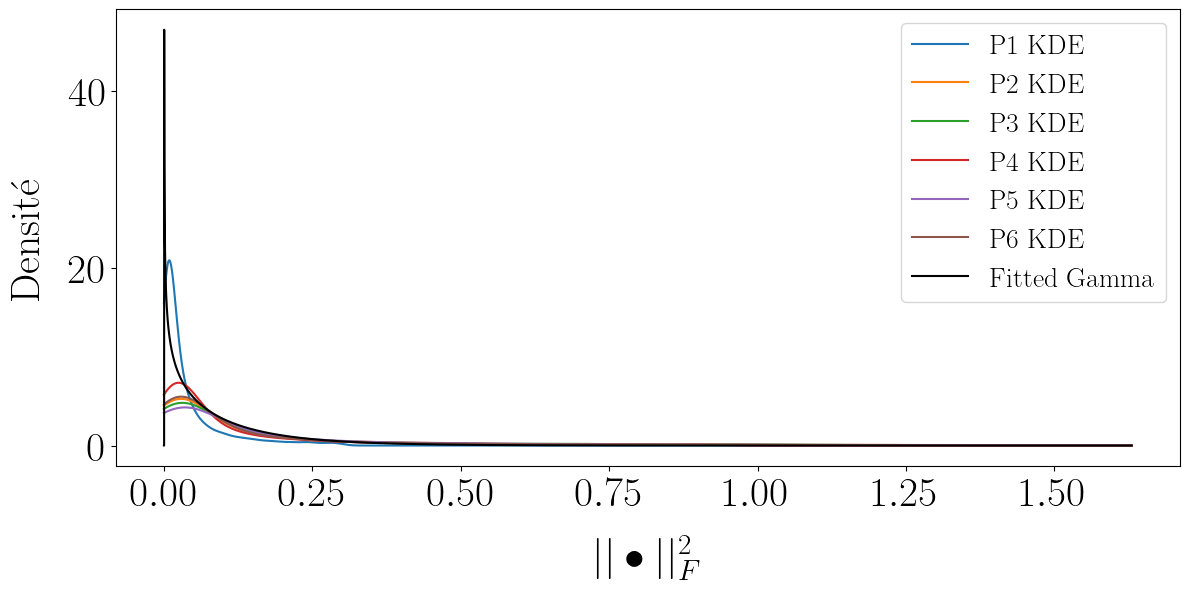

In [48]:
plot_fitted_vs_observed(df_frobenius, law="gamma", filter=True, win=10, method="cs-evd", params_stat="median", value_label=frobenius_norm_label, plot_type="kde")
# plt.xlim(-1, 4)

Filtered data summary:    method position  window_tf  n_before  n_after  n_removed  pct_removed
0  cs-evd       P1         10      5734     5010        724    12.626439
Fitted params: (0.8081798755885268, 0.03369411858579792, 0.00025983677470489995)


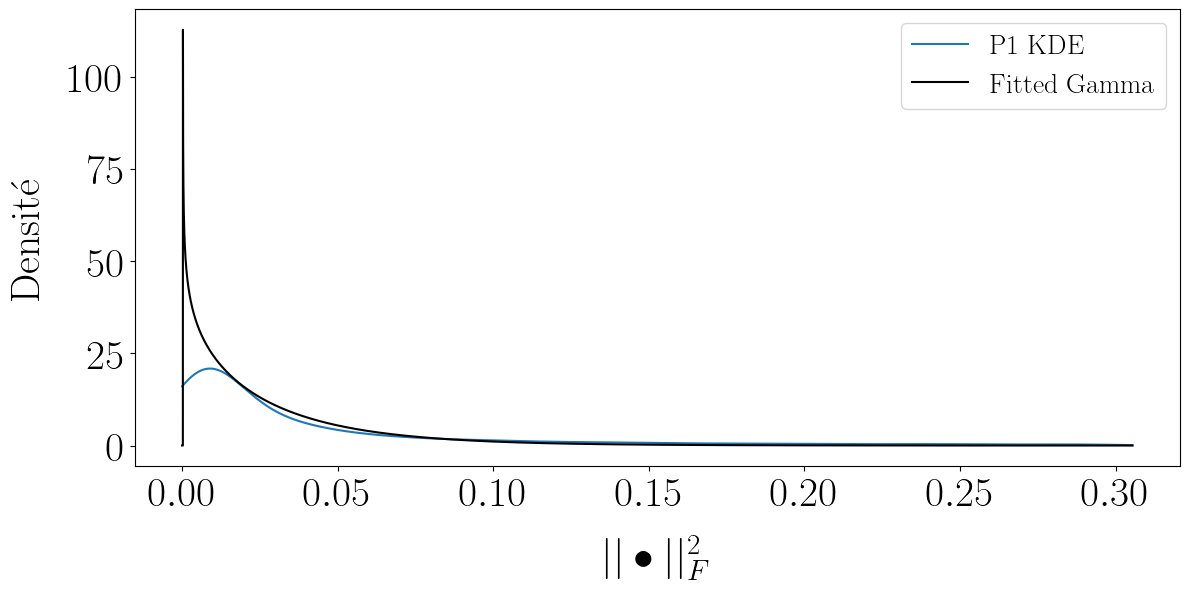

In [49]:
plot_fitted_vs_observed(
    df_frobenius,
    law="gamma",
    filter=True,
    win=10,
    method="cs-evd",
    pos="P1",
    params_stat="first",
    value_label=frobenius_norm_label,
    plot_type="kde",
)

## BILAN pour la distance de frobenius au carré

Le faible ajustement de la loi Gamma pour la distance de Frobenius nous renseigne sur la nature des erreurs d'estimation sur chacune des composantes du vecteur de RTFs. 

(Demonstration à refaire)
En effet, on peut montrer (voir démonstration photo tableau) que si les erreurs d'estimations de la partie réelle et de la partie imaginaire suivent toutes les deux une loi normale d'écart type $\sigma$ alors la distance de Frobenius au carré $ \lVert \delta_{\pi} \rVert_{F}^2$ devrait suivre une loi Gamma $\Gamma(N, 2\sigma^2)$. 

Cela peut par exemple suggérer que l'écart type sur la partie réelle et la partie imaginaire ne sont pas les mêmes ce qui peut facilement se vérifier. 